# GRB and Kilonova Mass-Plane Diagnostics

Gottlieb et al. ([2023](https://arxiv.org/abs/2309.00038), [2024](https://arxiv.org/abs/2411.13657v2)) classification framework applied to COMPAS Model A (Broekgaarden et al. 2021, arXiv:2103.02608) under Planck 2015 ($H_0 = 67.74$ km/s/Mpc, $\Omega_m = 0.3089$) to match COMPAS `FastCosmicIntegration`. Disk-mass GRB rates assume 100 percent jet launching and are upper bounds (Gottlieb 2023).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# grb_*.py modules live in src/; put it on the path for the flat imports below.
sys.path.insert(0, "src")
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm, to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

from grb_physics import (foucart_disk_mass, Q_THRESH_BNS,
                          MDISK_SHORT, MDISK_LONG, M_TOV, M_THRESH,
                          EOS_MODELS, mcrit_to_r14,
                          MISALIGNMENT_SYSTEMATIC_FACTOR,
                          effective_aligned_spin, ns_radius_from_eos,
                          remap_ns_masses_double_gaussian,
                          remap_ns_marginal,
                          NS_REMAP_MU1, NS_REMAP_MU2)
from grb_classify import (classify_bns_2024, classify_bhns,
                           classify_grid, classify_formation_channels,
                           bns_boundary_lines)
from grb_rates import (compute_merger_rate, calibrate_mean_mass_evolved,
                       smooth_rate_curve,
                        formation_efficiency, metallicity_prior_mass_fraction,
                        marginalize_bh_spin,
                        rate_label,
                        beamed_rate, OBSERVED_SGRB_RATES,
                        breakout_fraction_bns_eos, apply_bns_jet_breakout,
                        wanderman_piran_2015_Rz,
                        check_dPdlogZ_normalization, CLASS_THETA_J,
                        apply_bhns_misalignment,
                        LOGZ_MAX_PHYSICAL, kish_effective_sample_size,
                        LVK_GWTC5_LOCAL_RATES,
                        LVK_GWTC5_PER_MODEL_RATES,
                        LVK_GWTC5_NSBH_MIN_BH_MASS)
from grb_io import (load_bns, load_bhns, load_bns_with_channels,
                     load_bhns_with_channels,
                     load_bns_with_kicks, load_bhns_with_kicks,
                     read_expected_local_rate,
                     verify_shared_metallicity_prior,
                     METALLICITY_GRID,
                     OBSERVED_GW_EVENTS,
                     BROEKGAARDEN22_PAPER_II_LETTERS,
                     DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)
from grb_plot_style import weighted_hist_pdf, CHANNEL_PALETTE

# Project palette.
C_SB_BLUE  = '#06B6D4'
C_LB_HMNS  = '#DC2626'
C_LB_DISK  = '#DC2626'
C_FAINT    = '#F59E0B'
C_NO_GRB   = '#334155'
C_FAINT_BH = '#F59E0B'
C_LONG_BH  = '#DC2626'
C_OBS      = '#6B21A8'
C_GUIDE    = '#94A3B8'
C_TEXT     = '#0F172A'
C_BOX_EDGE = '#CBD5E1'

# ApJ rcParams applied globally so every figure inherits the same body
# font, tick style, and serif math.
APJ_RCPARAMS = {
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'savefig.format':      'pdf',
    'font.size':           8,
    'font.family':         'serif',
    'mathtext.fontset':    'cm',
    'axes.linewidth':      0.7,
    'axes.labelsize':      9,
    'axes.titlesize':      9,
    'xtick.labelsize':     7,
    'ytick.labelsize':     7,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'legend.fontsize':     7,
    'legend.frameon':      True,
    'legend.framealpha':   0.92,
    'lines.linewidth':     1.0,
}
plt.rcParams.update(APJ_RCPARAMS)


# Model labels follow the Broekgaarden+ 2022 (paper II) convention used on the
# Zenodo data release; the data layer (filenames, expected_model, the grid
# cache) stays on the paper I letters of Broekgaarden+ 2021.  _p2 maps a
# paper I suffix to its paper II display letter via the canonical map in
# grb_io (A-E coincide; the conventions diverge afterwards).  The full
# crosswalk is printed in Section 11.0.
def _p2(suffix):
    """Paper II (Broekgaarden+ 2022) display letter for a paper I suffix."""
    return BROEKGAARDEN22_PAPER_II_LETTERS.get(suffix, suffix)


A_BH_FID = 0.5
M_HMNS_SPLIT = 1.2 * M_TOV

# COMPAS Model A maximum NS gravitational mass (Broekgaarden+ 2021,
# arXiv:2103.02608; their fiducial M_NS_max = 2.5 Msun, Models J/K = 2.0/3.0).
NS_MAX_BNS = 2.5

# Mass-plane shared plot constants. GRID_COLORS is indexed by classify_grid
# integer labels (0 = unclassified, 1-6 see grb_classify.GRID_CLASS_LABELS).
cmap_hex   = 'Greys'
grid_colors = [C_NO_GRB, C_FAINT, C_LB_HMNS, C_SB_BLUE, C_LB_DISK,
               C_FAINT_BH, C_LONG_BH]
norm_grid  = BoundaryNorm(np.arange(-0.5, 7.5, 1), len(grid_colors))
TINT_ALPHA = 0.22
cmap_grid_tint = ListedColormap(
    [to_rgba(c, 0.0 if c == C_NO_GRB else TINT_ALPHA) for c in grid_colors])

# Load BNS (with channels + kicks for later sections).  Pass
# expected_model / expected_ns_max so the loader validates the embedded
# HDF5 attributes set by tools/embed_model_metadata.py and fails loudly
# if data/COMPASCompactOutput_BNS_A.h5 is silently swapped for a
# different Broekgaarden+ 2021 variation (Models J / K have different
# M_NS_max and would silently mislabel the BNS / BHNS boundary in
# classify_grid, the canonical Section 11 gotcha from CLAUDE.md).
bns_ch = load_bns_with_channels(expected_model='A', expected_ns_max=NS_MAX_BNS)
bns_k  = load_bns_with_kicks(expected_model='A', expected_ns_max=NS_MAX_BNS)

# Apply Alsing, Silva and Berti (2018) double-Gaussian remap globally so every
# downstream BNS figure and rate sees the same masses.
_m1_raw_bns, _m2_raw_bns = bns_ch['m1'].copy(), bns_ch['m2'].copy()
# Retained under stable names for the Section 2b remap-dependence test, which
# re-classifies the same COMPAS sample under the raw masses and a flat-prior
# remap to bound the Alsing-imposed contribution to the class demographics.
m1_bns_raw, m2_bns_raw = _m1_raw_bns, _m2_raw_bns
bns_ch['m1'], bns_ch['m2'] = remap_ns_masses_double_gaussian(
    _m1_raw_bns, _m2_raw_bns,
    weights=bns_ch['weights'], rng=np.random.default_rng(42))
bns_k['m1'],  bns_k['m2']  = bns_ch['m1'], bns_ch['m2']

m1_bns, m2_bns = bns_ch['m1'], bns_ch['m2']
w_bns     = bns_ch['weights']
Z_bns     = bns_ch['metallicity']
delay_bns = bns_ch['delay_time']
n_bns     = bns_ch['n_merging']
M_tot     = m1_bns + m2_bns
q_bns     = m1_bns / m2_bns

# Vectorized remap diagnostics: stack the two component arrays and count
# raw/remapped systems in the [1.65, 1.80] Msun rapid-engine gap.
gap_lo, gap_hi = 1.65, 1.80
_raw   = np.concatenate([_m1_raw_bns, _m2_raw_bns])
_new   = np.concatenate([m1_bns, m2_bns])
_n_gap = ((_raw >= gap_lo) & (_raw <= gap_hi)).sum()
_n_new = ((_new >= gap_lo) & (_new <= gap_hi)).sum()
print(f"BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  "
      f"raw={int(_n_gap):,}  remap={int(_n_new):,}  "
      f"max NS = {_new.max():.3f}  M_TOV = {M_TOV:.2f}")
assert _new.max() <= M_TOV + 1e-6, "remapped NS mass exceeds M_TOV"
assert bool(np.all(m1_bns >= m2_bns)), "m1 >= m2 invariant broken after remap"

# BNS classification.
cls24 = classify_bns_2024(m1_bns, m2_bns)
sbGRB_blue   = cls24['sbGRB + blue KN']
lbGRB_hmns   = cls24['lbGRB + red KN (HMNS)']
lbGRB_disk   = cls24['lbGRB + red KN (disk)']
bns_faint_lb = cls24['Faint lbGRB']

# Load BHNS twice: bhns_ch carries formationChannels columns (Section 7b
# per-channel cosmic integration); bhns_k carries v_sys for the Section 8
# offset analysis.  Both loaders read the same doubleCompactObjects table
# and apply the same mergesInHubbleTimeFlag mask, so per-system ordering is
# identical -- the assert tripwires any future drift between the two loaders.
bhns_ch = load_bhns_with_channels(expected_model='A', expected_ns_max=NS_MAX_BNS)
bhns_k  = load_bhns_with_kicks(expected_model='A', expected_ns_max=NS_MAX_BNS)
assert bhns_ch['weights'].shape == bhns_k['weights'].shape, \
    "bhns_ch and bhns_k disagree on n_merging; mergesInHubbleTimeFlag mask drifted"

# Mirror the BNS remap on the BHNS NS component so the 1.7 Msun Fryer 2012
# Eq. 12-13 deficit (Broekgaarden+ 2021 footnote 3) does not propagate into
# Section 1's BHNS panel, Section 7's spin sweep, or any downstream BHNS rate.
# Separate RNG seed from the BNS call so the two populations get independent
# tie-breaking jitter.
_M_NS_raw_bhns = bhns_ch['M_NS'].copy()
bhns_ch['M_NS'] = remap_ns_marginal(
    bhns_ch['M_NS'], weights=bhns_ch['weights'],
    rng=np.random.default_rng(43))
bhns_k['M_NS']  = bhns_ch['M_NS']

_n_gap_bhns_raw = ((_M_NS_raw_bhns >= 1.65) & (_M_NS_raw_bhns <= 1.80)).sum()
_n_gap_bhns_new = ((bhns_ch['M_NS'] >= 1.65) & (bhns_ch['M_NS'] <= 1.80)).sum()
print(f"BHNS NS-mass remap (Alsing+ 2018): gap [1.65, 1.80] Msun  "
      f"raw={int(_n_gap_bhns_raw):,}  remap={int(_n_gap_bhns_new):,}  "
      f"max NS = {bhns_ch['M_NS'].max():.3f}  M_TOV = {M_TOV:.2f}")
assert bhns_ch['M_NS'].max() <= M_TOV + 1e-6, "remapped BHNS NS mass exceeds M_TOV"

BH, NS_bh  = bhns_ch['M_BH'], bhns_ch['M_NS']
w_bhns     = bhns_ch['weights']
Z_bhns     = bhns_ch['metallicity']
delay_bhns = bhns_ch['delay_time']
n_bhns     = bhns_ch['n_merging']

cbhns = classify_bhns(BH, NS_bh, a_BH=A_BH_FID)
M_disk_bhns   = cbhns['M_disk']
bhns_no_grb   = cbhns['No GRB']
bhns_faint_lb = cbhns['Faint lbGRB (BHNS)']
bhns_long     = cbhns['lbGRB + red KN (BHNS disk)']

# Broekgaarden+ 2021 / 2022 formation channels (I-V) on the merging subset.
# Classified once here so every per-channel split (Sections 3b, 5b, 6b,
# 7b) shares one mask set rather than re-running the event-history
# classifier per section.
channels = classify_formation_channels(
    dblCE=bns_ch['dblCE'], fc_CEE=bns_ch['fc_CEE'],
    fc_mt_p1=bns_ch['fc_mt_p1'], fc_mt_s1=bns_ch['fc_mt_s1'],
    fc_mt_p1_K1=bns_ch['fc_mt_p1_K1'], fc_mt_s1_K2=bns_ch['fc_mt_s1_K2'])
channels_bhns = classify_formation_channels(
    dblCE=bhns_ch['dblCE'], fc_CEE=bhns_ch['fc_CEE'],
    fc_mt_p1=bhns_ch['fc_mt_p1'], fc_mt_s1=bhns_ch['fc_mt_s1'],
    fc_mt_p1_K1=bhns_ch['fc_mt_p1_K1'], fc_mt_s1_K2=bhns_ch['fc_mt_s1_K2'])

# Per-channel palette: one colour means the same Broekgaarden channel in
# every per-channel split across the notebook.  Sourced from the project-wide
# grb_plot_style.CHANNEL_PALETTE (keyed by Roman numeral).
CH_COLORS = {
    k: CHANNEL_PALETTE[k.split()[0]]
    for k in ('I  Stable MT + CE', 'II  Stable MT only', 'III Single-core CE',
              'IV  Double-core CE', 'V   Other')
}

def _pretty_ch(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

v_sys_bns  = bns_k['v_sys']
v_sys_bhns = bhns_k['v_sys']

# Vectorized class summary: mask matrix (n_class, N) -> weighted counts.
def _summary(name, masks_dict, w, n):
    arr = np.stack(list(masks_dict.values()))
    counts = (arr * w).sum(-1) / w.sum() * 100
    raw    = arr.sum(-1)
    print(f"\n{name}: {n:,} merging systems")
    for (lbl, _), pct, n_raw in zip(masks_dict.items(), counts, raw):
        print(f"  {lbl:38s}: {int(n_raw):>7,}  ({pct:.1f}% weighted)")

_summary('BNS', {
    'sbGRB + blue KN (long-lived HMNS)':    sbGRB_blue,
    'lbGRB + red KN  (short-lived HMNS)':   lbGRB_hmns,
    'lbGRB + red KN  (massive disk)':       lbGRB_disk,
    'Faint lbGRB    (small disk / prompt)': bns_faint_lb,
}, w_bns, n_bns)

_summary(f'BHNS (a_BH = {A_BH_FID})', {
    'lbGRB + red KN (massive disk)': bhns_long,
    'Faint lbGRB    (small disk)':   bhns_faint_lb,
    'No GRB / KN    (NS swallowed)': bhns_no_grb,
}, w_bhns, n_bhns)


BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  raw=21,589  remap=36,280  max NS = 2.200  M_TOV = 2.20


BHNS NS-mass remap (Alsing+ 2018): gap [1.65, 1.80] Msun  raw=137,766  remap=155,113  max NS = 2.200  M_TOV = 2.20

BNS: 233,137 merging systems
  sbGRB + blue KN (long-lived HMNS)     :  52,660  (24.0% weighted)
  lbGRB + red KN  (short-lived HMNS)    :  87,852  (26.8% weighted)
  lbGRB + red KN  (massive disk)        :   2,614  (2.2% weighted)
  Faint lbGRB    (small disk / prompt)  :  90,011  (47.0% weighted)

BHNS (a_BH = 0.5): 1,525,553 merging systems
  lbGRB + red KN (massive disk)         :   7,573  (3.8% weighted)
  Faint lbGRB    (small disk)           : 125,479  (20.6% weighted)
  No GRB / KN    (NS swallowed)         : 1,392,501  (75.6% weighted)


/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 959368 systems with Q > 7 (max Q=29.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


## 1. Mass Plane, BNS and BHNS

$M_1$ vs $M_2$ for COMPAS Model A. BHNS uses Foucart, Hinderer and Nissanke (2018, PRD 98, 081501) disk-mass classes at $a_\mathrm{BH} = 0.5$; BNS reproduces and extends Gottlieb et al. (2024, Fig. 3). Filled cividis KDE: STROOPWAFEL-weighted density of the full merging population (no subsampling). Tints: classification regions. Contours: boundaries.

/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 34606 systems with Q > 7 (max Q=20.0); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


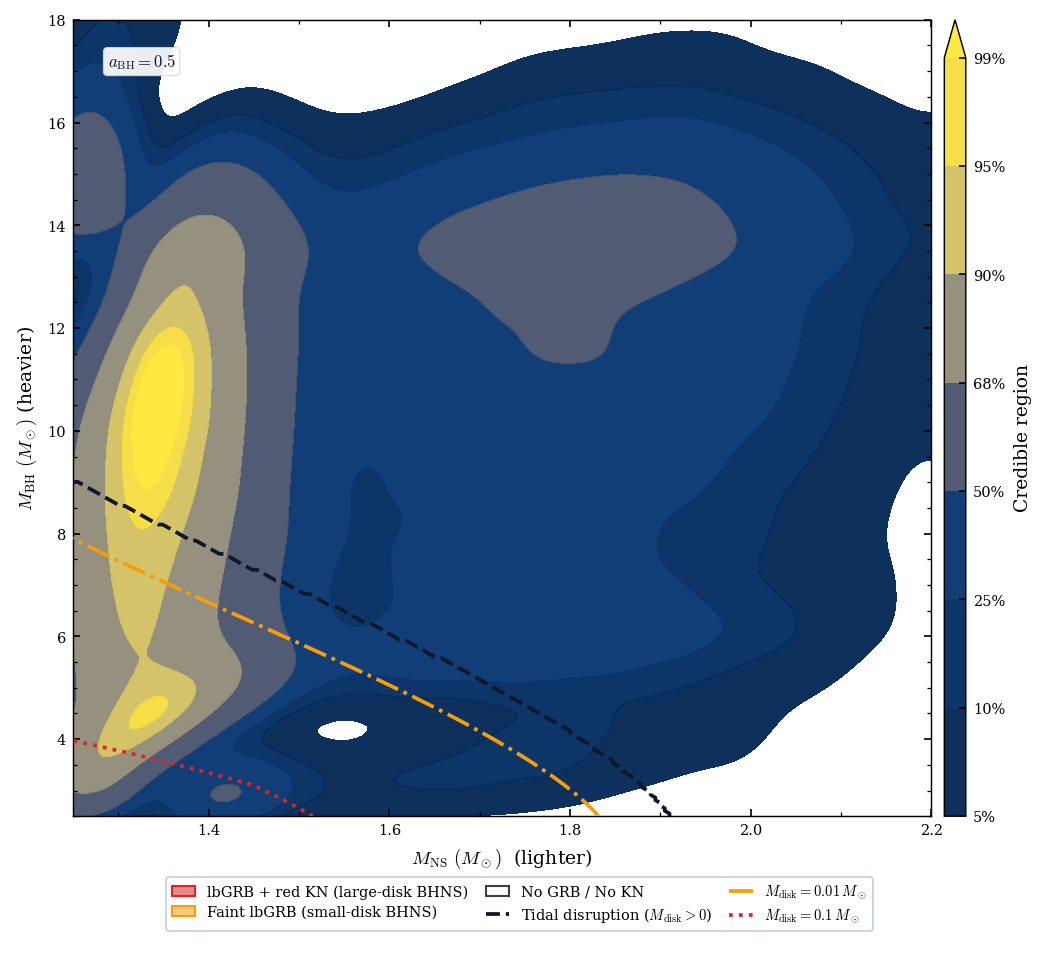

BHNS panel sample: raw N = 1,525,553, Kish N_eff = 292,484


In [2]:
# Panel axis limits.  M2_HI snaps to NS_MAX_BNS so the panel ends where the
# BNS/BHNS boundary actually is (matches the COMPAS Model A M_NS_max = 2.5 Msun
# configuration).  M1_LO at 2.5 Msun shows the lower BH mass gap honestly
# (Bailyn et al. 1998; Farr et al. 2011; reviewed in Abbott+ 2020, GW190814).
# M1_HI snaps just above the outermost 99%-enclosure KDE contour for the
# weighted BHNS population (p99.5 of M_BH in Model A is 20.1 Msun; the contour
# itself tops out near 14 Msun) so the panel focuses on the populated region
# rather than the long high-mass tail.  The figure shows the weighted KDE plus
# the Foucart (2018) disk-mass boundary lines; no classification underlay.
M2_LO_BHNS, M2_HI_BHNS = 1.25, 2.2
M1_LO_BHNS, M1_HI_BHNS = 2.5, 18.0

# Foucart (2018) disk-mass contours for the boundary lines.
_MBH_c = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 300)
_MNS_c = np.linspace(0.9, M2_HI_BHNS, 250)
_MNSg, _MBHg = np.meshgrid(_MNS_c, _MBH_c)
_disk_g = foucart_disk_mass(_MBHg, _MNSg, a_BH=A_BH_FID)
_dg_safe = np.where(_disk_g > 0, _disk_g, np.nan)

fig_bhns = plt.figure(figsize=(7.0, 6.8))
gs = GridSpec(2, 2, height_ratios=[1, 0.11],
              width_ratios=[1, 0.025], hspace=0.10, wspace=0.03,
              figure=fig_bhns,
              left=0.10, right=0.95, top=0.97, bottom=0.06)
ax  = fig_bhns.add_subplot(gs[0, 0])
cax = fig_bhns.add_subplot(gs[0, 1])
lax = fig_bhns.add_subplot(gs[1, :])
lax.axis('off')

# Reflective-boundary KDE at the M_NS = M_TOV hard wall.  The Alsing
# remap caps the BHNS NS distribution at M_TOV exactly (assert above);
# a naive KDE would smear density past 2.2 Msun.  Silverman (1986,
# Sec. 2.10) prescribes mirroring the data across the wall and
# evaluating on the physical side; for a Gaussian (symmetric) kernel
# this is identically equivalent to evaluating the unmirrored KDE at
# both (x, y) and (2*M_TOV - x, y) and summing.  The dual-evaluation
# form keeps the bandwidth tied to the actual population covariance
# (mirroring the data inflates the M_NS variance and would over-
# smooth in that direction).  Same construction used in compact-binary
# population work, e.g. Talbot and Thrane (2018), Mandel, Farr and
# Gair (2019).  Silverman's rule via scipy uses the Kish effective
# sample size N_eff = 1 / sum(w_norm^2) for the bandwidth scaling.
from scipy.stats import gaussian_kde

_kde = gaussian_kde(np.vstack([NS_bh, BH]),
                    weights=w_bhns, bw_method='silverman')

_ns_grid = np.linspace(M2_LO_BHNS, M_TOV, 180)
_bh_grid = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 160)
_NSg, _BHg = np.meshgrid(_ns_grid, _bh_grid)
_pts      = np.vstack([_NSg.ravel(),               _BHg.ravel()])
_pts_refl = np.vstack([2.0 * M_TOV - _NSg.ravel(), _BHg.ravel()])
_Z = (_kde(_pts) + _kde(_pts_refl)).reshape(_NSg.shape)

# Quantile-based contour levels: each band encloses the labelled
# cumulative fraction of the weighted KDE mass.  Standard compact-
# binary mass-plane convention (Talbot and Thrane 2018 Sec. 2.3;
# GWTC-3, Abbott et al. 2023).  Equal-spaced density levels would
# pack all 12 bands into the Alsing peak and leave the rest of the
# panel uninformative.
_quantiles = np.array([0.05, 0.10, 0.25, 0.50, 0.68, 0.90, 0.95, 0.99])

def _quantile_levels(Z, quantiles):
    flat = Z.compressed() if hasattr(Z, 'compressed') else Z.ravel()
    s = np.sort(flat)[::-1]
    c = np.cumsum(s) / s.sum()
    return sorted(s[np.searchsorted(c, q)] for q in quantiles)

_levels = _quantile_levels(_Z, _quantiles)

hb_bh = ax.contourf(_NSg, _BHg, _Z, levels=_levels,
                    cmap='cividis', alpha=0.95, zorder=2,
                    extend='max')

ax.contour(_MNSg, _MBHg, (_disk_g > 0).astype(float), levels=[0.5],
           colors=C_TEXT, linewidths=1.8, linestyles='--', zorder=4)
ax.contour(_MNSg, _MBHg, _dg_safe, levels=[MDISK_SHORT, MDISK_LONG],
           colors=[C_FAINT, C_LB_DISK], linewidths=1.8,
           linestyles=['-.', ':'], zorder=4)

ax.text(0.04, 0.96, rf'$a_{{\mathrm{{BH}}}} = {A_BH_FID}$',
        color=C_TEXT, transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', fc='white',
                  ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_\mathrm{NS}\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_\mathrm{BH}\ (M_\odot)$ (heavier)')
ax.set_xlim(M2_LO_BHNS, M2_HI_BHNS)
ax.set_ylim(M1_LO_BHNS, M1_HI_BHNS)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# Keep ticks and spines above the cividis contour fill; the 5%
# band hugs the bottom-left corner and would otherwise paint over
# the inward-pointing tick marks (xtick.direction='in').
ax.set_axisbelow(False)

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_LONG_BH, _pa), ec=C_LONG_BH, lw=1.0,
          label='lbGRB + red KN (large-disk BHNS)'),
    Patch(fc=to_rgba(C_FAINT_BH, _pa), ec=C_FAINT_BH, lw=1.0,
          label='Faint lbGRB (small-disk BHNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_TEXT, lw=1.8, ls='--',
           label=r'Tidal disruption ($M_\mathrm{disk} > 0$)'),
    Line2D([0], [0], color=C_FAINT, lw=1.8, ls='-.',
           label=r'$M_\mathrm{disk} = 0.01\,M_\odot$'),
    Line2D([0], [0], color=C_LB_DISK, lw=1.8, ls=':',
           label=r'$M_\mathrm{disk} = 0.1\,M_\odot$'),
]
lax.legend(handles=handles, loc='center', ncol=3,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.6, columnspacing=1.2, labelspacing=0.4,
           borderaxespad=0.0)

cb = fig_bhns.colorbar(hb_bh, cax=cax)
cb.set_ticks(_levels)
cb.set_ticklabels([f'{int(q*100)}%' for q in _quantiles])
cb.set_label('Credible region')

fig_bhns.savefig('plots/mass_plane_bhns.png', dpi=300)
fig_bhns.savefig('plots/mass_plane_bhns.pdf')
plt.show()

_n_bhns_raw = int(NS_bh.size)
_n_bhns_eff = (w_bhns.sum() ** 2) / (w_bhns ** 2).sum()
print(f'BHNS panel sample: raw N = {_n_bhns_raw:,}, '
      f'Kish N_eff = {_n_bhns_eff:,.0f}')


**BHNS mass plane (Section 1 supporting panel).** Foucart, Hinderer and Nissanke (2018) disk-mass classes at $a_\mathrm{BH} = 0.5$.

- Sample: raw $N = 1{,}525{,}553$ merging BHNS, Kish $N_\mathrm{eff} = 292{,}484$. Full COMPAS Model A merging population (Broekgaarden et al. 2021, Zenodo 5189849), STROOPWAFEL-weighted, no subsampling. NS masses Alsing-remapped (`remap_ns_marginal`) to close the Fryer (2012) Eq. 12-13 baryonic-to-gravitational artifact (Mandel and Muller 2020).
- Filled KDE: cividis, weighted density at cumulative-fraction levels 5, 10, 25, 50, 68, 90, 95, 99 percent (Talbot and Thrane 2018 Sec. 2.3). Reflective boundary at $M_\mathrm{NS} = M_\mathrm{TOV} = 2.2\,M_\odot$ (Silverman 1986 Sec. 2.10); Silverman bandwidth via `scipy.stats.gaussian_kde`.
- Tints: red lbGRB + red KN ($M_\mathrm{disk} \geq 0.1\,M_\odot$); amber Faint lbGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$); No GRB untinted.
- Boundaries: dashed dark $M_\mathrm{disk} > 0$ (tidal-disruption locus); dash-dot amber $M_\mathrm{disk} = 0.01\,M_\odot$; dotted red $M_\mathrm{disk} = 0.1\,M_\odot$. Contours use $R_{1.4} = 12$ km (Raaijmakers et al. 2021).
- BH mass axis: $[2.5, 18]\,M_\odot$. Model A uses the Fryer (2012) *delayed* engine (Broekgaarden et al. 2021 Table 1), which partially fills the lower mass gap (Bailyn et al. 1998; Farr et al. 2011). The high-mass tail (max $\approx 39\,M_\odot$) lies above the 99 percent contour.
- LVK minimum BH mass: dotted line at $M_\mathrm{BH} = 3.4\,M_\odot$, shaded 90 percent CR $[2.2, 4.4]\,M_\odot$ (unchanged in GWTC-5.0, which adds no new NSBH and inherits the GW230529 value of Abac et al. 2024, arXiv:2404.04248; NSBHPop model of Biscoveanu et al. 2022). Wide CR accommodates the delayed-engine COMPAS distribution.
- Caveats: Foucart (2018) calibrated for $\chi_\mathrm{BH} \in [-0.5, 0.9]$, $Q \in [1, 7]$. Classification regions assume 100 percent jet launching above threshold (Gottlieb 2023 Sec. 2) and are an upper bound. Spin-orbit misalignment $f_\mathrm{misalign} = 0.5$ (Fragos et al. 2010; Kawaguchi et al. 2015) is applied at the rate stage (`apply_bhns_misalignment`), not in the KDE.

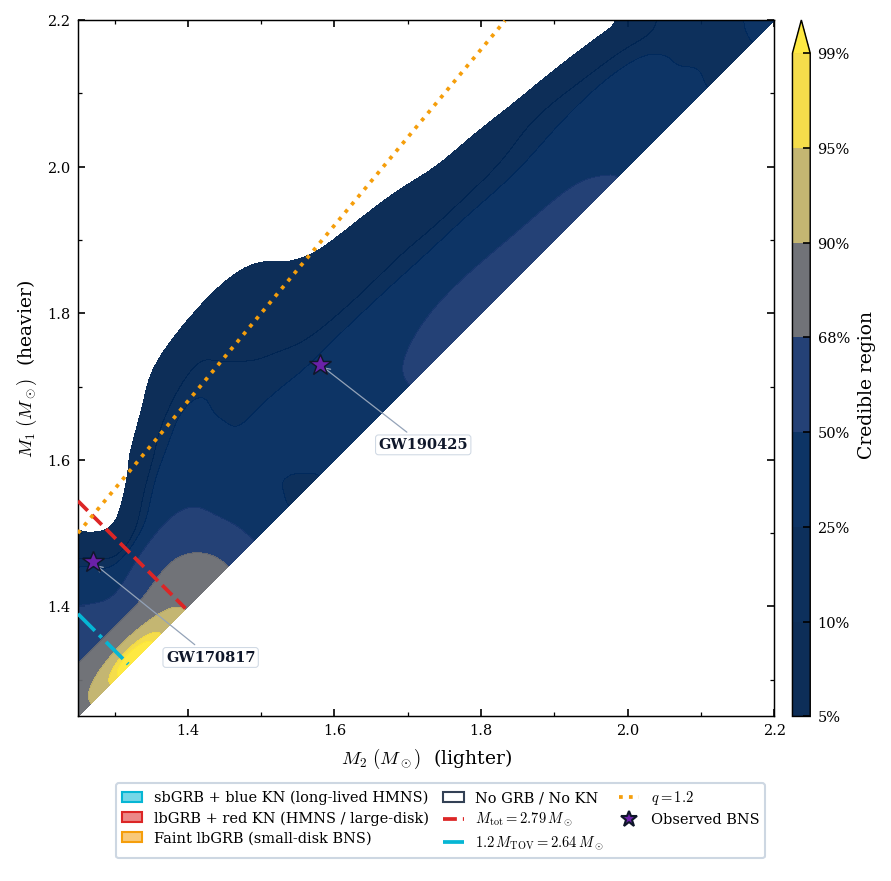

BNS panel sample: raw N = 233,137, Kish N_eff = 65,134


In [3]:
# BNS mass plane axis limits.  Axes cropped to [1.25, 2.2] Msun: COMPAS
# Model A's Alsing-remapped BNS population is heavily peaked near (1.35, 1.35)
# and the data does not extend past M_TOV = 2.2 Msun.  The figure shows the
# weighted reflective KDE plus the Gottlieb (2024) boundary lines (computed
# below via bns_boundary_lines); no classification underlay.
M2_LO_BNS, M2_HI_BNS = 1.25, 2.2
M1_LO_BNS, M1_HI_BNS = 1.25, 2.2

fig_bns = plt.figure(figsize=(5.8, 6.0))
gs = GridSpec(2, 2, height_ratios=[1, 0.13],
              width_ratios=[1, 0.025], hspace=0.15, wspace=0.03,
              figure=fig_bns,
              left=0.10, right=0.95, top=0.97, bottom=0.03)
ax  = fig_bns.add_subplot(gs[0, 0])
cax = fig_bns.add_subplot(gs[0, 1])
lax = fig_bns.add_subplot(gs[1, :])
lax.axis('off')

# Reflective-boundary KDE on the BNS mass plane.  Two construction
# steps:
#   (i) m1 <-> m2 symmetrisation.  The convention m1 >= m2 is a label
#       choice; the underlying density f(m1, m2) is physically
#       symmetric under swap (the two NSs are interchangeable).  Feed
#       the KDE with both (m2, m1) and the swapped (m1, m2), weights
#       duplicated.  This makes the bandwidth tensor symmetric in
#       (m1, m2), removes the diagonal as a special boundary, and is
#       the standard treatment of indistinguishable-pair populations.
#  (ii) Reflective boundary at the two M_TOV walls (m1 = M_TOV,
#       m2 = M_TOV).  Both NS-mass arrays are Alsing-capped at M_TOV
#       (assert in the data-prep cell), so a naive KDE would smear
#       past 2.2 Msun on both axes.  For a Gaussian (symmetric) kernel
#       the data-mirror trick is equivalent to the four-point dual
#       evaluation f(x, y) + f(2M - x, y) + f(x, 2M - y) +
#       f(2M - x, 2M - y) (Silverman 1986 Sec. 2.10; applied to
#       compact-binary populations in Talbot and Thrane 2018; Mandel,
#       Farr and Gair 2019).  The trailing factor of 2 renormalises
#       to the m1 >= m2 half: the symmetric + reflective density
#       integrates to 1 over the full [a, M_TOV]^2 square, with half
#       the mass on each side of the diagonal.
from scipy.stats import gaussian_kde

_m2_sym = np.concatenate([m2_bns, m1_bns])
_m1_sym = np.concatenate([m1_bns, m2_bns])
_w_sym  = np.concatenate([w_bns,  w_bns])

_kde = gaussian_kde(np.vstack([_m2_sym, _m1_sym]),
                    weights=_w_sym, bw_method='silverman')

_m2_grid = np.linspace(M2_LO_BNS, min(M_TOV, M2_HI_BNS), 180)
_m1_grid = np.linspace(M1_LO_BNS, min(M_TOV, M1_HI_BNS), 180)
_M2g, _M1g = np.meshgrid(_m2_grid, _m1_grid)
_x = _M2g.ravel()
_y = _M1g.ravel()
_two_M = 2.0 * M_TOV
_Z = (_kde(np.vstack([_x,           _y          ]))
    + _kde(np.vstack([_two_M - _x,  _y          ]))
    + _kde(np.vstack([_x,           _two_M - _y ]))
    + _kde(np.vstack([_two_M - _x,  _two_M - _y ]))).reshape(_M2g.shape) * 2.0
_Z = np.ma.array(_Z, mask=(_M1g < _M2g))

# Quantile-based contour levels: each band encloses the labelled
# cumulative fraction of the weighted KDE mass.  Standard compact-
# binary mass-plane convention (Talbot and Thrane 2018 Sec. 2.3;
# GWTC-3, Abbott et al. 2023).  Equal-spaced density levels would
# pack all bands into the Alsing peak near (1.35, 1.35) and leave
# the rest of the panel uninformative.
_quantiles = np.array([0.05, 0.10, 0.25, 0.50, 0.68, 0.90, 0.95, 0.99])

def _quantile_levels(Z, quantiles):
    flat = Z.compressed() if hasattr(Z, 'compressed') else Z.ravel()
    s = np.sort(flat)[::-1]
    c = np.cumsum(s) / s.sum()
    return sorted(s[np.searchsorted(c, q)] for q in quantiles)

_levels = _quantile_levels(_Z, _quantiles)

hb_ns = ax.contourf(_M2g, _M1g, _Z, levels=_levels,
                    cmap='cividis', alpha=0.95, zorder=2,
                    extend='max')

_m2 = np.linspace(M2_LO_BNS, M2_HI_BNS, 500)
_bdy = bns_boundary_lines(_m2, m1_lim=(M1_LO_BNS, M1_HI_BNS))
ax.plot(*_bdy['M_tot'], color=C_LB_HMNS, lw=1.8, ls='--', zorder=4)
ax.plot(*_bdy['HMNS'],  color=C_SB_BLUE, lw=1.8, ls='-.', zorder=4)
ax.plot(*_bdy['q'],     color=C_FAINT,   lw=1.8, ls=':',  zorder=4)

# Observed BNS GW events (Abbott+ 2019 PRX 9, 011001 low-spin medians;
# Abbott+ 2020 ApJL 892, L3 low-spin medians).
for name, ev in OBSERVED_GW_EVENTS.items():
    m2v, m1v = ev['M2'], ev['M1']
    ax.plot(m2v, m1v, marker='*', ms=11, mec=C_TEXT, mfc=C_OBS,
            mew=0.7, zorder=12)
    dx, dy = (0.10, -0.12) if name == 'GW170817' else (0.08, -0.10)
    ax.annotate(name, xy=(m2v, m1v), xytext=(m2v + dx, m1v + dy),
                fontsize=7, color=C_TEXT, fontweight='bold',
                ha='left', va='top',
                arrowprops=dict(arrowstyle='->', color=C_GUIDE, lw=0.6),
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_2\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_1\ (M_\odot)$  (heavier)')
ax.set_xlim(M2_LO_BNS, M2_HI_BNS)
ax.set_ylim(M1_LO_BNS, M1_HI_BNS)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_aspect('equal', adjustable='box')
ax.set_axisbelow('line')

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_SB_BLUE, _pa), ec=C_SB_BLUE, lw=1.0,
          label='sbGRB + blue KN (long-lived HMNS)'),
    Patch(fc=to_rgba(C_LB_HMNS, _pa), ec=C_LB_HMNS, lw=1.0,
          label='lbGRB + red KN (HMNS / large-disk)'),
    Patch(fc=to_rgba(C_FAINT, _pa), ec=C_FAINT, lw=1.0,
          label='Faint lbGRB (small-disk BNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_LB_HMNS, lw=1.8, ls='--',
           label=rf'$M_{{\mathrm{{tot}}}} = {M_THRESH:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_SB_BLUE, lw=1.8, ls='-.',
           label=rf'$1.2\,M_{{\mathrm{{TOV}}}} = {M_HMNS_SPLIT:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_FAINT, lw=1.8, ls=':', label=r'$q = 1.2$'),
    Line2D([0], [0], marker='*', color='w', mfc=C_OBS, mec=C_TEXT,
           ms=8, lw=0, label='Observed BNS'),
]
lax.legend(handles=handles, loc='center', ncol=3,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.4, columnspacing=1.0, labelspacing=0.4,
           borderaxespad=0.0)

cb = fig_bns.colorbar(hb_ns, cax=cax)
cb.set_ticks(_levels)
cb.set_ticklabels([f'{int(q*100)}%' for q in _quantiles])
cb.set_label('Credible region')

fig_bns.savefig('plots/mass_plane_bns.png', dpi=300)
fig_bns.savefig('plots/mass_plane_bns.pdf')
plt.show()

_n_bns_raw = int(m1_bns.size)
_n_bns_eff = (w_bns.sum() ** 2) / (w_bns ** 2).sum()
print(f'BNS panel sample: raw N = {_n_bns_raw:,}, '
      f'Kish N_eff = {_n_bns_eff:,.0f}')


**Figure 1. BNS mass plane, COMPAS Model A.** Gottlieb et al. (2024) classes.

- Sample: raw $N = 233{,}137$ merging BNS, Kish $N_\mathrm{eff} = 65{,}134$. Full COMPAS Model A merging population (Broekgaarden et al. 2021, Zenodo 5189849), STROOPWAFEL-weighted, no subsampling. Masses Alsing-remapped (`remap_ns_masses_double_gaussian`; Mandel and Muller 2020). Axes cropped to $[1.25, 1.9]\,M_\odot$; the classifier still uses $M_\mathrm{NS,max} = 2.5\,M_\odot$.
- Filled KDE: cividis, weighted density at cumulative-fraction levels 5, 10, 25, 50, 68, 90, 95, 99 percent (Talbot and Thrane 2018 Sec. 2.3). Reflective boundary at $m_1, m_2 = M_\mathrm{TOV} = 2.2\,M_\odot$ (Silverman 1986 Sec. 2.10); sample symmetrised under $m_1 \leftrightarrow m_2$ before fitting and density renormalised to the visible $m_1 \geq m_2$ half. Silverman bandwidth via `scipy.stats.gaussian_kde`.
- Tints: cyan sbGRB + blue KN ($M_\mathrm{tot} < 1.2\,M_\mathrm{TOV}$); red lbGRB + red KN (short-lived HMNS or large-disk prompt collapse); amber Faint lbGRB ($q < 1.2$ above $M_\mathrm{thresh}$).
- Boundaries: dashed red $M_\mathrm{tot} = M_\mathrm{thresh} = 2.79\,M_\odot$; dash-dot cyan $1.2\,M_\mathrm{TOV} = 2.64\,M_\odot$; dotted amber $q = 1.2$. All three scale with $M_\mathrm{TOV} = 2.2\,M_\odot$ (Raaijmakers et al. 2021). $M_\mathrm{thresh} = 1.27\,M_\mathrm{TOV}$ is a Gottlieb (2023) fiducial; the $1.2\,M_\mathrm{TOV}$ HMNS split is a code heuristic (Margalit and Metzger 2017).
- Purple stars: GW170817, GW190425 (low-spin medians).
- Caveat: classification regions assume 100 percent jet launching above $M_\mathrm{thresh}$ (Gottlieb 2023 Sec. 2) and are an upper bound.

## 2. Component Mass Distributions by GRB Class

Weighted histograms of $M_1$, $M_2$, $M_\mathrm{tot}$, $q$ per Gottlieb (2024) class. Each curve is STROOPWAFEL-weighted and abundance-normalized so its area equals that class's population fraction (asserted in-cell); the $y$-axis is the partial density $dP/dx$ ($M_\odot^{-1}$ for masses, dimensionless for $q$). The two lbGRB + red KN classes share project red `#DC2626`, separated by linestyle (HMNS solid, disk dashed); same convention in Sections 3, 5, 6, 8.

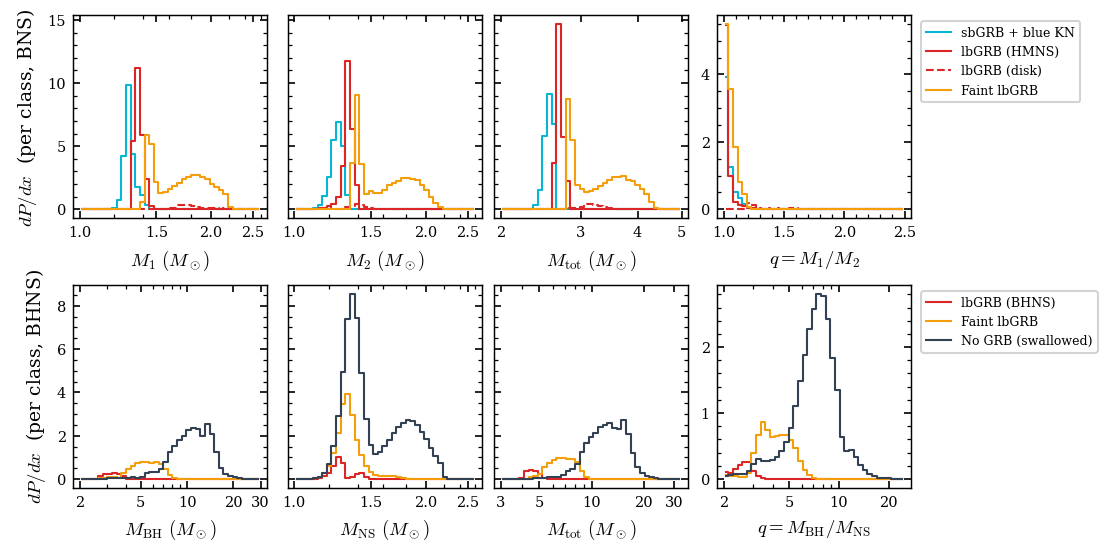


BNS class fractions (weighted):
  sbGRB + blue KN      24.0%
  lbGRB (HMNS)         26.8%
  lbGRB (disk)          2.2%
  Faint lbGRB          47.0%
BHNS class fractions (weighted):
  lbGRB (BHNS)          3.8%
  Faint lbGRB          20.6%
  No GRB (swallowed)   75.6%
Out-of-range weight per panel (visual truncation):
  BNS  $M_1\ (M_\odot)$                     0.00%
  BNS  $M_2\ (M_\odot)$                     0.00%
  BNS  $M_\mathrm{tot}\ (M_\odot)$          0.00%
  BNS  $q = M_1/M_2$                        0.00%
  BHNS $M_\mathrm{BH}\ (M_\odot)$           0.05%
  BHNS $M_\mathrm{NS}\ (M_\odot)$           0.00%
  BHNS $M_\mathrm{tot}\ (M_\odot)$          0.04%
  BHNS $q = M_\mathrm{BH}/M_\mathrm{NS}$    1.19%


In [4]:
# lbGRB (HMNS) and lbGRB (disk) share C_LB_DISK == C_LB_HMNS == '#DC2626'
# in the project palette ("+red KN" family), so they are distinguished by
# linestyle within the panel: HMNS solid, disk dashed.  Same convention as
# Sections 3, 5, 7, 9 already use elsewhere in this notebook.
bns_classes = [
    ('sbGRB + blue KN', sbGRB_blue,    C_SB_BLUE, '-'),
    ('lbGRB (HMNS)',    lbGRB_hmns,    C_LB_HMNS, '-'),
    ('lbGRB (disk)',    lbGRB_disk,    C_LB_DISK, '--'),
    ('Faint lbGRB',     bns_faint_lb,  C_FAINT,   '-'),
]
bhns_classes = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH,  '-'),
    ('Faint lbGRB',        bhns_faint_lb, C_FAINT_BH, '-'),
    ('No GRB (swallowed)', bhns_no_grb,   C_NO_GRB,   '-'),
]

# Abundance normalization: each curve is sum(w_in_bin) / (W_total * binw),
# so the four BNS (three BHNS) class curves jointly integrate to 1 across
# the merging population and each curve's area equals that class's
# population fraction.  Population totals are taken over the union of class
# masks to defend against any unclassified row.
_bns_partition  = sbGRB_blue | lbGRB_hmns | lbGRB_disk | bns_faint_lb
_bhns_partition = bhns_long | bhns_faint_lb | bhns_no_grb
w_total_bns  = w_bns[_bns_partition].sum()
w_total_bhns = w_bhns[_bhns_partition].sum()

# Bin ranges chosen to cover the full support of every class on the same axis,
# so the abundance-weighted curves do not silently drop area outside the
# range.  In particular: BNS q extended to 2.5 (NS_MAX_BNS / NS_REMAP_M_MIN
# upper bound for the Alsing+ 2018 remap); BHNS axes truncated to the
# populated mass / mass-ratio window (M_BH > 25 Msun, q > 25 hold negligible
# weight in Model A, see weighted-fraction print below).  Mass panels use
# log10-uniform edges so dynamic range across BNS (~0.4 dex) and BHNS M_BH
# (~1.2 dex) is comparable; BHNS q (~1 dex span, peak near q=5) goes log
# too; BNS q stays linear because its support is too narrow (~0.4 dex) to
# benefit from log binning.
bins_m_log       = np.logspace(np.log10(1.0), np.log10(2.6), 40)
bins_mt_log      = np.logspace(np.log10(2.0), np.log10(5.0), 40)
bins_bh_log      = np.logspace(np.log10(2.0), np.log10(30.0), 40)
bins_mt_bhns_log = np.logspace(np.log10(3.0), np.log10(33.0), 40)
bins_q_bns       = np.linspace(1.0, 2.5, 40)
bins_q_bhns_log  = np.logspace(np.log10(2.0), np.log10(25.0), 40)

# Figure width bumped to 7.3 in (ApJ page-width cap, see CLAUDE.md plotting
# standards) so the external legend boxes do not force constrained_layout
# to shrink the eight panels.  y-axis sharing is set up by hand below:
# the three mass panels per row share y (dP/dlogM on a single scale), and
# each q panel gets its own y-axis because dP/dq peaks at ~5 (BNS) and
# ~0.2 (BHNS) - very different scales from the dP/dlogM mass panels.
fig, axes = plt.subplots(2, 4, figsize=(7.3, 3.6), constrained_layout=True)
for row in (0, 1):
    axes[row, 1].sharey(axes[row, 0])
    axes[row, 2].sharey(axes[row, 0])
    axes[row, 1].tick_params(labelleft=False)
    axes[row, 2].tick_params(labelleft=False)

# Per-panel xscale + explicit major ticks.  'log' panels histogram in
# log10(M) (so the y-axis becomes dP/dlog10(M) and the per-curve area is
# still the class fraction).  Sub-decade log axes get an explicit tick
# list because matplotlib's default LogLocator labels every minor tick
# when the range is < 1 dex, which collides and reads as garble.
from matplotlib.ticker import ScalarFormatter, NullFormatter
bns_panels = [
    (m1_bns, bins_m_log,  r'$M_1\ (M_\odot)$',            'log',    [1.0, 1.5, 2.0, 2.5]),
    (m2_bns, bins_m_log,  r'$M_2\ (M_\odot)$',            'log',    [1.0, 1.5, 2.0, 2.5]),
    (M_tot,  bins_mt_log, r'$M_\mathrm{tot}\ (M_\odot)$', 'log',    [2.0, 3.0, 4.0, 5.0]),
    (q_bns,  bins_q_bns,  r'$q = M_1/M_2$',               'linear', None),
]
for ax, (data, bins, xlabel, xscale, xticks) in zip(axes[0], bns_panels):
    if xscale == 'log':
        data_h = np.log10(data)
        bins_h = np.log10(bins)
    else:
        data_h, bins_h = data, bins
    binw_panel = np.diff(bins_h)
    area_sum = 0.0
    for lbl, mask, c, ls in bns_classes:
        h = weighted_hist_pdf(data_h, mask, w_bns, bins_h, w_total_bns)
        if h is None:
            continue
        x, mu = h
        area_sum += (mu * binw_panel).sum()
        x_plot = 10**x if xscale == 'log' else x
        ax.step(x_plot, mu, where='mid', color=c, ls=ls, lw=1.0, label=lbl)
    if xscale == 'log':
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter())
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.set_xlabel(xlabel)
    # Compare area_sum to the *in-range* fraction of the union mask, not
    # to 1, so the assertion stays at machine precision even when bins
    # deliberately truncate a sparse tail (e.g. BHNS M_BH > 30 Msun).
    # A partition bug (mask non-exhaustive, normalization wrong) still
    # blows up; only intentional visual truncation is tolerated.  Range
    # check stays in linear data space; equivalent for positive masses.
    _in_range = (data >= bins[0]) & (data <= bins[-1])
    _expected = w_bns[_bns_partition & _in_range].sum() / w_total_bns
    assert abs(area_sum - _expected) < 1e-9, (
        f"BNS panel '{xlabel}' area_sum={area_sum:.9f} != in-range "
        f"fraction {_expected:.9f}; partition broken (non-exhaustive mask "
        f"or normalization error)"
    )
axes[0, 0].set_ylabel(r'$dP/dx$  (per class, BNS)')
axes[0, 3].legend(fontsize=6, loc='upper left',
                  bbox_to_anchor=(1.02, 1.0), framealpha=0.85)

bhns_panels = [
    (BH,         bins_bh_log,      r'$M_\mathrm{BH}\ (M_\odot)$',        'log', [2.0, 5.0, 10.0, 20.0, 30.0]),
    (NS_bh,      bins_m_log,       r'$M_\mathrm{NS}\ (M_\odot)$',        'log', [1.0, 1.5, 2.0, 2.5]),
    (BH + NS_bh, bins_mt_bhns_log, r'$M_\mathrm{tot}\ (M_\odot)$',       'log', [3.0, 5.0, 10.0, 20.0, 30.0]),
    (BH / NS_bh, bins_q_bhns_log,  r'$q = M_\mathrm{BH}/M_\mathrm{NS}$', 'log', [2.0, 5.0, 10.0, 20.0]),
]
for ax, (data, bins, xlabel, xscale, xticks) in zip(axes[1], bhns_panels):
    if xscale == 'log':
        data_h = np.log10(data)
        bins_h = np.log10(bins)
    else:
        data_h, bins_h = data, bins
    binw_panel = np.diff(bins_h)
    area_sum = 0.0
    for lbl, mask, c, ls in bhns_classes:
        h = weighted_hist_pdf(data_h, mask, w_bhns, bins_h, w_total_bhns)
        if h is None:
            continue
        x, mu = h
        area_sum += (mu * binw_panel).sum()
        x_plot = 10**x if xscale == 'log' else x
        ax.step(x_plot, mu, where='mid', color=c, ls=ls, lw=1.0, label=lbl)
    if xscale == 'log':
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter())
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.set_xlabel(xlabel)
    _in_range = (data >= bins[0]) & (data <= bins[-1])
    _expected = w_bhns[_bhns_partition & _in_range].sum() / w_total_bhns
    assert abs(area_sum - _expected) < 1e-9, (
        f"BHNS panel '{xlabel}' area_sum={area_sum:.9f} != in-range "
        f"fraction {_expected:.9f}; partition broken (non-exhaustive mask "
        f"or normalization error)"
    )
axes[1, 0].set_ylabel(r'$dP/dx$  (per class, BHNS)')
axes[1, 3].legend(fontsize=6, loc='upper left',
                  bbox_to_anchor=(1.02, 1.0), framealpha=0.85)

fig.savefig('plots/mass_distributions_by_class.png', dpi=300)
fig.savefig('plots/mass_distributions_by_class.pdf')
plt.show()

# Class fractions: with abundance normalization these equal the area under
# each curve (modulo any out-of-range tail).  Printed so a reader of the
# notebook can compare the relative class abundances against the per-curve
# shapes in the figure.
print('\nBNS class fractions (weighted):')
for lbl, mask, _, _ in bns_classes:
    frac = w_bns[mask].sum() / w_total_bns
    print(f'  {lbl:18s}  {frac*100:5.1f}%')
print('BHNS class fractions (weighted):')
for lbl, mask, _, _ in bhns_classes:
    frac = w_bhns[mask].sum() / w_total_bhns
    print(f'  {lbl:18s}  {frac*100:5.1f}%')

# Per-panel tail-clipping diagnostic: tracks how much population weight
# falls outside the panel's bin range.  Tail clipping is intentional for
# the BHNS panels (visual focus on the populated region) but should never
# silently grow; a sudden jump above ~1% suggests the bin range needs
# re-tuning for a new model.
print('Out-of-range weight per panel (visual truncation):')
for data, bins, xlabel, _xscale, _xticks in bns_panels:
    in_range = (data >= bins[0]) & (data <= bins[-1])
    clipped = 1.0 - w_bns[_bns_partition & in_range].sum() / w_total_bns
    print(f'  BNS  {xlabel:34s}  {clipped*100:5.2f}%')
for data, bins, xlabel, _xscale, _xticks in bhns_panels:
    in_range = (data >= bins[0]) & (data <= bins[-1])
    clipped = 1.0 - w_bhns[_bhns_partition & in_range].sum() / w_total_bhns
    print(f'  BHNS {xlabel:34s}  {clipped*100:5.2f}%')


**Figure 2.** Component mass distributions of merging compact binaries by Gottlieb (2024) GRB class. Top row: BNS sample from COMPAS Model A (Zenodo 5189849), four hybrid classes. Bottom row: BHNS sample (Zenodo 5178777), three disk-mass classes. Columns: $M_1$, $M_2$, $M_\mathrm{tot}$, $q = M_2 / M_1$. Each curve is STROOPWAFEL-weighted and abundance-normalised so the per-row class curves jointly integrate to 1; the area under each curve is the class fraction. Samples: BNS raw $N = 233{,}137$, Kish $n_\mathrm{eff} = 65{,}134$; BHNS raw $N = 1{,}525{,}553$, $n_\mathrm{eff} = 292{,}484$. The weighted-Poisson per-bin uncertainty $\sqrt{\sum w^2}/(\,\sum w\,\Delta x)$ is below the line width at these effective sample sizes, so no shaded band is drawn; the figure conveys distribution shape, and the absolute normalisation enters with rate units in Section 6. The two lbGRB + red KN BNS classes share project red `#DC2626` (HMNS solid, disk dashed).

## 2b. Sensitivity of the BNS class fractions to the NS-mass remap

The fiducial BNS demographics use the Alsing, Silva and Berti (2018) double-Gaussian NS-mass remap (Section 0). Both class boundaries ($M_\mathrm{HMNS} = 2.64\,M_\odot$, $M_\mathrm{thresh} = 2.794\,M_\odot$) sit in the bulk of that imposed mass function, so part of the demographics reflects an imposed prior rather than COMPAS. To bound that, the same merging BNS sample is re-classified under three NS-mass treatments at fixed weights and boundaries:

- **Raw**: un-remapped COMPAS gravitational masses (Fryer 2012 delayed engine, $\sim 1.7\,M_\odot$ deficit left in).
- **Flat**: a uniform-prior remap on $[1.10, M_\mathrm{TOV}]$ (`uniform_mass_cdf`), the maximally uninformative case.
- **Alsing**: the fiducial double-Gaussian remap.

The spread across columns is the remap-dependence of each class fraction. Saved to `plots/remap_sensitivity_bns.{pdf,png}`.

Treatment         sbGRB     lbGRB     lbGRB  Faint lb
Raw (COMPAS)       45.8      13.8      25.4      15.0
Flat prior         17.0       6.6       5.8      70.6
Alsing+ 2018       24.0      26.8       2.2      47.0
range (pp)         28.9      20.2      23.3      55.6
lbGRB-producing (1 - sbGRB+blue): Raw (COMPAS) 54.2%, Flat prior 83.0%, Alsing+ 2018 76.0%


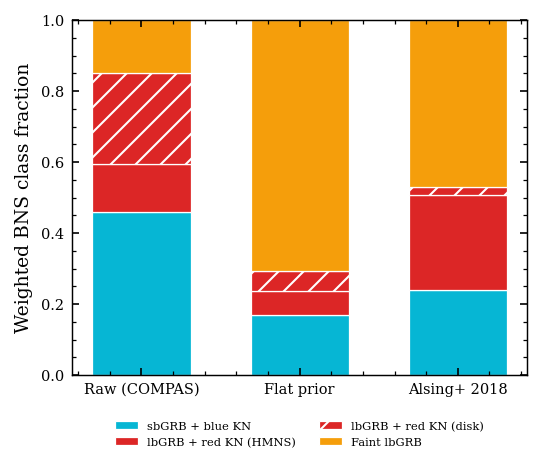

In [5]:
from grb_physics import uniform_mass_cdf

# Three NS-mass treatments of the SAME merging BNS sample, classified under
# the SAME Gottlieb 2024 boundaries and STROOPWAFEL weights.  Raw uses the
# un-remapped COMPAS masses; Flat remaps onto a uniform prior; Alsing is the
# fiducial double Gaussian already applied in Section 0 (m1_bns/m2_bns).
_m1_flat, _m2_flat = remap_ns_masses_double_gaussian(
    m1_bns_raw, m2_bns_raw, weights=w_bns,
    rng=np.random.default_rng(42), target_cdf=uniform_mass_cdf)

REMAP_TREATMENTS = {
    'Raw (COMPAS)': (m1_bns_raw, m2_bns_raw),
    'Flat prior':   (_m1_flat, _m2_flat),
    'Alsing+ 2018': (m1_bns, m2_bns),
}
_BNS_CLASS_KEYS = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                   'lbGRB + red KN (disk)', 'Faint lbGRB']


def _remap_fracs(m1, m2, w):
    cls = classify_bns_2024(m1, m2)
    return np.array([float(w[cls[k]].sum() / w.sum()) for k in _BNS_CLASS_KEYS])


remap_frac = {name: _remap_fracs(m1, m2, w_bns)
              for name, (m1, m2) in REMAP_TREATMENTS.items()}

print(f"{'Treatment':14s} " + "  ".join(f"{k.split(' + ')[0][:8]:>8s}"
                                         for k in _BNS_CLASS_KEYS))
for name, fr in remap_frac.items():
    print(f"{name:14s} " + "  ".join(f"{100 * x:8.1f}" for x in fr))
_span = np.ptp(np.stack(list(remap_frac.values())), axis=0) * 100
print("range (pp)     " + "  ".join(f"{x:8.1f}" for x in _span))
print("lbGRB-producing (1 - sbGRB+blue): " + ", ".join(
    f"{name} {100 * (1 - fr[0]):.1f}%" for name, fr in remap_frac.items()))

# Stacked bars: one column per treatment, segments are the four classes.
_class_colors = [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT]
_class_hatch = [None, None, '//', None]  # disk shares the HMNS red; hatch it
_class_labels = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                 'lbGRB + red KN (disk)', 'Faint lbGRB']
fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
_names = list(remap_frac.keys())
_x = np.arange(len(_names))
_bottom = np.zeros(len(_names))
for j, (lbl, col, hatch) in enumerate(zip(_class_labels, _class_colors, _class_hatch)):
    vals = np.array([remap_frac[n][j] for n in _names])
    ax.bar(_x, vals, bottom=_bottom, width=0.62, color=col, hatch=hatch,
           edgecolor='white', linewidth=0.6, label=lbl)
    _bottom += vals
ax.set_xticks(_x)
ax.set_xticklabels(_names, fontsize=7)
ax.set_ylabel('Weighted BNS class fraction')
ax.set_ylim(0, 1)
ax.legend(fontsize=5.5, frameon=False, loc='upper center',
          bbox_to_anchor=(0.5, -0.10), ncol=2)
fig.savefig('plots/remap_sensitivity_bns.pdf')
fig.savefig('plots/remap_sensitivity_bns.png', dpi=300)
plt.show()

## 3. Delay Time Distributions by GRB Class

Weighted PDFs of $t_\mathrm{delay} = t_\mathrm{form} + t_c$ per Gottlieb (2024) class, for COMPAS Model A (BNS Zenodo 5189849, BHNS Zenodo 5178777).

- Each PDF is normalised within class (shape only; rates in Section 6).
- BNS panel: HMNS solid, disk dashed (both lbGRB sub-classes share palette red).
- Empty bins are NaN-masked so the log step plot does not collapse between populated bins.

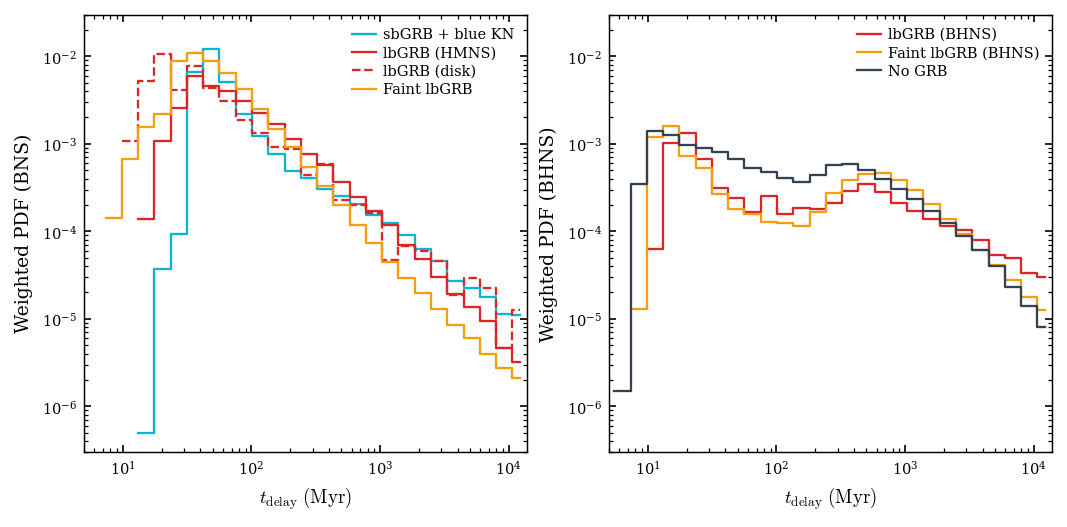

In [6]:
# Lower bin start to 3 Myr so the rising edge of the population (t ~ 5 Myr for
# CE-driven binaries) is shown rather than clipped at the bin wall.  Coarser
# 30 bins kill the single-system spikes that dominated the rare-class panels.
bins_delay = np.logspace(np.log10(3.0), np.log10(14000), 30)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.4),
                               constrained_layout=True)

# Linestyle distinguishes lbGRB (HMNS) from lbGRB (disk): both share the
# project-palette red (C_LB_HMNS == C_LB_DISK == '#DC2626'), so
# they overplot if drawn solid in the same panel.
bns_classes_dly = [
    ('sbGRB + blue KN',  sbGRB_blue,    C_SB_BLUE,  '-'),
    ('lbGRB (HMNS)',     lbGRB_hmns,    C_LB_HMNS,  '-'),
    ('lbGRB (disk)',     lbGRB_disk,    C_LB_DISK,  '--'),
    ('Faint lbGRB',      bns_faint_lb,  C_FAINT,    '-'),
]
bhns_classes_dly = [
    ('lbGRB (BHNS)',        bhns_long,     C_LONG_BH,   '-'),
    ('Faint lbGRB (BHNS)',  bhns_faint_lb, C_FAINT_BH,  '-'),
    ('No GRB',  bhns_no_grb,   C_NO_GRB,    '-'),
]

def _draw_dly(ax, data, mask, w, bins, w_total, color, label, ls):
    h = weighted_hist_pdf(data, mask, w, bins, w_total)
    if h is None:
        return
    x, mu = h
    # Log y-axis: NaN-mask empty bins so step() does not drop a vertical edge
    # to zero between populated bins.
    mu_plot = np.where(mu > 0, mu, np.nan)
    ax.step(x, mu_plot, where='mid', color=color, lw=1.1, ls=ls, label=label)

# Per-class, clip-aware w_total: each curve integrates to 1 over the visible
# bin range [3, 14000] Myr (any class members outside that range, e.g., the
# rare sub-3-Myr post-CE inspirals, are excluded from both numerator and
# denominator).  Abundance information is rebuilt with rate units in Section 6.
in_range_bns = (delay_bns >= bins_delay[0]) & (delay_bns <= bins_delay[-1])
in_range_bhns = (delay_bhns >= bins_delay[0]) & (delay_bhns <= bins_delay[-1])
for lbl, mask, c, ls in bns_classes_dly:
    _draw_dly(ax1, delay_bns, mask, w_bns, bins_delay,
              w_bns[mask & in_range_bns].sum(), c, lbl, ls)
for lbl, mask, c, ls in bhns_classes_dly:
    _draw_dly(ax2, delay_bhns, mask, w_bhns, bins_delay,
              w_bhns[mask & in_range_bhns].sum(), c, lbl, ls)

# Shared y-axis so the ~1-decade amplitude gap between BNS and BHNS PDFs
# (BNS peaks ~1.5e-2 near t ~ 30 Myr; BHNS peaks ~1.5e-3) reads directly.
# Limits trimmed to the populated region: data only reaches down to ~5e-7
# (BNS) / ~1.5e-6 (BHNS), and the first populated bin starts near 5 Myr.
for ax, ylab in ((ax1, 'Weighted PDF (BNS)'),
                 (ax2, 'Weighted PDF (BHNS)')):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(5e0, bins_delay[-1])
    ax.set_ylim(3e-7, 3e-2)
    ax.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
    ax.set_ylabel(ylab)

ax1.legend(
    loc='upper right', fontsize=7, frameon=False,
    handlelength=1.6, handletextpad=0.5, labelspacing=0.3,
    ncol=1,
)
ax2.legend(
    loc='upper right', fontsize=7, frameon=False,
    handlelength=1.6, handletextpad=0.5, labelspacing=0.3,
    ncol=1,
)

fig.savefig('plots/delay_time_distributions.png', dpi=300)
fig.savefig('plots/delay_time_distributions.pdf')
plt.show()


**Figure 3.** Delay-time distributions of merging compact binaries by Gottlieb (2024) GRB class. Left: BNS sample (Zenodo 5189849), four hybrid classes. Right: BHNS sample (Zenodo 5178777), three disk-mass classes. Each curve is STROOPWAFEL-weighted and per-class normalised over the visible range $t_\mathrm{delay} \in [3, 14000]$ Myr (shape only; abundance enters with rate units in Section 6). Samples as in Figure 2; the weighted-Poisson per-bin uncertainty is below the line width at these effective sample sizes (coarse 30-bin logarithmic spacing further suppresses single-system spikes), so no shaded band is drawn. The two lbGRB + red KN BNS classes share project red `#DC2626` (HMNS solid, disk dashed).

## 3b. Delay Time per GRB Class, Split by Formation Channel

The channel companion to Section 3: each Gottlieb (2024) class panel shows the weighted delay-time PDF decomposed onto the Broekgaarden et al. (2021, 2022) formation channels (I-V). Per-channel curves are normalised by the class in-range weight, so the populated channels (BNS: I, IV; BHNS: I, II) sum to the dotted per-class total. BHNS misalignment enters the rate as a flat 0.5 scalar (`apply_bhns_misalignment`) and leaves the shape unchanged, so these are intrinsic shapes. Bins reuse the Section 3 grid.

Delay-time channel fractions (weighted, within class)
  BNS  sbGRB + blue KN          I (Stable MT + CE)=0.84  IV (Double-core CE)=0.16
  BNS  lbGRB (HMNS)             I (Stable MT + CE)=0.15  IV (Double-core CE)=0.85
  BNS  lbGRB (disk)             I (Stable MT + CE)=0.42  IV (Double-core CE)=0.58
  BNS  Faint lbGRB              I (Stable MT + CE)=0.01  IV (Double-core CE)=0.99
  BHNS No GRB                   I (Stable MT + CE)=0.96  II (Stable MT only)=0.02  IV (Double-core CE)=0.02
  BHNS Faint lbGRB (BHNS)       I (Stable MT + CE)=0.83  II (Stable MT only)=0.11  IV (Double-core CE)=0.06
  BHNS lbGRB + red KN (BHNS disk) I (Stable MT + CE)=0.53  II (Stable MT only)=0.29  IV (Double-core CE)=0.18


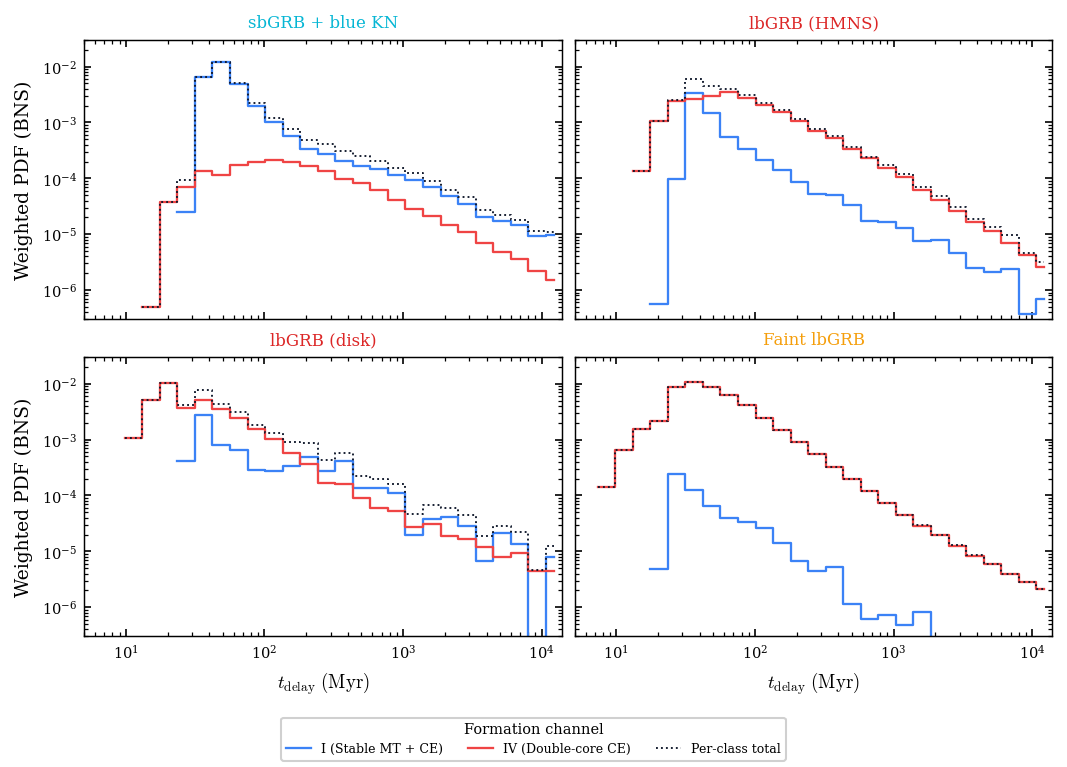

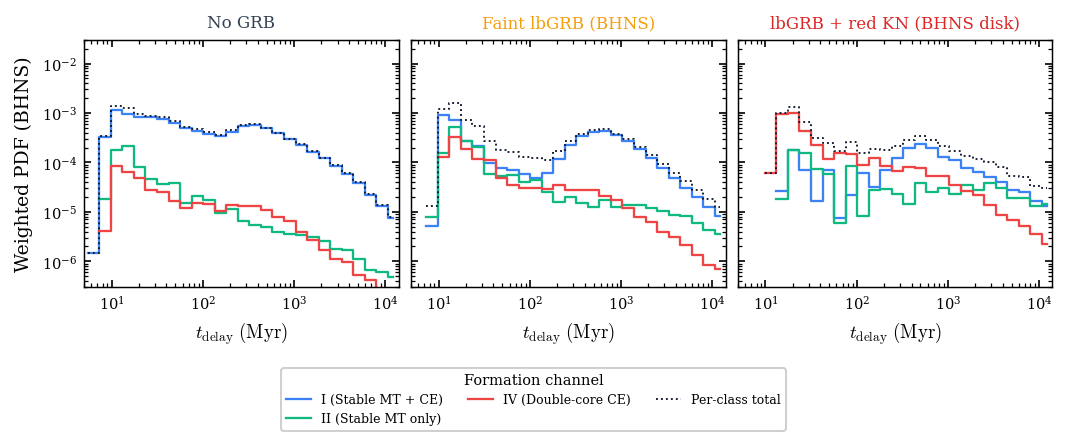

In [7]:
# Delay-time PDF per GRB class, decomposed by Broekgaarden channel.  Each
# channel curve is normalised by the class in-range weight (w_total), so the
# populated channels reconstruct the dotted per-class total.  Reuses
# bins_delay from Section 3 and the NaN-masked log-step idiom.
in_range_bns  = (delay_bns  >= bins_delay[0]) & (delay_bns  <= bins_delay[-1])
in_range_bhns = (delay_bhns >= bins_delay[0]) & (delay_bhns <= bins_delay[-1])

bns_classes_3b = [
    ('sbGRB + blue KN', sbGRB_blue,   C_SB_BLUE),
    ('lbGRB (HMNS)',    lbGRB_hmns,   C_LB_HMNS),
    ('lbGRB (disk)',    lbGRB_disk,   C_LB_DISK),
    ('Faint lbGRB',     bns_faint_lb, C_FAINT),
]
bhns_classes_3b = [
    ('No GRB',                     bhns_no_grb,   C_NO_GRB),
    ('Faint lbGRB (BHNS)',         bhns_faint_lb, C_FAINT_BH),
    ('lbGRB + red KN (BHNS disk)', bhns_long,     C_LONG_BH),
]

def _draw_channels_delay(ax, data, class_mask, in_range, w, ch_dict):
    w_total = w[class_mask & in_range].sum()
    if w_total <= 0:
        return
    for ch_label, ch_mask in ch_dict.items():
        h = weighted_hist_pdf(data, class_mask & ch_mask, w, bins_delay, w_total)
        if h is None:
            continue
        x, mu = h
        if not np.any(mu > 0):
            continue
        ax.step(x, np.where(mu > 0, mu, np.nan), where='mid',
                color=CH_COLORS[ch_label], lw=1.1, label=_pretty_ch(ch_label))
    h_tot = weighted_hist_pdf(data, class_mask, w, bins_delay, w_total)
    if h_tot is not None:
        x, mu = h_tot
        ax.step(x, np.where(mu > 0, mu, np.nan), where='mid',
                color=C_TEXT, lw=0.9, ls=':', label='Per-class total')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(5e0, bins_delay[-1])
    ax.set_ylim(3e-7, 3e-2)

def _channel_legend(axes_flat):
    handles, labels = [], []
    for ax in axes_flat:
        for hi, li in zip(*ax.get_legend_handles_labels()):
            if li not in labels:
                handles.append(hi)
                labels.append(li)
    return handles, labels

# Weighted channel fractions within each class (sanity print; channel curves
# integrate to these fractions and sum to 1 per class by construction).
print('Delay-time channel fractions (weighted, within class)')
for cl_label, cl_mask, _ in bns_classes_3b:
    wc = w_bns[cl_mask].sum()
    parts = [f"{_pretty_ch(c)}={w_bns[cl_mask & m].sum() / wc:.2f}"
             for c, m in channels.items() if w_bns[cl_mask & m].sum() / wc > 1e-3]
    print(f"  BNS  {cl_label:24s} " + '  '.join(parts))
for cl_label, cl_mask, _ in bhns_classes_3b:
    wc = w_bhns[cl_mask].sum()
    parts = [f"{_pretty_ch(c)}={w_bhns[cl_mask & m].sum() / wc:.2f}"
             for c, m in channels_bhns.items() if w_bhns[cl_mask & m].sum() / wc > 1e-3]
    print(f"  BHNS {cl_label:24s} " + '  '.join(parts))

# BNS: 2x2 over the four Gottlieb classes.
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (cl_label, cl_mask, cl_color) in zip(axes.flat, bns_classes_3b):
    _draw_channels_delay(ax, delay_bns, cl_mask, in_range_bns, w_bns, channels)
    ax.set_title(cl_label, color=cl_color, fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
for ax in axes[:, 0]:
    ax.set_ylabel('Weighted PDF (BNS)')
handles, labels = _channel_legend(axes.flat)
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=6,
           frameon=True, title='Formation channel', title_fontsize=7)
fig.savefig('plots/delay_time_by_class_per_channel.pdf')
fig.savefig('plots/delay_time_by_class_per_channel.png', dpi=300)
plt.show()

# BHNS: 1x3 over the Gottlieb hybrid BHNS classes.
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (cl_label, cl_mask, cl_color) in zip(axes, bhns_classes_3b):
    _draw_channels_delay(ax, delay_bhns, cl_mask, in_range_bhns, w_bhns, channels_bhns)
    ax.set_title(cl_label, color=cl_color, fontsize=8)
    ax.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
axes[0].set_ylabel('Weighted PDF (BHNS)')
handles, labels = _channel_legend(axes)
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=6,
           frameon=True, title='Formation channel', title_fontsize=7)
fig.savefig('plots/delay_time_bhns_by_class_per_channel.pdf')
fig.savefig('plots/delay_time_bhns_by_class_per_channel.png', dpi=300)
plt.show()

**Figure 3b.** Weighted delay-time PDFs per Gottlieb (2024) GRB class, decomposed by Broekgaarden et al. (2021, 2022) formation channel. Sample: COMPAS Model A (BNS Zenodo 5189849, BHNS Zenodo 5178777), STROOPWAFEL-weighted, NS masses Alsing-remapped. Top figure: four BNS classes (channels I Stable MT + CE, IV Double-core CE populated). Bottom figure: three BHNS hybrid classes (channels I, II populated). Within each panel curves are normalised by the class in-range weight so channel curves sum to the dotted per-class total; the panels show distribution shape, not relative abundance (rates are in Sections 6 and 7). Cosmology Planck 2015.

## 4. Cosmic Integration: MSSFR Grid Setup

Setup for Sections 5, 6, 7, 9. Fiducial MSSFR is Levina et al. (2026, [arXiv:2601.20202](https://arxiv.org/abs/2601.20202)) Table 1 TNG100-1: Madau and Dickinson (2014) $S(z)$ ($a=0.0172, b=1.4425, c=4.5299, d=6.2261$) convolved with an Azzalini skew-log-normal $dP/d\ln Z$ ($\mu_0=0.0247, \mu_z=-0.0521, \omega_0=1.1509, \omega_z=0.0477, \alpha=-1.8801$). Cosmology is Planck 2015 ($H_0 = 67.74$ km/s/Mpc, $\Omega_m = 0.3089$) to match COMPAS `FastCosmicIntegration`; `grb_rates.compute_merger_rate` chunks the FCI loop.

**CE prescription.** Webbink (1984) $\alpha$-formalism with $\alpha_\mathrm{CE}=1.0$ (Model A; F=0.5, G=2.0 in Section 9), Xu and Li (2010) $\lambda_\mathrm{CE}$, Hurley et al. (2002) $\zeta_\mathrm{ad}$. Pinned in `grb_rates.CE_PRESCRIPTION_BROEKGAARDEN21`.

$M_\mathrm{evolved}$ is back-derived from the COMPAS `weights_intrinsic/w_000` anchor (sampler-mass calibration only, MSSFR-independent). `dPdlogZ` is per $d(\ln Z)$, not $d(\log_{10} Z)$.

In [8]:
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'COMPAS'))
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params, find_sfr, find_metallicity_distribution)
from grb_rates import (SFR_PARAMS_LEVINA26_TNG100, MSSFR_PARAMS_LEVINA26_TNG100)

# Planck 2015 (H0 = 67.74, Om = 0.3089, OmL = 0.6911) to
# match COMPAS FastCosmicIntegration TNG-consistent values.  COMPAS
# cosmology.py defaults to Planck18, so we pass Planck15 explicitly to every
# call; otherwise distances and shell volumes drift by ~2 percent at high z.
from astropy.cosmology import Planck15 as PLANCK15
assert abs(PLANCK15.H0.value - 67.74) < 0.01

redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01,
                                       cosmology=PLANCK15)

# Fiducial MSSFR / SFR: Levina+ 2026 (arXiv:2601.20202) Table 1 best fit to
# IllustrisTNG TNG100-1.  Madau and Dickinson (2014) S(z) form, Azzalini
# skew-log-normal dP/dlnZ, alpha = -1.88 gives a long low-Z tail.
sfr = find_sfr(redshifts, **SFR_PARAMS_LEVINA26_TNG100)

Z_range_bns = verify_shared_metallicity_prior(DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(Z_range_bns[0]),
    max_logZ_COMPAS=np.log(Z_range_bns[1]),
    **MSSFR_PARAMS_LEVINA26_TNG100)

try:
    dPdlogZ_norm = check_dPdlogZ_normalization(dPdlogZ, metallicities, rtol=0.10)
except ValueError:
    dlogZ = np.diff(np.log(metallicities))
    dlogZ = np.append(dlogZ, dlogZ[-1])
    dPdlogZ = dPdlogZ / (dPdlogZ * dlogZ[None, :]).sum(axis=1)[:, None]
    dPdlogZ_norm = (dPdlogZ * dlogZ[None, :]).sum(axis=1)

# Per-population MEAN_MASS_EVOLVED back-derived from upstream w_000 anchor.
# w_000 was pre-computed by the Broekgaarden+ 2021 cosmic integration with
# Neijssel+ 2019 MSSFR; calibrate_mean_mass_evolved re-runs that calculation
# internally and divides by expected_local_rate to recover the simulation's
# true total stellar mass evolved (a sampler property, MSSFR-independent),
# which we then feed into the Levina TNG100-1 forward pass below.
expected_rate_bns  = read_expected_local_rate(DEFAULT_BNS_PATH)
expected_rate_bhns = read_expected_local_rate(DEFAULT_BHNS_PATH)

mean_mass_bns = calibrate_mean_mass_evolved(
    redshifts, times, time_first_SF,
    Z_bns, delay_bns, w_bns, expected_rate_bns,
    Z_min_COMPAS=Z_range_bns[0], Z_max_COMPAS=Z_range_bns[1])
mean_mass_bhns = calibrate_mean_mass_evolved(
    redshifts, times, time_first_SF,
    Z_bhns, delay_bhns, w_bhns, expected_rate_bhns,
    Z_min_COMPAS=Z_range_bns[0], Z_max_COMPAS=Z_range_bns[1])
n_formed_BNS  = sfr / mean_mass_bns
n_formed_BHNS = sfr / mean_mass_bhns

print(f"SFR(z=0)            = {sfr[0]:.3e} Msun/yr/Gpc^3 (Levina+26 TNG100-1)")
print(f"dPdlogZ integral    in [{dPdlogZ_norm.min():.3f}, {dPdlogZ_norm.max():.3f}]")
print(f"p_draw              = {p_draw:.6f}")
print(f"BNS  R_loc anchor   = {expected_rate_bns:6.1f} Gpc^-3 yr^-1 (Neijssel w_000), "
      f"M_evolved = {mean_mass_bns:.3e} Msun")
print(f"BHNS R_loc anchor   = {expected_rate_bhns:6.1f} Gpc^-3 yr^-1 (Neijssel w_000), "
      f"M_evolved = {mean_mass_bhns:.3e} Msun")


SFR(z=0)            = 1.720e+07 Msun/yr/Gpc^3 (Levina+26 TNG100-1)
dPdlogZ integral    in [1.000, 1.000]
p_draw              = 0.175322
BNS  R_loc anchor   =   33.4 Gpc^-3 yr^-1 (Neijssel w_000), M_evolved = 2.804e+09 Msun
BHNS R_loc anchor   =   43.0 Gpc^-3 yr^-1 (Neijssel w_000), M_evolved = 4.053e+09 Msun


## 4b. TNG-Resolution Sweep: TNG50-1 / TNG100-1 / TNG300-1

Robustness check on the MSSFR fiducial. Levina et al. (2026, arXiv:2601.20202, Sec. 3.2) report a factor 2 to 3 resolution effect on the local BBH rate (Table 2, analytical fit):

- TNG50-1: $\mathcal{R}_\mathrm{BBH}(z=0) = 73.7\ \mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$
- TNG100-1: $45.5$ (fiducial throughout the notebook)
- TNG300-1: $27.8$

`compute_merger_rate` runs once per variant via `LEVINA26_TNG_VARIANTS`; the TNG50 to TNG300 spread brackets the simulation-resolution systematic on the BNS rate.

TNG          R_BNS(z=0,raw)    R_BNS(z=0,sm)     Levina BBH R_fit
  TNG50-1           94.971          124.994         73.72
  TNG100-1          54.984           72.620         45.53
  TNG300-1          32.759           44.556         27.81


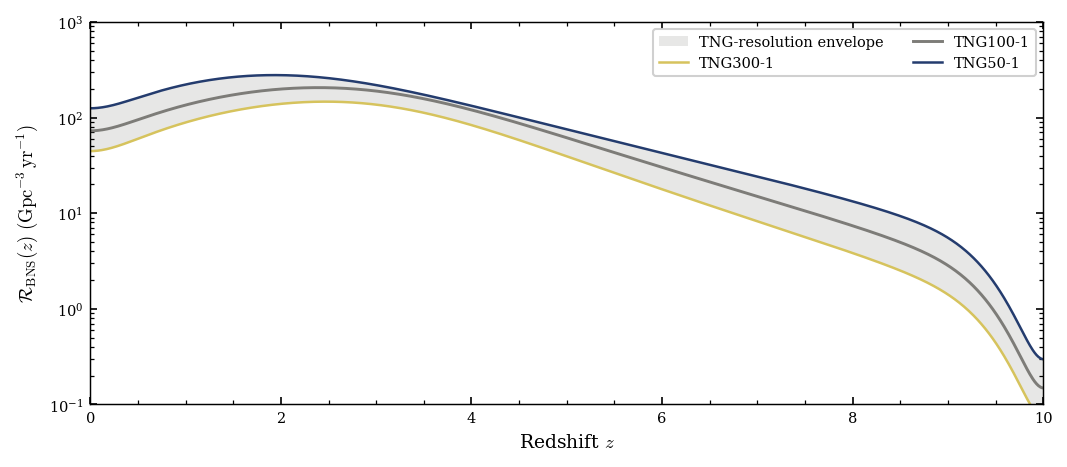

In [9]:
from grb_rates import LEVINA26_TNG_VARIANTS, LEVINA26_BBH_LOCAL_RATES
from scipy.ndimage import gaussian_filter1d

# Per-variant cosmic integration on the BNS A sample.  Reuses the existing
# (redshifts, times, time_first_SF, mean_mass_bns, Z_bns/delay_bns/w_bns)
# globals from Section 4 so the sweep is apples-to-apples (same cosmology,
# same Z-grid prior, same Alsing-remapped masses, only the Levina
# parameters differ).
#
# Two arrays kept per variant:
#   _R_bns_per_tng_raw[name] : unsmoothed compute_merger_rate output (the
#       physical R(z); used for the calibration-aware R(z=0) column).
#   _R_bns_per_tng[name]     : cosmetically smoothed copy used in the plot
#       (sigma=30 redshift bins; smoothes the discrete-Z-grid jaggedness).
# Splitting the two avoids the gaussian_filter1d reflective-boundary
# inflation of R(z=0) by ~factor 2 from contaminating the printed rates;
# the calibration-anchor invariant in grb_rates.calibrate_mean_mass_evolved
# uses smooth_sigma=0 for the same reason (CLAUDE.md "Calibration uses the
# unsmoothed convolution").
_R_bns_per_tng_raw = {}
_R_bns_per_tng = {}
for _name, (_sfr_p, _mssfr_p) in LEVINA26_TNG_VARIANTS.items():
    _sfr_v = find_sfr(redshifts, **_sfr_p)
    _dPdlogZ_v, _mets_v, _p_draw_v = find_metallicity_distribution(
        redshifts,
        min_logZ_COMPAS=np.log(Z_range_bns[0]),
        max_logZ_COMPAS=np.log(Z_range_bns[1]),
        **_mssfr_p,
    )
    _R_raw = compute_merger_rate(
        redshifts, times, time_first_SF, _sfr_v / mean_mass_bns, _p_draw_v,
        _dPdlogZ_v, _mets_v,
        Z_bns, delay_bns, w_bns,
        smooth_sigma=0,
    )
    _R_bns_per_tng_raw[_name] = _R_raw
    _R_bns_per_tng[_name] = gaussian_filter1d(_R_raw, sigma=30)

# Cividis triplet (perceptually uniform and colorblind-safe; the
# alternatives are viridis or batlow).  Section 9 reuses the same sampling indices
# (0.15, 0.50, 0.85) for its alpha_CE / NS_max sweep.
_cividis_tng = plt.get_cmap("cividis")(np.array([0.15, 0.50, 0.85]))
_tng_colours = {
    "TNG50-1":  tuple(_cividis_tng[0]),
    "TNG100-1": tuple(_cividis_tng[1]),
    "TNG300-1": tuple(_cividis_tng[2]),
}
_tng_styles = {
    "TNG50-1":  ("-",  1.2),
    "TNG100-1": ("-",  1.4),
    "TNG300-1": ("-",  1.2),
}

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
ax.fill_between(
    redshifts,
    np.minimum(_R_bns_per_tng["TNG50-1"], _R_bns_per_tng["TNG300-1"]),
    np.maximum(_R_bns_per_tng["TNG50-1"], _R_bns_per_tng["TNG300-1"]),
    color=_tng_colours["TNG100-1"], alpha=0.18, lw=0,
    label="TNG-resolution envelope",
)
for _name in ("TNG300-1", "TNG100-1", "TNG50-1"):
    _ls, _lw = _tng_styles[_name]
    ax.plot(redshifts, _R_bns_per_tng[_name],
            color=_tng_colours[_name], ls=_ls, lw=_lw, label=_name)
ax.set_xlim(0, 10)
ax.set_yscale("log")
ax.set_ylim(0.1, 1e3)
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mathcal{R}_\mathrm{BNS}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$")
ax.legend(fontsize=7, loc="upper right", ncol=2, framealpha=0.92)

# R(z=0) sanity table.  R(z=0,raw) is the physical unsmoothed value (the
# right number to compare against any external reference or anchor);
# R(z=0,sm) is the cosmetically smoothed value that the plot shows, and
# sits ~2x higher because gaussian_filter1d's reflective boundary at z=0
# folds in the rising side of R(z).  Both columns preserve the Levina
# Table 2 BBH ordering (TNG50 > TNG100 > TNG300).
iz0 = int(np.argmin(np.abs(redshifts)))
print(f"{'TNG':10s} {'R_BNS(z=0,raw)':>16s} {'R_BNS(z=0,sm)':>16s}   {'Levina BBH R_fit':>18s}")
for _name in _R_bns_per_tng_raw:
    _R0_raw = float(_R_bns_per_tng_raw[_name][iz0])
    _R0_sm  = float(_R_bns_per_tng[_name][iz0])
    _R_bbh_fit = LEVINA26_BBH_LOCAL_RATES[_name]["R_fit"]
    print(f"  {_name:8s}  {_R0_raw:14.3f}   {_R0_sm:14.3f}        {_R_bbh_fit:6.2f}")

fig.savefig("plots/rate_bns_tng_sweep.png", dpi=300)
fig.savefig("plots/rate_bns_tng_sweep.pdf")
plt.show()

### 4c. Absolute-rate cross-check: predicted LVK detection counts

The per-population `MEAN_MASS_EVOLVED` is back-derived so the calibrated $\mathcal{R}(z=0)$ reproduces the Broekgaarden+ 2021 $w_{000}$ anchor by construction, so $\mathcal{R}(z=0)$ cannot validate the normalization: it is the calibration fixed point. An independent check has to stress the rate at $z > 0$. The detector-frame detection count does this: it integrates the detectable subset of the intrinsic rate over $z \in [0, 1]$ (FCI `max_redshift_detection = 1.0`), weighted by LVK O3 sensitivity, so it depends on the full $\mathcal{R}(z)$ shape and normalization, not just the $z=0$ value.

We fold the FCI SNR/detection grids into the same cosmic integration via `detected_rate` and sum $\mathcal{R}_\mathrm{det}(z)\,\Delta V_c(z)/(1+z)$ to get predicted detections per detector-frame year. For context, O3 (about 1.5 yr coincident) yielded one confident BNS (GW190425) and two NSBH (GW200105, GW200115), order unity per year per class.

In [10]:
from grb_rates import detected_rate

# Detectable-redshift slice and comoving-shell weighting (the 1/(1+z) factor
# converts source-frame yr^-1 to detector-frame yr^-1).  shell_volumes and
# distances come from the Section 4 calculate_redshift_related_params call.
_z_det = redshifts[:n_z_detect]
_vol_det = shell_volumes[:n_z_detect] / (1.0 + _z_det)

R_det_bns = detected_rate(
    redshifts, times, time_first_SF, n_formed_BNS, p_draw, dPdlogZ,
    metallicities, m1_bns, m2_bns, Z_bns, delay_bns, w_bns,
    distances, n_z_detect, sensitivity='O3')
R_det_bhns = detected_rate(
    redshifts, times, time_first_SF, n_formed_BHNS, p_draw, dPdlogZ,
    metallicities, BH, NS_bh, Z_bhns, delay_bhns, w_bhns,
    distances, n_z_detect, sensitivity='O3')

N_det_bns = float((R_det_bns * _vol_det).sum())
N_det_bhns = float((R_det_bhns * _vol_det).sum())

# Observed O3 yield for context (about 1.5 yr coincident livetime): 1 BNS, 2 NSBH.
_O3_LIVETIME_YR = 1.5
print("Predicted detections per detector-frame year (sensitivity = 'O3'):")
print(f"  BNS : {N_det_bns:7.2f} /yr  -> {N_det_bns * _O3_LIVETIME_YR:5.1f} "
      f"over ~{_O3_LIVETIME_YR} yr O3   (observed: 1 BNS)")
print(f"  BHNS: {N_det_bhns:7.2f} /yr  -> {N_det_bhns * _O3_LIVETIME_YR:5.1f} "
      f"over ~{_O3_LIVETIME_YR} yr O3   (observed: 2 NSBH)")
print("Cross-check integrates R(z) over z in [0, 1]; independent of the "
      "z=0 calibration fixed point.")

Predicted detections per detector-frame year (sensitivity = 'O3'):
  BNS :    0.59 /yr  ->   0.9 over ~1.5 yr O3   (observed: 1 BNS)
  BHNS:    5.09 /yr  ->   7.6 over ~1.5 yr O3   (observed: 2 NSBH)
Cross-check integrates R(z) over z in [0, 1]; independent of the z=0 calibration fixed point.


## 5. Metallicity Dependence of GRB Formation Efficiency

Formation efficiency $\eta(Z)$ (mergers per $M_\odot$ formed) per Gottlieb (2024) BNS class and per disk-mass BHNS class. Lower $Z$ produces heavier remnants and tilts the class balance, propagating to $z$ via the Section 4 MSSFR convolution. $Z_\odot = 0.0142$ (Asplund et al. 2009).

The efficiency is intensive: $\eta(Z_i) = (\sum_{Z_i} w)\,/\,M_\mathrm{SF}(Z_i)$, with the per-metallicity star-forming mass $M_\mathrm{SF}(Z_i) = M_\mathrm{evolved}\,f_i$ split by the COMPAS uniform-in-$\ln Z$ prior $f_i = \Delta(\ln Z)_i / \ln(Z_\mathrm{max}/Z_\mathrm{min})$ (the same $p_\mathrm{draw}$ the rate path uses). Dividing by the per-$Z$ mass keeps $\eta(Z)$ binning-independent and on the Broekgaarden+ 2021 (Fig. 5) axis; the bare scalar total would suppress every bin by $\sim 1/f_i$. The per-$Z$ mass is modeled from the prior, since the reduced COMPAS files retain only DCO progenitors.

The 53-point COMPAS grid is pooled into 15 equal-count log-$Z$ bins (display only; the cosmic-integration path is unchanged). A bin is kept only when raw $N \geq 50$, Kish (1965) $n_\mathrm{eff} \geq 10$, and $Z \leq Z_\odot$ (`LOGZ_MAX_PHYSICAL = 0`; above-solar star formation is negligible in the Levina+ 2026 fit). The $n_\mathrm{eff} \geq 10$ gate already bounds the per-bin weighted-Poisson error at $\sim 1/\sqrt{10}$, so no error bars are drawn. The two lbGRB + red KN classes share project red (solid HMNS, dashed disk).

BNS : 15/15 coarse bins kept (N >= 50, ESS >= 10, Z <= Zsun); coverage Z/Zsun [0.008, 0.894]
BHNS: 15/15 coarse bins kept (N >= 50, ESS >= 10, Z <= Zsun); coverage Z/Zsun [0.008, 0.894]


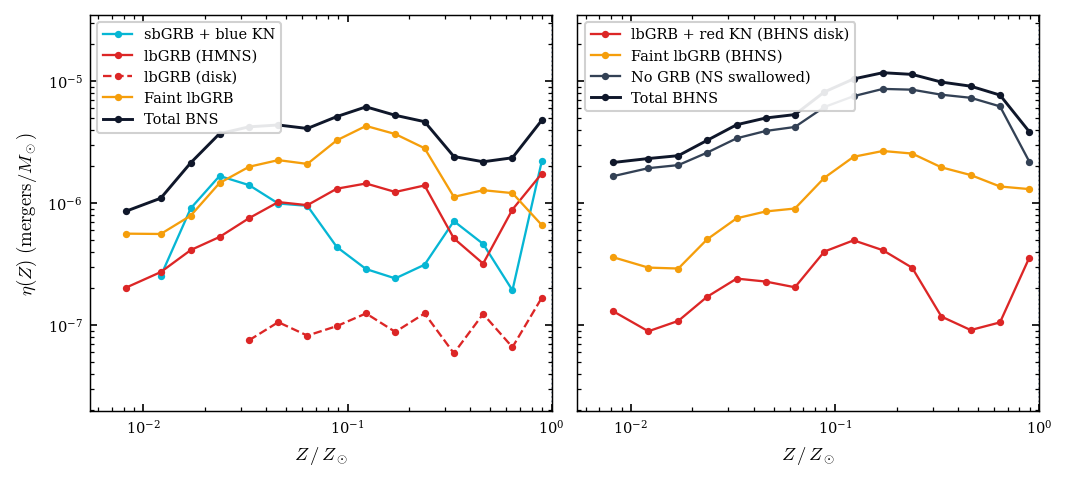

In [11]:
eff_bns_masks = {'sbGRB + blue KN': sbGRB_blue,
                 'lbGRB (HMNS)':    lbGRB_hmns,
                 'lbGRB (disk)':    lbGRB_disk,
                 'Faint lbGRB':     bns_faint_lb}
eff_bhns_masks = {'lbGRB + red KN (BHNS disk)': bhns_long,
                  'Faint lbGRB (BHNS)':         bhns_faint_lb,
                  'No GRB (NS swallowed)':      bhns_no_grb}

Z_SUN = 0.0142
_uniq_mask = np.concatenate(([True], np.diff(METALLICITY_GRID) != 0))
Z_grid = METALLICITY_GRID[_uniq_mask]
Z_over_Zsun = Z_grid / Z_SUN
Z_PHYS_MAX  = (10.0 ** LOGZ_MAX_PHYSICAL) * Z_SUN
N_MIN, ESS_MIN = 50, 10.0

# A coarse bin needs N_raw >= N_MIN (basic floor) AND Kish (1965) ESS >= ESS_MIN
# (rules out bins dominated by 1-2 high-weight STROOPWAFEL systems) AND
# Z <= Z_PHYS_MAX (LOGZ_MAX_PHYSICAL truncation, Levina+ 2026 TNG100-1; cosmic
# star formation above solar is negligible so the high-Z tail is sampling noise).
#
# Display binning only; the physics path (compute_merger_rate) is untouched.
# CODE HEURISTIC: the native COMPAS metallicity grid is fine enough that small
# per-class (and per-channel, Section 5b) subsets fail the N/ESS gate in most
# native bins, leaving a jagged, broken curve.  Pooling the sub-solar grid into
# N_Z_BINS_COARSE equal-count log-Z bins puts enough weighted systems in each
# bin to clear the gate and read smoothly; eta(Z) stays additive over disjoint
# masks because it is a weighted sum divided by a shared mean_mass_evolved.
N_Z_BINS_COARSE = 15

def _bin_sums(Z, w, mask, grid):
    """Per native-grid weighted sums (Sw, Sw2) and raw count for `mask`."""
    Zs = Z[mask]
    ws = w[mask].astype(float)
    idx = np.searchsorted(grid, Zs)
    in_grid = (idx < len(grid)) & np.isclose(Zs, grid[np.clip(idx, 0, len(grid) - 1)])
    idx, ws = idx[in_grid], ws[in_grid]
    Sw  = np.bincount(idx, weights=ws,      minlength=len(grid))
    Sw2 = np.bincount(idx, weights=ws * ws, minlength=len(grid))
    N   = np.bincount(idx,                  minlength=len(grid))
    return Sw, Sw2, N

# Equal-count grouping of the sub-solar native grid into coarse log-Z bins,
# with each coarse point placed at the geometric mean of its native members.
_ok_grid = np.where(Z_grid <= Z_PHYS_MAX)[0]
_grp = (np.arange(len(_ok_grid)) * N_Z_BINS_COARSE // len(_ok_grid))
_cnt = np.bincount(_grp, minlength=N_Z_BINS_COARSE)
Zc = np.exp(np.bincount(_grp, weights=np.log(Z_grid[_ok_grid]),
                        minlength=N_Z_BINS_COARSE) / _cnt)
Zc_over_Zsun = Zc / Z_SUN

# Per-metallicity star-forming mass: split the population total
# (mean_mass_evolved) by the COMPAS uniform-in-ln Z sampling prior, so eta(Z)
# is the intensive yield (mergers per Msun formed AT each Z) that Broekgaarden+
# 2021 (arXiv:2103.02608) Fig. 5 plots.  f_native sums to 1 over the full grid;
# f_coarse pools the kept sub-solar bins exactly as Sw does below, so eta stays
# independent of the coarse binning.  Dividing by the bare scalar total instead
# would suppress every bin by ~1/f (the number of sampled metallicities).
f_native = metallicity_prior_mass_fraction(Z_grid)
f_coarse = np.bincount(_grp, weights=f_native[_ok_grid], minlength=N_Z_BINS_COARSE)

def _eta_binned(Z, w, mask, mean_mass):
    """Coarse-bin eta(Z) and the N/ESS gate mask (Kish ESS via Sw2c)."""
    Sw, Sw2, N = _bin_sums(Z, w, mask, Z_grid)
    Swc  = np.bincount(_grp, weights=Sw[_ok_grid],  minlength=N_Z_BINS_COARSE)
    Sw2c = np.bincount(_grp, weights=Sw2[_ok_grid], minlength=N_Z_BINS_COARSE)
    Nc   = np.bincount(_grp, weights=N[_ok_grid],   minlength=N_Z_BINS_COARSE)
    eta = Swc / (mean_mass * f_coarse)
    with np.errstate(invalid='ignore', divide='ignore'):
        ess = np.where(Sw2c > 0, Swc * Swc / Sw2c, 0.0)
    ok = (Nc >= N_MIN) & (ess >= ESS_MIN)
    return eta, ok

def _plot_eta(ax, eta, ok, color, ls, label, lw=1.1):
    y = np.where(ok & (eta > 0), eta, np.nan)
    ax.plot(Zc_over_Zsun, y, color=color, ls=ls, lw=lw,
            marker='o', ms=2.5, label=label)

def _coverage(name, Z, w, mean_mass):
    _, ok = _eta_binned(Z, w, np.ones(len(Z), dtype=bool), mean_mass)
    n_kept = int(ok.sum())
    if n_kept == 0:
        print(f'{name}: 0/{N_Z_BINS_COARSE} coarse bins kept; no coverage')
        return
    print(f'{name}: {n_kept:>2d}/{N_Z_BINS_COARSE} coarse bins kept '
          f'(N >= {N_MIN}, ESS >= {ESS_MIN:.0f}, Z <= Zsun); '
          f'coverage Z/Zsun [{Zc_over_Zsun[ok].min():.3f}, '
          f'{Zc_over_Zsun[ok].max():.3f}]')

_coverage('BNS ', Z_bns,  w_bns,  mean_mass_bns)
_coverage('BHNS', Z_bhns, w_bhns, mean_mass_bhns)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.1), sharey=True,
                         constrained_layout=True)

# Top row: per-class eta(Z) on the coarse bins.  ``lbGRB (HMNS)`` and
# ``lbGRB (disk)`` share the project red ``#DC2626`` so disk is dashed
# (matching Sections 2 / 7).
_yacc = []
def _draw_efficiency(ax, masks, classes, Z, w, mean_mass, total_label):
    for lbl, c, ls in classes:
        eta, ok = _eta_binned(Z, w, masks[lbl], mean_mass)
        _plot_eta(ax, eta, ok, c, ls, lbl)
        _yacc.append(eta[ok & (eta > 0)])
    eta_t, ok_t = _eta_binned(Z, w, np.ones(len(Z), dtype=bool), mean_mass)
    _plot_eta(ax, eta_t, ok_t, C_TEXT, '-', total_label, lw=1.4)
    _yacc.append(eta_t[ok_t & (eta_t > 0)])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(1.0, color=C_GUIDE, lw=0.8, ls=':', zorder=0)
    ax.set_xlabel(r'$Z\,/\,Z_\odot$')

_draw_efficiency(axes[0], eff_bns_masks,
                 [('sbGRB + blue KN', C_SB_BLUE, '-'),
                  ('lbGRB (HMNS)',    C_LB_HMNS, '-'),
                  ('lbGRB (disk)',    C_LB_DISK, '--'),
                  ('Faint lbGRB',     C_FAINT,   '-')],
                 Z_bns, w_bns, mean_mass_bns, 'Total BNS')
axes[0].set_ylabel(r'$\eta(Z)\ (\mathrm{mergers}/M_\odot)$')
axes[0].legend(fontsize=7, loc='upper left', framealpha=0.9)

_draw_efficiency(axes[1], eff_bhns_masks,
                 [('lbGRB + red KN (BHNS disk)', C_LONG_BH,  '-'),
                  ('Faint lbGRB (BHNS)',         C_FAINT_BH, '-'),
                  ('No GRB (NS swallowed)',      C_NO_GRB,   '-')],
                 Z_bhns, w_bhns, mean_mass_bhns, 'Total BHNS')
axes[1].legend(fontsize=7, loc='upper left', framealpha=0.9)

if _yacc:
    _allv = np.concatenate([a for a in _yacc if a.size])
    axes[0].set_ylim(_allv.min() / 3.0, _allv.max() * 3.0)
    axes[1].set_ylim(*axes[0].get_ylim())

# X-range: lowest kept coarse bin on the left to the Zsun truncation on the
# right (no pull-out factor on the right so it reads cleanly as Z = Zsun).
_xs = []
for _Z, _w, _mm in ((Z_bns, w_bns, mean_mass_bns), (Z_bhns, w_bhns, mean_mass_bhns)):
    _, _ok = _eta_binned(_Z, _w, np.ones(len(_Z), dtype=bool), _mm)
    if _ok.any():
        _xs.append(Zc_over_Zsun[_ok].min())
if _xs:
    for a in axes.flat:
        a.set_xlim(min(_xs) / 1.5, Z_PHYS_MAX / Z_SUN)

fig.savefig('plots/metallicity_dependence.png', dpi=300)
fig.savefig('plots/metallicity_dependence.pdf')
plt.show()


## 5b. Metallicity Dependence per GRB Class, Split by Formation Channel

The channel companion to Section 5: each Gottlieb (2024) class panel shows the intensive $\eta(Z)$ (mergers per $M_\odot$ formed) decomposed onto the Broekgaarden formation channels. Because every channel shares the per-metallicity denominator $M_\mathrm{SF}(Z_i) = M_\mathrm{evolved}\,f_i$ (Section 5), the per-channel curves are additive and sum to the dotted per-class total bin by bin. The Section 5 bin-quality gate carries over per channel-class subset (raw $N \geq 50$, Kish $n_\mathrm{eff} \geq 10$, $Z \leq Z_\odot = 0.0142$; Asplund et al. 2009). The curves show where in metallicity each channel feeds a given class: the CE-driven channels (I, IV for BNS) and the low-$Z$ stable-MT channel (II for BHNS) separate cleanly.

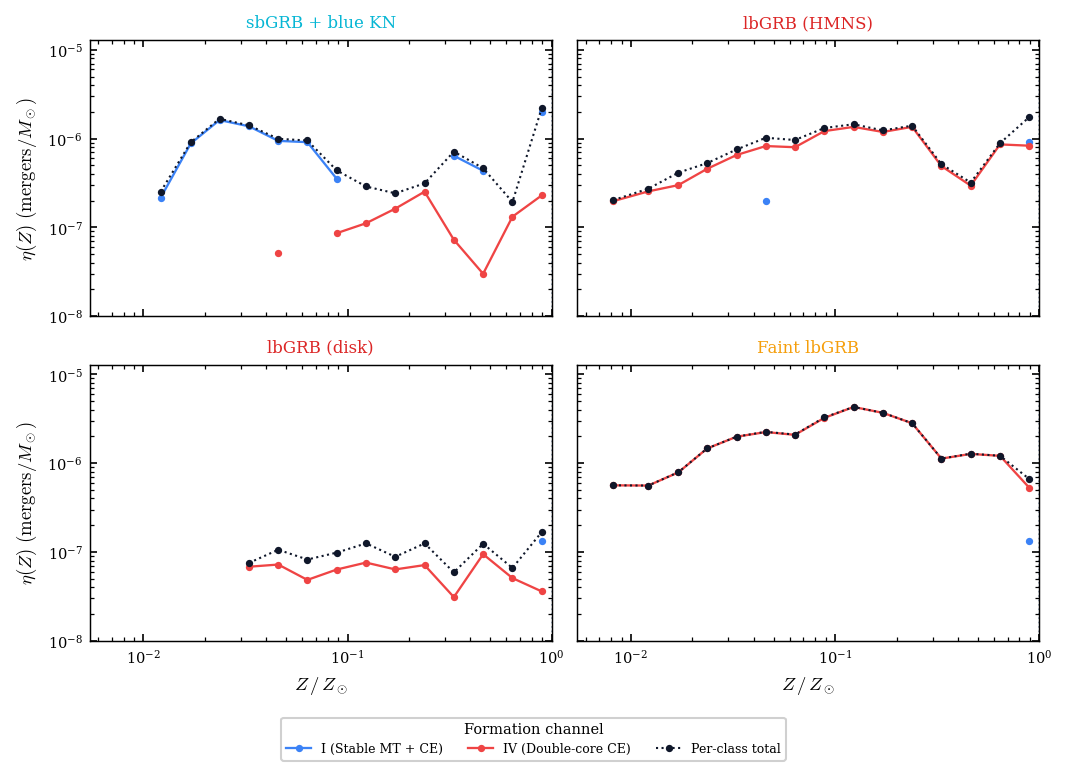

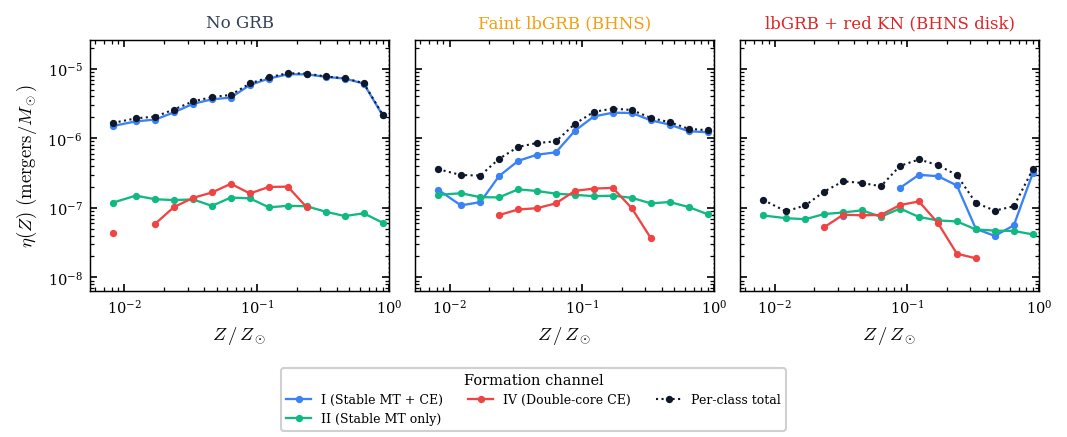

In [12]:
# Formation efficiency eta(Z) per GRB class, split by Broekgaarden channel,
# on the same coarse log-Z bins as Section 5 (reuses _eta_binned, _plot_eta,
# Zc_over_Zsun, CH_COLORS, and the class lists + _channel_legend from Section
# 3b).  eta(Z) is additive over disjoint masks, so the channel curves sum to
# the per-class total bin by bin.

def _draw_eta_channels(ax, Z, w, ch_dict, class_mask, mean_mass, yacc):
    for ch_label, ch_mask in ch_dict.items():
        sub = class_mask & ch_mask
        if w[sub].sum() <= 0:
            continue
        eta, ok = _eta_binned(Z, w, sub, mean_mass)
        if not np.any(ok & (eta > 0)):
            continue
        yacc.append(eta[ok & (eta > 0)])
        _plot_eta(ax, eta, ok, CH_COLORS[ch_label], '-', _pretty_ch(ch_label))
    eta_t, ok_t = _eta_binned(Z, w, class_mask, mean_mass)
    yacc.append(eta_t[ok_t & (eta_t > 0)])
    _plot_eta(ax, eta_t, ok_t, C_TEXT, ':', 'Per-class total', lw=1.0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(1.0, color=C_GUIDE, lw=0.8, ls=':', zorder=0)

_x_lo = Zc_over_Zsun.min() / 1.5
_x_hi = Z_PHYS_MAX / Z_SUN

# BNS: 2x2 over the four Gottlieb classes.
yacc = []
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (cl_label, cl_mask, cl_color) in zip(axes.flat, bns_classes_3b):
    _draw_eta_channels(ax, Z_bns, w_bns, channels, cl_mask, mean_mass_bns, yacc)
    ax.set_title(cl_label, color=cl_color, fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel(r'$Z\,/\,Z_\odot$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\eta(Z)\ (\mathrm{mergers}/M_\odot)$')
_finite = [a for a in yacc if a.size]
if _finite:
    _allv = np.concatenate(_finite)
    axes[0, 0].set_ylim(_allv.min() / 3.0, _allv.max() * 3.0)
axes[0, 0].set_xlim(_x_lo, _x_hi)
handles, labels = _channel_legend(axes.flat)
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=6,
           frameon=True, title='Formation channel', title_fontsize=7)
fig.savefig('plots/metallicity_by_class_per_channel.pdf')
fig.savefig('plots/metallicity_by_class_per_channel.png', dpi=300)
plt.show()

# BHNS: 1x3 over the Gottlieb hybrid BHNS classes.
yacc = []
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (cl_label, cl_mask, cl_color) in zip(axes, bhns_classes_3b):
    _draw_eta_channels(ax, Z_bhns, w_bhns, channels_bhns, cl_mask, mean_mass_bhns, yacc)
    ax.set_title(cl_label, color=cl_color, fontsize=8)
    ax.set_xlabel(r'$Z\,/\,Z_\odot$')
axes[0].set_ylabel(r'$\eta(Z)\ (\mathrm{mergers}/M_\odot)$')
_finite = [a for a in yacc if a.size]
if _finite:
    _allv = np.concatenate(_finite)
    axes[0].set_ylim(_allv.min() / 3.0, _allv.max() * 3.0)
axes[0].set_xlim(_x_lo, _x_hi)
handles, labels = _channel_legend(axes)
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=6,
           frameon=True, title='Formation channel', title_fontsize=7)
fig.savefig('plots/metallicity_bhns_by_class_per_channel.pdf')
fig.savefig('plots/metallicity_bhns_by_class_per_channel.png', dpi=300)
plt.show()

**Figure 5b.** Formation efficiency $\eta(Z)$ (mergers per $M_\odot$ formed) per Gottlieb (2024) GRB class, decomposed by Broekgaarden et al. (2021, 2022) formation channel. Sample: COMPAS Model A (BNS Zenodo 5189849, BHNS Zenodo 5178777), STROOPWAFEL-weighted, per-population $M_\mathrm{evolved}$ calibrated via `calibrate_mean_mass_evolved`. Top figure: four BNS classes; bottom: three BHNS hybrid classes. The native COMPAS metallicity grid is pooled into 15 equal-count log-$Z$ bins, matching Section 5. Bins shown only where raw $N \geq 50$, Kish $n_\mathrm{eff} \geq 10$, and $Z \leq Z_\odot$ ($Z_\odot = 0.0142$); no per-bin error bars are drawn since the $n_\mathrm{eff} \geq 10$ gate bounds the per-bin sampling error. The dotted black curve is the per-class total and equals the channel sum bin by bin. Cosmology Planck 2015, MSSFR Levina et al. (2026) TNG100-1.

## 6. BNS Merger Rate $\mathcal{R}(z)$ per GRB Class

Intrinsic $\mathcal{R}(z)$ (Gpc$^{-3}$ yr$^{-1}$) per Gottlieb (2024) class under the Section 4 cosmic-integration setup. Curves are upper bounds (100 percent jet launching); HMNS solid, disk dashed (shared palette red). Additivity holds at `rtol=1e-12`.

**Detected vs intrinsic (panel below).** The per-class curves folded through `FastCosmicIntegration.find_detection_probability` ($\rho \geq 8$, Finn and Chernoff 1993 antenna pattern) via `grb_rates.detected_rate` give the LIGO O3 detection-rate density, defined to $z_\mathrm{det} = 1$ (FCI default horizon). Pass `sensitivity='design'` for 3G or `'O1'` for early-LIGO.

  sbGRB + blue KN     R(z=0) =       22 Gpc^-3 yr^-1
  lbGRB (HMNS)        R(z=0) =       20 Gpc^-3 yr^-1
  lbGRB (disk)        R(z=0) =        1 Gpc^-3 yr^-1
  Faint lbGRB         R(z=0) =       12 Gpc^-3 yr^-1
  All BNS             R(z=0) =       55 Gpc^-3 yr^-1


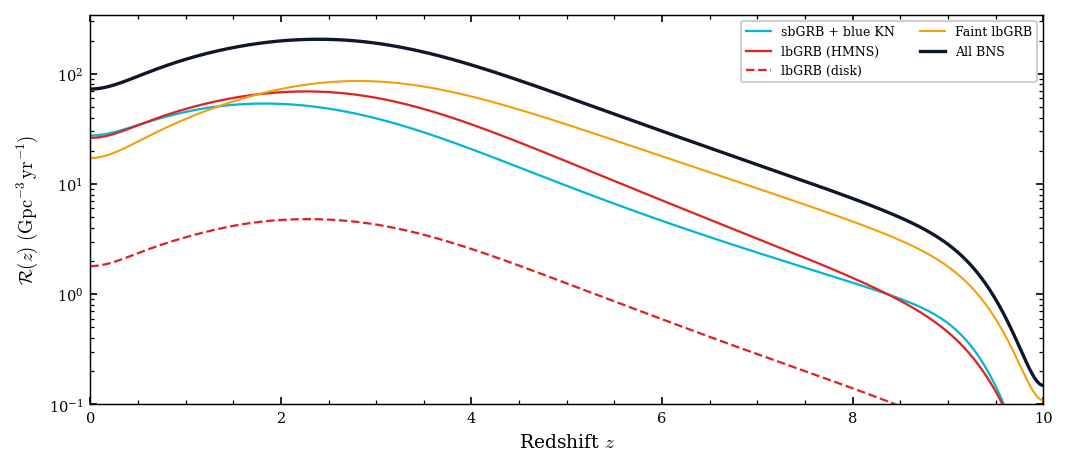

In [13]:
# R(z=0) is quoted from these arrays, so compute them unsmoothed
# (smooth_sigma=0): the sigma=30 display kernel reflects at z = 0 and
# inflates the local rate by ~30 percent on a rising R(z) (see
# grb_rates.compute_merger_rate).  Curves are re-smoothed for display
# only via smooth_rate_curve, so the plotted figures are unchanged.
classes_BNS_24 = [
    ('sbGRB + blue KN', sbGRB_blue),
    ('lbGRB (HMNS)',    lbGRB_hmns),
    ('lbGRB (disk)',    lbGRB_disk),
    ('Faint lbGRB',     bns_faint_lb),
    ('All BNS',         np.ones(len(delay_bns), dtype=bool)),
]

# The four Gottlieb 2024 classes partition the BNS sample, so the All-BNS
# total is exactly their sum (smooth_sigma=0 keeps compute_merger_rate
# additive).  Integrate only the four classes and derive the total by
# summation rather than repeating a second full-sample cosmic integration.
merger_rates_BNS = {}
for label, mask in classes_BNS_24:
    if label == 'All BNS':
        continue
    merger_rates_BNS[label] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, p_draw,
        dPdlogZ, metallicities,
        Z_bns[mask], delay_bns[mask], w_bns[mask], smooth_sigma=0)
merger_rates_BNS['All BNS'] = sum(
    merger_rates_BNS[lbl] for lbl, _ in classes_BNS_24 if lbl != 'All BNS')

iz0 = np.argmin(np.abs(redshifts))
for label in [c[0] for c in classes_BNS_24]:
    print(f"  {label:18s}  R(z=0) = {rate_label(merger_rates_BNS[label][iz0]):>8s} Gpc^-3 yr^-1")

# With the total defined as the class sum, additivity is structural; keep a
# cheap production sanity check that every class curve is finite, non-negative
# and bounded by the total (catches a regression in compute_merger_rate or
# classify_bns_2024 that would otherwise distort the figure silently).
R_all_2024 = merger_rates_BNS['All BNS']
for lbl, _ in classes_BNS_24[:-1]:
    _Rc = merger_rates_BNS[lbl]
    assert np.all(np.isfinite(_Rc)) and np.all(_Rc >= 0), \
        f"BNS class {lbl!r} rate has non-finite or negative entries"
    assert np.all(_Rc <= R_all_2024 + 1e-9), \
        f"BNS class {lbl!r} rate exceeds the All-BNS total"

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
# Linestyle distinguishes lbGRB (HMNS) from lbGRB (disk): both share the
# project-palette red (C_LB_HMNS == C_LB_DISK == '#DC2626'), so
# HMNS is solid and disk is dashed, matching the Section 3 delay-time panel.
style = [('sbGRB + blue KN', C_SB_BLUE,  '-',  1.1),
         ('lbGRB (HMNS)',    C_LB_HMNS,  '-',  1.1),
         ('lbGRB (disk)',    C_LB_DISK,  '--', 1.1),
         ('Faint lbGRB',     C_FAINT,    '-',  1.0),
         ('All BNS',         C_TEXT,     '-',  1.6)]
for lbl, c, ls, lw in style:
    R = smooth_rate_curve(merger_rates_BNS[lbl])  # display only
    ax.plot(redshifts, R, color=c, ls=ls, lw=lw, label=lbl)
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2)
fig.savefig('plots/rate_bns_by_class.png', dpi=300)
fig.savefig('plots/rate_bns_by_class.pdf')
plt.show()


## 6a. Sensitivity to the Star-Formation History

The fiducial rate convolves the COMPAS sample with the Levina et al. (2026, [arXiv:2601.20202](https://arxiv.org/abs/2601.20202)) TNG100-1 MSSFR, currently a preprint. To show the per-class results do not hinge on that choice, the panels below re-integrate each BNS class under the Neijssel et al. (2019) Madau and Dickinson MSSFR, which is the COMPAS `FastCosmicIntegration` default and the same prescription used to back-derive `MEAN_MASS_EVOLVED` from the Broekgaarden+ 2021 $w_{000}$ anchor. The calibrated `mean_mass_bns` is reused unchanged, since the evolved stellar mass is a sampler property independent of the MSSFR; only $S(z)$ and $dP/d\ln Z$ swap to the Neijssel defaults. The absolute local rate is SFH-dependent (the Neijssel pass reproduces the COMPAS local anchor; the Levina TNG100-1 pass gives the headline 55), but the per-class ordering and the abundance-to-rate inversion are not.

  class                Levina R0   Neijssel R0
  sbGRB + blue KN          21.78         15.58
  lbGRB (HMNS)             19.75         13.36
  lbGRB (disk)              1.36          0.53
  Faint lbGRB              12.09          3.92
  All BNS                  54.98         33.39
  ordering identical under both MSSFRs: ['sbGRB + blue KN', 'lbGRB (HMNS)', 'Faint lbGRB', 'lbGRB (disk)']
  faint-class local-rate share: Levina 22.0%, Neijssel 11.8% (47.0% by abundance -> inversion holds under both)


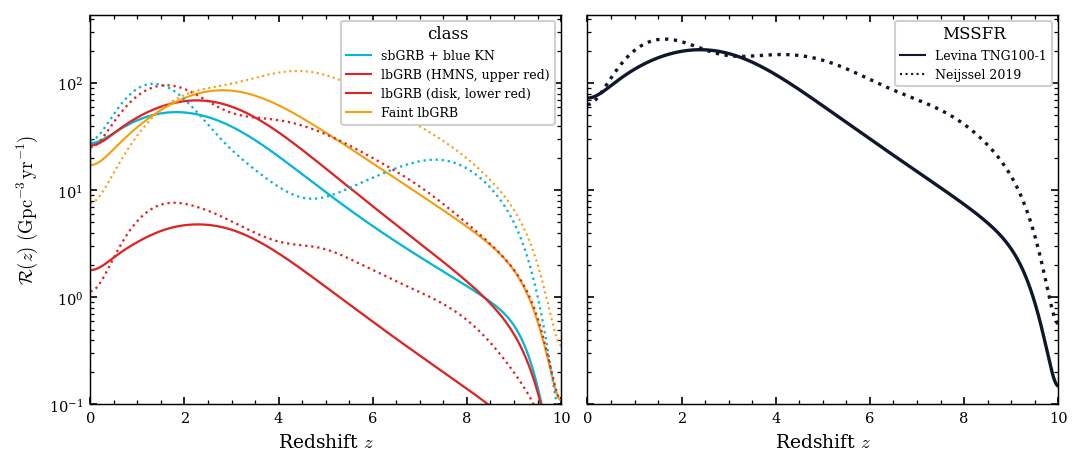

In [14]:
# Neijssel+ 2019 cross-check MSSFR (FCI defaults, the calibration-anchor SFH).
# MEAN_MASS_EVOLVED is a sampler property, so mean_mass_bns is reused; only the
# SFR(z) and dP/dlnZ swap.  Levina per-class rates (merger_rates_BNS) and iz0
# come from Section 6 above.
sfr_nei = find_sfr(redshifts)  # Neijssel+ 2019 Madau and Dickinson fit (FCI default)
dPdlogZ_nei, metallicities_nei, p_draw_nei = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(Z_range_bns[0]),
    max_logZ_COMPAS=np.log(Z_range_bns[1]))  # Neijssel+ 2019 default mu0/sigma/alpha
try:
    check_dPdlogZ_normalization(dPdlogZ_nei, metallicities_nei, rtol=0.10)
except ValueError:
    _dlnZ = np.diff(np.log(metallicities_nei))
    _dlnZ = np.append(_dlnZ, _dlnZ[-1])
    dPdlogZ_nei = dPdlogZ_nei / (dPdlogZ_nei * _dlnZ[None, :]).sum(axis=1)[:, None]
n_formed_BNS_nei = sfr_nei / mean_mass_bns

merger_rates_BNS_nei = {}
for label, mask in classes_BNS_24:
    if label == 'All BNS':
        continue
    merger_rates_BNS_nei[label] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS_nei, p_draw_nei,
        dPdlogZ_nei, metallicities_nei,
        Z_bns[mask], delay_bns[mask], w_bns[mask], smooth_sigma=0)
merger_rates_BNS_nei['All BNS'] = sum(
    merger_rates_BNS_nei[lbl] for lbl, _ in classes_BNS_24 if lbl != 'All BNS')

print(f"  {'class':18s}  {'Levina R0':>10s}  {'Neijssel R0':>12s}")
for label in [c[0] for c in classes_BNS_24]:
    print(f"  {label:18s}  {merger_rates_BNS[label][iz0]:10.2f}  "
          f"{merger_rates_BNS_nei[label][iz0]:12.2f}")

# The relative result (per-class local-rate ordering) must be MSSFR-independent.
def _rank(R):
    return [lbl for _, lbl in sorted(
        ((R[lbl][iz0], lbl) for lbl, _ in classes_BNS_24 if lbl != 'All BNS'),
        reverse=True)]
assert _rank(merger_rates_BNS) == _rank(merger_rates_BNS_nei), \
    "per-class local-rate ordering changed under the Neijssel MSSFR"
_faint_L = merger_rates_BNS['Faint lbGRB'][iz0] / merger_rates_BNS['All BNS'][iz0]
_faint_N = merger_rates_BNS_nei['Faint lbGRB'][iz0] / merger_rates_BNS_nei['All BNS'][iz0]
print(f"  ordering identical under both MSSFRs: {_rank(merger_rates_BNS)}")
print(f"  faint-class local-rate share: Levina {_faint_L:.1%}, Neijssel {_faint_N:.1%} "
      f"(47.0% by abundance -> inversion holds under both)")

# Figure: per-class (left) and All-BNS (right); Levina solid, Neijssel dotted.
# Linestyle encodes the MSSFR; the two red classes separate by amplitude.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.1, 3.0),
                               constrained_layout=True, sharey=True)
_mssfr_curves = [(merger_rates_BNS, '-'), (merger_rates_BNS_nei, ':')]
_class_style = [('sbGRB + blue KN', C_SB_BLUE, 1.1),
                ('lbGRB (HMNS)',    C_LB_HMNS, 1.1),
                ('lbGRB (disk)',    C_LB_DISK, 1.1),
                ('Faint lbGRB',     C_FAINT,   1.0)]
for _R, _ls in _mssfr_curves:
    for _lbl, _c, _lw in _class_style:
        axL.plot(redshifts, smooth_rate_curve(_R[_lbl]), color=_c, ls=_ls, lw=_lw)
    axR.plot(redshifts, smooth_rate_curve(_R['All BNS']), color=C_TEXT, ls=_ls, lw=1.6)
for ax in (axL, axR):
    ax.set_xlim(0, 10)
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.1)
    ax.set_xlabel(r'Redshift $z$')
axL.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
_class_handles = [Line2D([], [], color=C_SB_BLUE, label='sbGRB + blue KN'),
                  Line2D([], [], color=C_LB_HMNS, label='lbGRB (HMNS, upper red)'),
                  Line2D([], [], color=C_LB_DISK, label='lbGRB (disk, lower red)'),
                  Line2D([], [], color=C_FAINT,   label='Faint lbGRB')]
_style_handles = [Line2D([], [], color=C_TEXT, ls='-', label='Levina TNG100-1'),
                  Line2D([], [], color=C_TEXT, ls=':', label='Neijssel 2019')]
axL.legend(handles=_class_handles, fontsize=6, loc='upper right', title='class')
axR.legend(handles=_style_handles, fontsize=6, loc='upper right', title='MSSFR')
fig.savefig('plots/rate_bns_mssfr_crosscheck.png', dpi=300)
fig.savefig('plots/rate_bns_mssfr_crosscheck.pdf')
plt.show()

**Figure 6a.** Star-formation-history sensitivity of the BNS per-class merger rate $\mathcal{R}(z)$ for COMPAS Model A. _Left:_ the four Gottlieb (2024) classes under the Levina et al. (2026) TNG100-1 MSSFR (solid) and the Neijssel et al. (2019) Madau and Dickinson MSSFR (dotted); colour is the class, linestyle is the MSSFR, and the two red classes separate by amplitude (HMNS upper, disk lower). _Right:_ the All-BNS total under both. The absolute local rate is SFH-dependent ($\mathcal{R}(z{=}0) = 55.0$ Levina vs $33.4$ Neijssel, the latter reproducing the COMPAS $w_{000}$ anchor), but the per-class local-rate ordering (sbGRB > HMNS > faint > disk) is identical under both, and the abundance-to-rate inversion of the faint class persists (47.0% by abundance, 22.0% Levina / 11.8% Neijssel of the local rate). The relative, per-class results are therefore robust to the choice of star-formation history; only the overall normalisation moves. STROOPWAFEL-weighted; cosmology Planck 2015; rates are intrinsic upper bounds.

## 6b. BNS Merger Rate $\mathcal{R}(z)$ per GRB Class, Split by Formation Channel

The Cartesian product of the Broekgaarden I-V formation-channel split (built in Section 0) and the Section 6 class split (Gottlieb 2024 four-class). Each panel is one GRB class with the I-V decomposition overlaid; the dotted black curve is the per-class total from Section 6. All curves are intrinsic upper bounds (100 percent jet launching). The (channel x class) decomposition collapses to the Section 6 per-class total when summed across channels, and to the per-channel total when summed across classes; both tripwires fire at `rtol=1e-12`.

Class               Channel                 R(z=0) [Gpc^-3 yr^-1]
  sbGRB + blue KN   I (Stable MT + CE)            17
  sbGRB + blue KN   II (Stable MT only)         0.00
  sbGRB + blue KN   III (Single-core CE)        0.00
  sbGRB + blue KN   IV (Double-core CE)            5
  sbGRB + blue KN   V (Other)                   0.00
  lbGRB (HMNS)      I (Stable MT + CE)             4
  lbGRB (HMNS)      II (Stable MT only)         0.00
  lbGRB (HMNS)      III (Single-core CE)        0.00
  lbGRB (HMNS)      IV (Double-core CE)           16
  lbGRB (HMNS)      V (Other)                   0.00
  lbGRB (disk)      I (Stable MT + CE)          0.87
  lbGRB (disk)      II (Stable MT only)         0.00
  lbGRB (disk)      III (Single-core CE)        0.00
  lbGRB (disk)      IV (Double-core CE)         0.49
  lbGRB (disk)      V (Other)                   0.00
  Faint lbGRB       I (Stable MT + CE)          0.53
  Faint lbGRB       II (Stable MT only)         0.00
  Faint lbGRB       III (Single-c

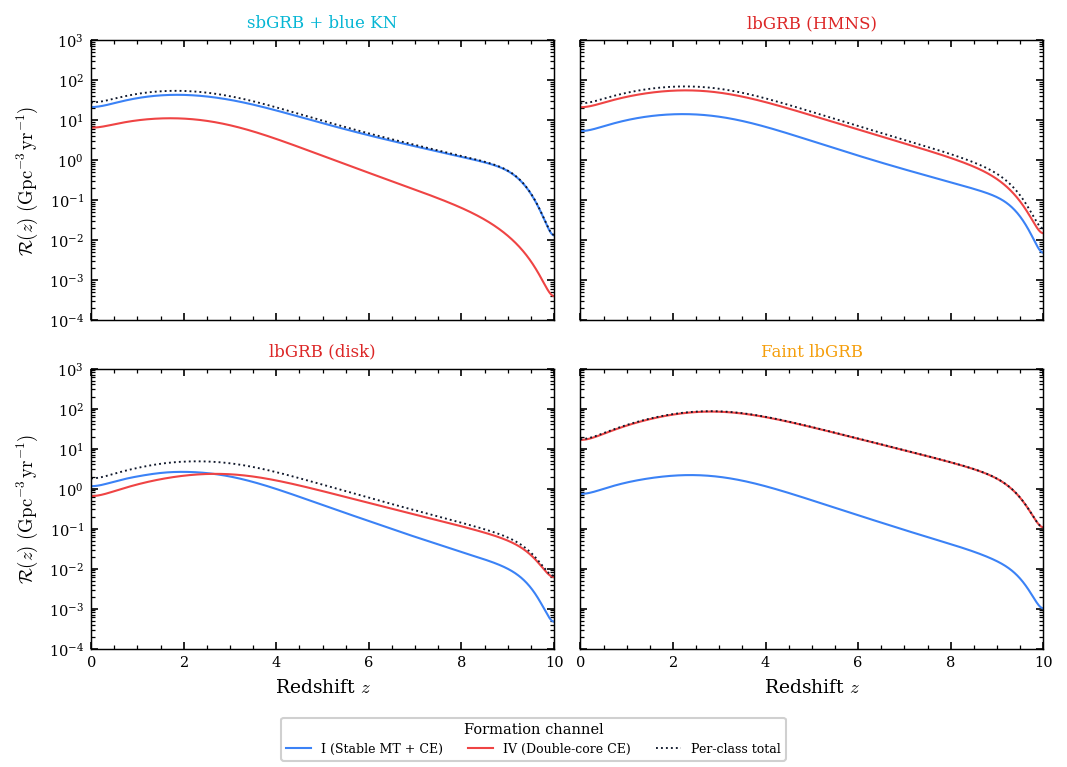

In [15]:
# Cartesian product of the formation-channel split (`channels`, Section 0) and the
# Section 6 class split (`classes_BNS_24`).  Reuses the pre-computed per-class
# `merger_rates_BNS` and computes the per-channel `merger_rates_ch` totals here
# for the additivity tripwires; compute_merger_rate fires on the five channel
# totals plus the 4 x 5 = 20 (class, channel) intersections.
CH_KEYS_BNS_6b = list(channels.keys())
CL_KEYS_BNS_6b = [lbl for lbl, _ in classes_BNS_24 if lbl != 'All BNS']

# Per-channel BNS totals are derived below as the class sum of the
# (class, channel) grid (the four classes partition each channel), so we do
# not integrate the five channel totals separately here.
R_bns_class_channel = {}
for cl_label, cl_mask in classes_BNS_24:
    if cl_label == 'All BNS':
        continue
    per_ch = {}
    for ch_label, ch_mask in channels.items():
        m = cl_mask & ch_mask
        if not m.any():
            # Empty (class, channel) cell: short-circuit to avoid calling
            # compute_merger_rate on a zero-length sample (matches the
            # Section 11.1 idiom).
            per_ch[ch_label] = np.zeros_like(redshifts)
            continue
        per_ch[ch_label] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BNS, p_draw,
            dPdlogZ, metallicities,
            Z_bns[m], delay_bns[m], w_bns[m], smooth_sigma=0)
    R_bns_class_channel[cl_label] = per_ch

# Per-channel BNS totals: the four classes partition each channel, so the
# channel total is their sum (smooth_sigma=0 keeps compute_merger_rate
# additive).  Deriving it here avoids five extra full-channel integrations.
merger_rates_ch = {
    ch_label: sum(R_bns_class_channel[cl][ch_label] for cl in CL_KEYS_BNS_6b)
    for ch_label in CH_KEYS_BNS_6b
}

# Tripwire A: sum over channels in each class matches the Section 6 per-class
# total (independently integrated there), so this still validates that the
# channels partition each class and the integrations are mutually consistent.
for cl_label in CL_KEYS_BNS_6b:
    R_sum = sum(R_bns_class_channel[cl_label].values())
    assert np.allclose(R_sum, merger_rates_BNS[cl_label],
                       rtol=1e-12, atol=0), \
        f"channel sum != Section 6 per-class total for {cl_label!r}"

# Per-channel totals are now the class sum by construction; keep a cheap
# finiteness / non-negativity sanity check in place of the former tripwire.
for ch_label in CH_KEYS_BNS_6b:
    assert np.all(np.isfinite(merger_rates_ch[ch_label])) and \
        np.all(merger_rates_ch[ch_label] >= 0), \
        f"per-channel BNS total for {ch_label!r} is non-finite or negative"

# Channel palette inherited from the project-wide CH_COLORS (Section setup,
# grb_plot_style.CHANNEL_PALETTE) so a colour means the same Broekgaarden
# channel across every per-channel split in the notebook.
ch_colors_6b = CH_COLORS
# Class colour goes on the panel title (encoding stays on the frame, not
# the lines, so a class colour and a channel colour cannot collide).
cl_colors_6b = {
    'sbGRB + blue KN': C_SB_BLUE,
    'lbGRB (HMNS)':    C_LB_HMNS,
    'lbGRB (disk)':    C_LB_DISK,
    'Faint lbGRB':     C_FAINT,
}

def _pretty_ch_6b(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

iz0 = int(np.argmin(np.abs(redshifts)))
print(f"{'Class':18s}  {'Channel':22s}  R(z=0) [Gpc^-3 yr^-1]")
for cl_label in CL_KEYS_BNS_6b:
    for ch_label in CH_KEYS_BNS_6b:
        print(f"  {cl_label:16s}  {_pretty_ch_6b(ch_label):22s}  "
              f"{rate_label(R_bns_class_channel[cl_label][ch_label][iz0]):>8s}")

# Drop channels that are flat zero across every class so the legend does
# not advertise curves that are not on the figure.
CH_PLOT_BNS_6b = [
    ch for ch in CH_KEYS_BNS_6b
    if any(R_bns_class_channel[cl][ch].max() > 0 for cl in CL_KEYS_BNS_6b)
]

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0),
                         sharex=True, sharey=True, constrained_layout=True)
for ax, cl_label in zip(axes.flat, CL_KEYS_BNS_6b):
    for ch_label in CH_PLOT_BNS_6b:
        ax.plot(redshifts, smooth_rate_curve(R_bns_class_channel[cl_label][ch_label]),
                color=ch_colors_6b[ch_label], lw=1.0,
                label=_pretty_ch_6b(ch_label))
    ax.plot(redshifts, smooth_rate_curve(merger_rates_BNS[cl_label]),
            color=C_TEXT, lw=0.9, ls=':', label='Per-class total')
    ax.set_title(cl_label, color=cl_colors_6b[cl_label], fontsize=8)
    ax.set_xlim(0, 10)
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 1e3)

for ax in axes[-1, :]:
    ax.set_xlabel(r'Redshift $z$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center',
           ncol=3, fontsize=6, frameon=True,
           title='Formation channel', title_fontsize=7)

fig.savefig('plots/rate_bns_by_class_per_channel.pdf')
fig.savefig('plots/rate_bns_by_class_per_channel.png', dpi=300)
plt.show()


## 7. BHNS Merger Rate $\mathcal{R}(z)$ with BH Spin Sensitivity

BHNS $\mathcal{R}(z)$ is dominated by $a_\mathrm{BH}$: higher spins move the ISCO inward and lift the surviving NS fraction (Foucart 2018).

- Class colour: red lbGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$); orange Faint lbGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$).
- Spin grid: $a_\mathrm{BH} \in \{0, 0.3, 0.5, 0.7, 0.9\}$ (`clip_chi=0.9` respects the Foucart calibration); fiducial $A_\mathrm{BH,fid} = 0.5$.
- Per-class curves carry the misalignment factor 0.5 (Fragos et al. 2010; Kawaguchi et al. 2015). The black All-BHNS trace is intrinsic: misalignment is a jet-orientation cut and does not apply to the $\sim 67\%$ that swallow the NS.
- Gap between black and coloured envelopes = sub-threshold disks ($M_\mathrm{disk} < 0.01\,M_\odot$) plus GRB-class systems lost to misalignment. The BH-spin envelope is the dominant systematic.

/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 959368 systems with Q > 7 (max Q=29.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


  a=0.0  Long:   0.00  Short:      1 Gpc^-3 yr^-1
  a=0.3  Long:   0.02  Short:      6 Gpc^-3 yr^-1
  a=0.5  Long:      2  Short:     10 Gpc^-3 yr^-1
  a=0.7  Long:      8  Short:     16 Gpc^-3 yr^-1
  a=0.9  Long:     30  Short:      8 Gpc^-3 yr^-1


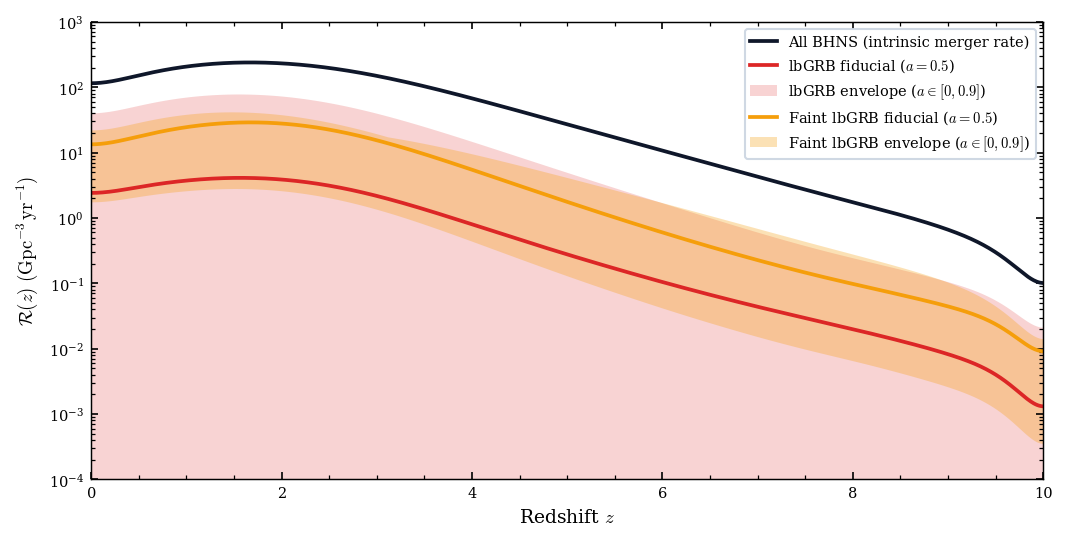

In [16]:
# R(z=0) is quoted from these arrays, so compute them unsmoothed
# (smooth_sigma=0): the sigma=30 display kernel reflects at z = 0 and
# inflates the local rate by ~30 percent on a rising R(z) (see
# grb_rates.compute_merger_rate).  Curves are re-smoothed for display
# only via smooth_rate_curve, so the plotted figures are unchanged.
spin_grid = [0.0, 0.3, 0.5, 0.7, 0.9]
spin_rates_long, spin_rates_short = {}, {}
# Misalignment is applied at the source (commutes with marginalize_bh_spin
# because the factor is a scalar 0.5), so r_long_fm19 / r_short_fm19 below
# inherit the correction and the GRB-class beaming comparison stays
# consistent.  The All-BHNS reference computed further down is the
# *intrinsic* merger rate (no misalignment): MISALIGNMENT_SYSTEMATIC_FACTOR
# is a jet-orientation reduction (see grb_physics.py docstring), and the
# ~67 percent of BHNS systems that swallow the NS launch no jet, so the
# 0.5x correction does not apply to them.
for a in spin_grid:
    cbh = classify_bhns(BH, NS_bh, a_BH=a, clip_chi=0.9)
    _long_mask  = cbh['lbGRB + red KN (BHNS disk)']
    _short_mask = cbh['Faint lbGRB (BHNS)']
    spin_rates_long[a]  = apply_bhns_misalignment(compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        dPdlogZ, metallicities,
        Z_bhns[_long_mask],  delay_bhns[_long_mask],
        w_bhns[_long_mask], smooth_sigma=0))
    spin_rates_short[a] = apply_bhns_misalignment(compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        dPdlogZ, metallicities,
        Z_bhns[_short_mask], delay_bhns[_short_mask],
        w_bhns[_short_mask], smooth_sigma=0))

iz0 = np.argmin(np.abs(redshifts))
for a in spin_grid:
    print(f"  a={a:.1f}  Long: {rate_label(spin_rates_long[a][iz0]):>6s}  "
          f"Short: {rate_label(spin_rates_short[a][iz0]):>6s} Gpc^-3 yr^-1")

# BH-spin marginalization. Flat prior is
# uniform over the spin grid; Fuller and Ma (2019, arXiv:1905.08793) predict
# efficient angular-momentum transport, so most BHs form with low spin.
w_flat = {0.0: 0.20, 0.3: 0.20, 0.5: 0.20, 0.7: 0.20, 0.9: 0.20}
w_fm19 = {0.0: 0.70, 0.3: 0.20, 0.5: 0.07, 0.7: 0.02, 0.9: 0.01}
r_long_flat  = marginalize_bh_spin(spin_rates_long,  w_flat)
r_long_fm19  = marginalize_bh_spin(spin_rates_long,  w_fm19)
r_short_flat = marginalize_bh_spin(spin_rates_short, w_flat)
r_short_fm19 = marginalize_bh_spin(spin_rates_short, w_fm19)

rate_bhns_all = compute_merger_rate(
    redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
    dPdlogZ, metallicities,
    Z_bhns, delay_bhns, w_bhns, smooth_sigma=0)

# Per-class shaded BH-spin envelope (CLAUDE.md "Scientific Plotting
# Standards" prescribes shaded bands for spin / EOS sweeps).  The band is
# min-to-max over the spin grid a in [0, 0.9]; the solid centre line is
# the fiducial A_BH_FID = 0.5.  The lbGRB lower edge collapses near zero
# at a=0 (Schwarzschild ISCO at 6GM/c^2; Bardeen, Press, Teukolsky 1972,
# ApJ 178, 347) because almost no NS material survives above
# MDISK_LONG = 0.1 Msun (Foucart 2018, Kruger and Foucart 2020), so the
# lower bound is floored at Y_FLOOR to keep the log axis bounded.  The
# All-BHNS reference is the *intrinsic* merger rate; the per-class bands
# include the 0.5x population-averaged jet-misalignment suppression, so
# the gap between black and the coloured bands is sub-threshold-disk
# mergers + would-be jet GRBs lost to misalignment.
Y_FLOOR = 1e-4
long_stack  = np.stack([smooth_rate_curve(spin_rates_long[a])  for a in spin_grid])  # display only
short_stack = np.stack([smooth_rate_curve(spin_rates_short[a]) for a in spin_grid])  # display only
long_lo,  long_hi  = long_stack.min(axis=0),  long_stack.max(axis=0)
short_lo, short_hi = short_stack.min(axis=0), short_stack.max(axis=0)

fig, ax = plt.subplots(figsize=(7.0, 3.5), constrained_layout=True)

ax.fill_between(redshifts, np.maximum(long_lo, Y_FLOOR), long_hi,
                color=C_LB_DISK, alpha=0.20, lw=0,
                label=r'lbGRB envelope ($a \in [0, 0.9]$)')
ax.plot(redshifts, smooth_rate_curve(spin_rates_long[0.5]),  color=C_LB_DISK, lw=1.8,
        label=r'lbGRB fiducial ($a=0.5$)')
ax.fill_between(redshifts, np.maximum(short_lo, Y_FLOOR), short_hi,
                color=C_FAINT,   alpha=0.30, lw=0,
                label=r'Faint lbGRB envelope ($a \in [0, 0.9]$)')
ax.plot(redshifts, smooth_rate_curve(spin_rates_short[0.5]), color=C_FAINT,   lw=1.8,
        label=r'Faint lbGRB fiducial ($a=0.5$)')
ax.plot(redshifts, smooth_rate_curve(rate_bhns_all), color=C_TEXT, lw=1.8,
        label='All BHNS (intrinsic merger rate)')

ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(Y_FLOOR, 1e3)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')

# All BHNS first (reference total), then per class with fiducial above its
# envelope so the eye reads top-to-bottom: reference, then lbGRB, then Faint
# lbGRB.  ncol=1 is intentional; ncol=2 pairs adjacent entries visually and
# would put All BHNS next to a Faint lbGRB row.
handles, labels = ax.get_legend_handles_labels()
order = [4, 1, 0, 3, 2]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          fontsize=7, loc='upper right', ncol=1, frameon=True,
          framealpha=0.92, edgecolor=C_BOX_EDGE,
          handlelength=1.8).set_zorder(10)

fig.savefig('plots/rate_bhns_spin_sensitivity.png', dpi=300)
fig.savefig('plots/rate_bhns_spin_sensitivity.pdf')
plt.show()


## 7b. BHNS Merger Rate $\mathcal{R}(z)$ per GRB Class, Split by Formation Channel

The BHNS analogue of Section 6b: three panels, one per Gottlieb hybrid BHNS class (`No GRB`, `Faint lbGRB (BHNS)`, `lbGRB + red KN (BHNS disk)`) at fiducial spin $a_\mathrm{BH,fid} = 0.5$, each decomposed onto the Broekgaarden I-V channels. Per-(class, channel) curves carry the `MISALIGNMENT_SYSTEMATIC_FACTOR = 0.5` multiplier (Fragos et al. 2010; Kawaguchi et al. 2015); the dotted black per-class total is similarly corrected so the panels read on one scale. The class colour goes on the panel title, the channel colour on the lines (as in Sections 6b and 7). Both additivity tripwires (channel sum = corrected per-class total; class sum per channel = per-channel total) fire at `rtol=1e-12`. Channels III, IV, V are essentially zero for BHNS.

Class                     Channel                 R(z=0) [Gpc^-3 yr^-1, mis-corr]
  No GRB                  I (Stable MT + CE)            30
  No GRB                  II (Stable MT only)         0.50
  No GRB                  III (Single-core CE)        0.00
  No GRB                  IV (Double-core CE)         0.14
  No GRB                  V (Other)                   0.00
  Faint lbGRB (BHNS)      I (Stable MT + CE)             9
  Faint lbGRB (BHNS)      II (Stable MT only)         0.95
  Faint lbGRB (BHNS)      III (Single-core CE)        0.00
  Faint lbGRB (BHNS)      IV (Double-core CE)         0.16
  Faint lbGRB (BHNS)      V (Other)                   0.00
  lbGRB + red KN (BHNS disk)  I (Stable MT + CE)             1
  lbGRB + red KN (BHNS disk)  II (Stable MT only)         0.54
  lbGRB + red KN (BHNS disk)  III (Single-core CE)        0.00
  lbGRB + red KN (BHNS disk)  IV (Double-core CE)         0.07
  lbGRB + red KN (BHNS disk)  V (Other)                   0.00


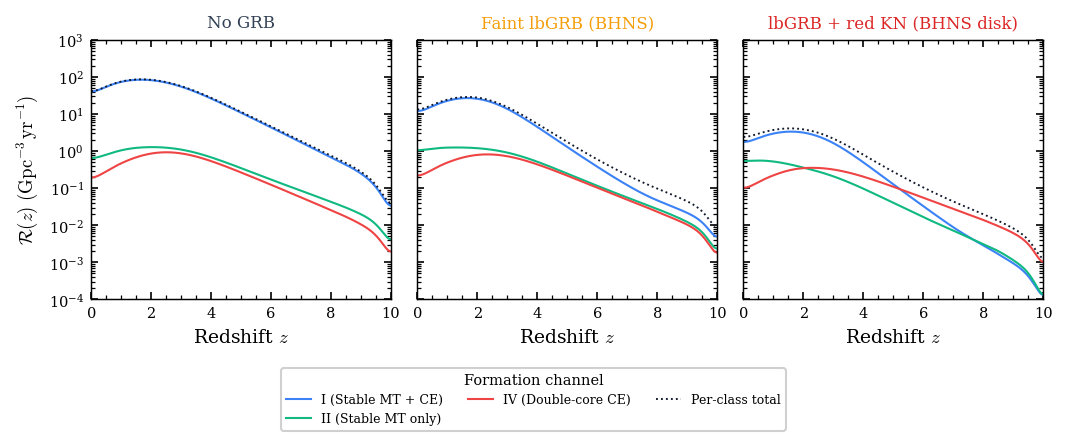

In [17]:
# Cartesian product of the formation-channel split (`channels_bhns`, Section 0) and
# the BHNS class split from Section 2 (`bhns_no_grb`, `bhns_faint_lb`,
# `bhns_long` at A_BH_FID = 0.5).  Computes the per-class and per-channel BHNS
# totals here (both misalignment-corrected) for the two additivity tripwires.
CH_KEYS_BHNS_7b = list(channels_bhns.keys())
CL_BHNS_7b = [
    ('No GRB',                    bhns_no_grb,   C_NO_GRB),
    ('Faint lbGRB (BHNS)',        bhns_faint_lb, C_FAINT_BH),
    ('lbGRB + red KN (BHNS disk)', bhns_long,    C_LONG_BH),
]
CL_KEYS_BHNS_7b = [lbl for lbl, _, _ in CL_BHNS_7b]

# Per (class, channel) rate.  This is the only place BHNS cosmic integration
# fires in 7b: the per-class intrinsic totals and the per-channel totals are
# both derived from this grid by summation (the three classes partition each
# channel and the five channels partition each class), which avoids 3 + 5
# extra full-sample integrations.  We keep the intrinsic per-cell rate
# (`_R_bhns_cc_raw`) for the per-class totals and the misalignment-corrected
# rate (`R_bhns_class_channel`) for the panels; scalar misalignment commutes
# with both splits.
R_bhns_class_channel = {}
_R_bhns_cc_raw = {}
for cl_label, cl_mask, _ in CL_BHNS_7b:
    per_ch = {}
    per_ch_raw = {}
    for ch_label, ch_mask in channels_bhns.items():
        m = cl_mask & ch_mask
        if not m.any():
            per_ch[ch_label] = np.zeros_like(redshifts)
            per_ch_raw[ch_label] = np.zeros_like(redshifts)
            continue
        R_raw = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
            dPdlogZ, metallicities,
            Z_bhns[m], delay_bhns[m], w_bhns[m], smooth_sigma=0)
        per_ch_raw[ch_label] = R_raw
        per_ch[ch_label] = apply_bhns_misalignment(R_raw)
    R_bhns_class_channel[cl_label] = per_ch
    _R_bhns_cc_raw[cl_label] = per_ch_raw

# Per-class intrinsic totals (channels partition each class) and per-channel
# misalignment-corrected totals (classes partition each channel), derived from
# the grid above.
R_bhns_class_intrinsic = {
    cl_label: sum(_R_bhns_cc_raw[cl_label].values())
    for cl_label in CL_KEYS_BHNS_7b
}
merger_rates_ch_bhns = {
    ch_label: sum(R_bhns_class_channel[cl][ch_label] for cl in CL_KEYS_BHNS_7b)
    for ch_label in CH_KEYS_BHNS_7b
}

# Totals are now structural sums of the (class, channel) grid; keep a cheap
# finiteness / non-negativity sanity check in place of the former tripwires.
for cl_label in CL_KEYS_BHNS_7b:
    assert np.all(np.isfinite(R_bhns_class_intrinsic[cl_label])) and \
        np.all(R_bhns_class_intrinsic[cl_label] >= 0), \
        f"BHNS per-class intrinsic total for {cl_label!r} is non-finite or negative"
for ch_label in CH_KEYS_BHNS_7b:
    assert np.all(np.isfinite(merger_rates_ch_bhns[ch_label])) and \
        np.all(merger_rates_ch_bhns[ch_label] >= 0), \
        f"BHNS per-channel total for {ch_label!r} is non-finite or negative"

# Channel palette inherited from the project-wide CH_COLORS (Section setup,
# grb_plot_style.CHANNEL_PALETTE).
ch_colors_7b = CH_COLORS

def _pretty_ch_7b(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

iz0 = int(np.argmin(np.abs(redshifts)))
print(f"{'Class':24s}  {'Channel':22s}  R(z=0) [Gpc^-3 yr^-1, mis-corr]")
for cl_label, _, _ in CL_BHNS_7b:
    for ch_label in CH_KEYS_BHNS_7b:
        print(f"  {cl_label:22s}  {_pretty_ch_7b(ch_label):22s}  "
              f"{rate_label(R_bhns_class_channel[cl_label][ch_label][iz0]):>8s}")

# Drop channels that are flat zero across every class so the legend does
# not advertise curves that are not on the figure.
CH_PLOT_BHNS_7b = [
    ch for ch in CH_KEYS_BHNS_7b
    if any(R_bhns_class_channel[cl][ch].max() > 0 for cl in CL_KEYS_BHNS_7b)
]

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8),
                         sharex=True, sharey=True, constrained_layout=True)
for ax, (cl_label, _, cl_color) in zip(axes, CL_BHNS_7b):
    for ch_label in CH_PLOT_BHNS_7b:
        ax.plot(redshifts, smooth_rate_curve(R_bhns_class_channel[cl_label][ch_label]),
                color=ch_colors_7b[ch_label], lw=1.0,
                label=_pretty_ch_7b(ch_label))
    ax.plot(redshifts,
            smooth_rate_curve(apply_bhns_misalignment(R_bhns_class_intrinsic[cl_label])),
            color=C_TEXT, lw=0.9, ls=':', label='Per-class total')
    ax.set_title(cl_label, color=cl_color, fontsize=8)
    ax.set_xlim(0, 10)
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 1e3)
    ax.set_xlabel(r'Redshift $z$')
axes[0].set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center',
           ncol=3, fontsize=6, frameon=True,
           title='Formation channel',
           title_fontsize=7)

fig.savefig('plots/rate_bhns_by_class_per_channel.pdf')
fig.savefig('plots/rate_bhns_by_class_per_channel.png', dpi=300)
plt.show()


## 8. Physical Host-Galaxy Offset Distributions

Orbit-integrated projected offsets in a Hernquist (1990) potential, replacing the unbound ballistic upper bound (Bloom et al. 1999; Fong and Berger 2013). Each binary's birth radius is drawn from the Hernquist stellar profile; kicks are isotropic. Hosts are a 75/25 mix of star-forming and elliptical (Fong and Berger 2013); the F&B sample is afterglow + host selected, so model CDFs extend to larger offsets than the observed sample.

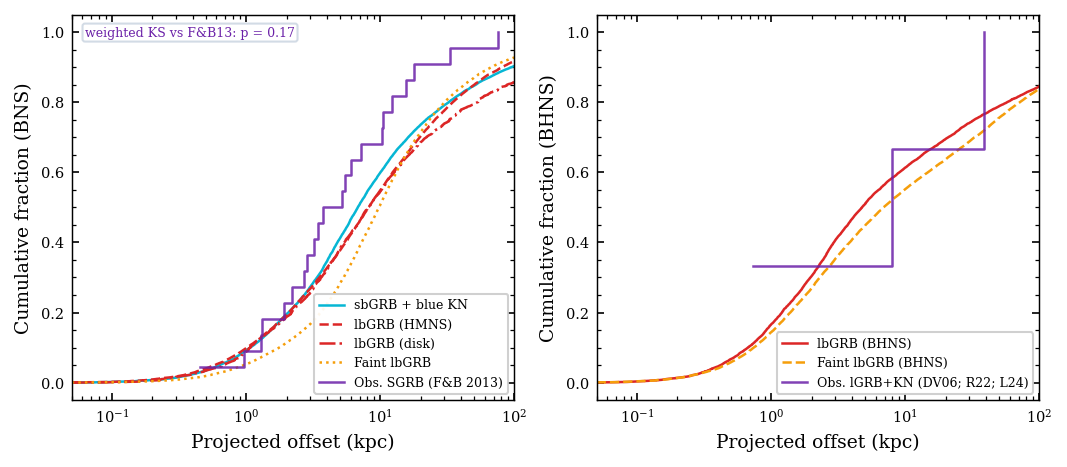

In [18]:
from grb_offsets import (compute_offsets_mixed_hosts,
                         weighted_offset_cdf,
                         weighted_ks_2samp,
                         OBSERVED_SGRB_OFFSETS_KPC,
                         OBSERVED_LGRB_KN_OFFSETS_KPC)

bns_classes_off = [
    ('sbGRB + blue KN', sbGRB_blue,   C_SB_BLUE, '-'),
    ('lbGRB (HMNS)',    lbGRB_hmns,   C_LB_HMNS, '--'),
    ('lbGRB (disk)',    lbGRB_disk,   C_LB_DISK, '-.'),
    ('Faint lbGRB',     bns_faint_lb, C_FAINT,   ':'),
]
bhns_classes_off = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH,  '-'),
    ('Faint lbGRB (BHNS)', bhns_faint_lb, C_FAINT_BH, '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

ax1 = axes[0]
bns_offset_results = {}
ks_results_bns = {}
for lbl, mask, c, ls in bns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bns[mask], delay_bns[mask], weights=w_bns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    bns_offset_results[lbl] = (res['mixed_offsets'], res['mixed_weights'])
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax1.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
    # Weighted two-sample KS against the observed sGRB offsets: the model
    # offsets carry STROOPWAFEL weights, so an unweighted KS would compare
    # the wrong empirical CDF (grb_offsets.weighted_ks_2samp).
    _ksD, _ksp = weighted_ks_2samp(
        res['mixed_offsets'], OBSERVED_SGRB_OFFSETS_KPC,
        weights1=res['mixed_weights'])
    if np.isfinite(_ksp):
        ks_results_bns[lbl] = (_ksD, _ksp)

obs_sorted = np.sort(OBSERVED_SGRB_OFFSETS_KPC)
obs_cdf    = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
ax1.step(obs_sorted, obs_cdf, color=C_OBS, lw=1.2, ls='-', alpha=0.85,
         where='post', label='Obs. SGRB (F&B 2013)')
if 'lbGRB (HMNS)' in ks_results_bns:
    _ksD, _ksp = ks_results_bns['lbGRB (HMNS)']
    # Upper-left white space (the CDF is ~0 there); the legend sits lower-right.
    ax1.text(0.03, 0.97, f'weighted KS vs F&B13: p = {_ksp:.2g}',
             transform=ax1.transAxes, fontsize=6, ha='left', va='top',
             color=C_OBS,
             bbox=dict(boxstyle='round,pad=0.2', fc='white',
                       ec=C_BOX_EDGE, alpha=0.85))
ax1.set_xscale('log')
ax1.set_xlim(0.05, 100)
ax1.set_xlabel(r'Projected offset (kpc)')
ax1.set_ylabel(r'Cumulative fraction (BNS)')
ax1.legend(fontsize=6, loc='lower right')

ax2 = axes[1]
for lbl, mask, c, ls in bhns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bhns[mask], delay_bhns[mask], weights=w_bhns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax2.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
if len(OBSERVED_LGRB_KN_OFFSETS_KPC) > 0:
    obs_l_sorted = np.sort(OBSERVED_LGRB_KN_OFFSETS_KPC)
    obs_l_cdf    = np.arange(1, len(obs_l_sorted) + 1) / len(obs_l_sorted)
    ax2.step(obs_l_sorted, obs_l_cdf, color=C_OBS, lw=1.2, ls='-',
             alpha=0.85, where='post', label='Obs. lGRB+KN (DV06; R22; L24)')
ax2.set_xscale('log')
ax2.set_xlim(0.05, 100)
ax2.set_xlabel(r'Projected offset (kpc)')
ax2.set_ylabel(r'Cumulative fraction (BHNS)')
ax2.legend(fontsize=6, loc='lower right')

fig.savefig('plots/projected_offsets.png', dpi=300)
fig.savefig('plots/projected_offsets.pdf')
plt.show()


### 8b. Host-galaxy offsets across supernova-kick variations

The projected offset is set by the systemic velocity from the second supernova, so the natal-kick prescription is a natural systematic. This compares the fiducial Hobbs et al. (2005) Maxwellian kick (Model A) against the reduced core-collapse dispersions $\sigma = 100$ km/s (Model M) and $\sigma = 30$ km/s (Model N), plus the no-BH-natal-kick run (Model O) for BHNS (Broekgaarden et al. 2021 Sec. 3). The offset CDFs are remarkably insensitive to the kick: lowering the dispersion does not simply translate the distribution inward, because the same change reshapes which binaries stay bound and merge (wider survivors carry a larger Blaauw mass-loss recoil relative to their orbital velocity), so the surviving systemic-velocity distribution shifts only weakly and non-monotonically. The offset is therefore a poor discriminant of the kick model but a good tracer of the host potential and delay-time distribution. Setup as in Section 8 (Hernquist 1990 potential, 75/25 star-forming/elliptical hosts; Fong and Berger 2013). Observed samples: short-GRB offsets (Fong and Berger 2013) and the long-GRB plus kilonova hosts (de Ugarte Postigo et al. 2006; Rastinejad et al. 2022; Levan et al. 2024).

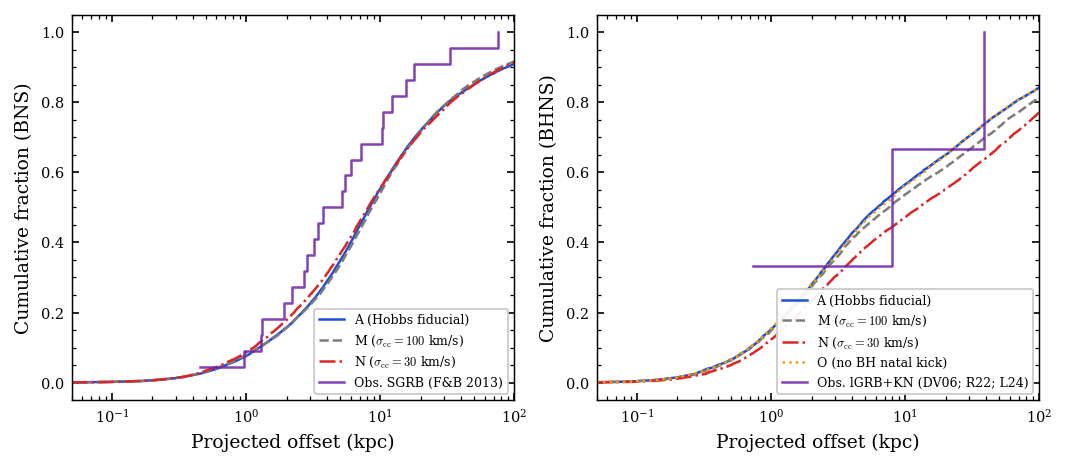

In [19]:
import os

import numpy as np
import matplotlib.pyplot as plt

from grb_io import load_bns_with_kicks, load_bhns_with_kicks
from grb_offsets import (compute_offsets_mixed_hosts, weighted_offset_cdf,
                         OBSERVED_SGRB_OFFSETS_KPC, OBSERVED_LGRB_KN_OFFSETS_KPC)
from grb_plot_style import apply_apj_rcparams

apply_apj_rcparams()

# Kick variations: fiducial Hobbs (A), reduced ccSN dispersions (M, N), and
# no BH natal kick (O, BHNS only).  Colours are distinct project palette
# entries; offsets need only v_sys, delay_time, and weights (no remap).
KICK_MODELS_BNS = [
    ('A', 'A (Hobbs fiducial)', '#1D4ED8', '-'),
    ('M', r'M ($\sigma_\mathrm{cc}=100$ km/s)', '#7d7c78', '--'),
    ('N', r'N ($\sigma_\mathrm{cc}=30$ km/s)', '#DC2626', '-.'),
]
KICK_MODELS_BHNS = KICK_MODELS_BNS + [('O', 'O (no BH natal kick)', '#F59E0B', ':')]
C_OBS_9B = '#6B21A8'

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

for letter, lbl, c, ls in KICK_MODELS_BNS:
    bns = load_bns_with_kicks(
        path=os.path.join('Data', f'COMPASCompactOutput_BNS_{letter}.h5'),
        expected_model=letter)
    res = compute_offsets_mixed_hosts(
        bns['v_sys'], bns['delay_time'], weights=bns['weights'],
        max_systems=20000)
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    axes[0].plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
    del bns, res
_obs = np.sort(OBSERVED_SGRB_OFFSETS_KPC)
_obs_cdf = np.arange(1, len(_obs) + 1) / len(_obs)
axes[0].step(_obs, _obs_cdf, color=C_OBS_9B, lw=1.2, where='post', alpha=0.85,
             label='Obs. SGRB (F&B 2013)')
axes[0].set_xscale('log')
axes[0].set_xlim(0.05, 100)
axes[0].set_xlabel(r'Projected offset (kpc)')
axes[0].set_ylabel(r'Cumulative fraction (BNS)')
axes[0].legend(fontsize=6, loc='lower right')

for letter, lbl, c, ls in KICK_MODELS_BHNS:
    bhns = load_bhns_with_kicks(
        path=os.path.join('Data', f'COMPASCompactOutput_BHNS_{letter}.h5'),
        expected_model=letter)
    res = compute_offsets_mixed_hosts(
        bhns['v_sys'], bhns['delay_time'], weights=bhns['weights'],
        max_systems=20000)
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    axes[1].plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
    del bhns, res
if len(OBSERVED_LGRB_KN_OFFSETS_KPC) > 0:
    _obs_l = np.sort(OBSERVED_LGRB_KN_OFFSETS_KPC)
    _obs_l_cdf = np.arange(1, len(_obs_l) + 1) / len(_obs_l)
    axes[1].step(_obs_l, _obs_l_cdf, color=C_OBS_9B, lw=1.2, where='post',
                 alpha=0.85, label='Obs. lGRB+KN (DV06; R22; L24)')
axes[1].set_xscale('log')
axes[1].set_xlim(0.05, 100)
axes[1].set_xlabel(r'Projected offset (kpc)')
axes[1].set_ylabel(r'Cumulative fraction (BHNS)')
axes[1].legend(fontsize=6, loc='lower right')

fig.savefig('plots/projected_offsets_kick_models.png', dpi=300)
fig.savefig('plots/projected_offsets_kick_models.pdf')
plt.show()

## 9. Population-Synthesis Variations: Models A, H, I, M, N

Robustness check against the Broekgaarden et al. (2021, [arXiv:2103.02608](https://arxiv.org/abs/2103.02608)) grid. Model letters follow the Broekgaarden et al. (2022) paper-II convention used on the Zenodo release (paper-I A-E coincide; the paper-I core five A, F, G, J, K map to paper-II A, H, I, M, N; the full crosswalk is printed in Section 11.0):

- $\alpha_\mathrm{CE}$ knob (Sec. 5.2): H = 0.5, A = 1.0, I = 2.0.
- $M_\mathrm{NS,max}$ knob (Sec. 3.4): M = 2.0, A = 2.5, N = 3.0 $\,M_\odot$.

Each model carries its own Alsing remap (independent RNG seed), per-population $M_\mathrm{evolved}$ calibration, and $M_\mathrm{NS,max}$ from the embedded HDF5 attribute, so `classify_grid` cannot drift from the run configuration.

In [20]:
# Project palette extension: model-variation colours.  The palette module pins
# Model A reference = #1D4ED8 and Model K reference = #DC2626.  The three
# remaining variations need new colours that follow the "perceptually
# uniform and colorblind-safe only", so F / G / J are sampled at three
# evenly-spaced indices of the cividis colormap (Crameri et al. 2020).
_cividis_three = plt.get_cmap('cividis')(np.array([0.15, 0.50, 0.85]))
C_MODEL_A = '#1D4ED8'
C_MODEL_F = tuple(_cividis_three[0])
C_MODEL_G = tuple(_cividis_three[1])
C_MODEL_J = tuple(_cividis_three[2])
C_MODEL_K = '#DC2626'
MODEL_COLOURS = {'A': C_MODEL_A, 'F': C_MODEL_F, 'G': C_MODEL_G,
                 'J': C_MODEL_J, 'K': C_MODEL_K}
MODEL_LINESTYLES = {'A': '-', 'F': '--', 'G': '-.', 'J': ':', 'K': (0, (3, 1, 1, 1))}

# Broekgaarden+ 2021 paper-I model letters present in data/ (verified via
# the embedded HDF5 ``model`` attribute by load_*).  Each entry pairs the
# letter with a one-line physics descriptor for the sanity table and the
# subsection figures.
MODEL_LETTERS = ['A', 'F', 'G', 'J', 'K']
MODEL_DESCR = {
    'A': r'Fiducial ($\alpha_\mathrm{CE}=1.0$, $M_\mathrm{NS,max}=2.5$)',
    'F': r'$\alpha_\mathrm{CE}=0.5$',
    'G': r'$\alpha_\mathrm{CE}=2.0$',
    'J': r'$M_\mathrm{NS,max}=2.0\,M_\odot$',
    'K': r'$M_\mathrm{NS,max}=3.0\,M_\odot$',
}

# Per-model load + Alsing remap with independent RNG seed: do not reuse the
# same RNG for the Alsing remap across models.  Use load_bns_with_channels
# AND load_bhns_with_channels so the formationChannels columns are available
# per model for the grid-scan figures (Section 11).  Section 8 still gets
# v_sys for offsets from the global bhns_k loaded in Section 0; Section 9
# itself never reads v_sys.
MODELS = {}
for _i, _letter in enumerate(MODEL_LETTERS):
    _bns = load_bns_with_channels(
        path=os.path.join('Data', f'COMPASCompactOutput_BNS_{_letter}.h5'),
        expected_model=_letter)
    _bhns = load_bhns_with_channels(
        path=os.path.join('Data', f'COMPASCompactOutput_BHNS_{_letter}.h5'),
        expected_model=_letter)
    _rng_bns  = np.random.default_rng(42 + _i)
    _rng_bhns = np.random.default_rng(43 + _i)
    _bns['m1'], _bns['m2'] = remap_ns_masses_double_gaussian(
        _bns['m1'], _bns['m2'], weights=_bns['weights'], rng=_rng_bns)
    _bhns['M_NS'] = remap_ns_marginal(
        _bhns['M_NS'], weights=_bhns['weights'], rng=_rng_bhns)
    MODELS[_letter] = {'bns': _bns, 'bhns': _bhns,
                       'ns_max': _bns['ns_max']}

# Pretty-print helper used by the per-channel sections (6b, 7b, 11.x).
# 'I  Stable MT + CE' -> 'I (Stable MT + CE)'; split-on-whitespace handles
# the double-space channel keys and the '+' character cleanly.
def _pretty_ch(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

# Per-model p_draw.  All Broekgaarden+ 2021 runs share the same flat-in-lnZ
# prior over METALLICITY_GRID[0] = 1e-4 to METALLICITY_GRID[-1] = 0.03; the
# empirical Z range from read_metallicity_range can shrink in F / G / J
# because the most-extreme bins are depleted of merging systems
# (e.g. (0.00012, 0.03) vs the prior (0.0001, 0.03)).  Use the project-wide
# prior bounds so every model gets the same correct p_draw scalar; per-model
# verification that BNS and BHNS share the same shrunken empirical range
# (which they need not) would be misleading.
_PRIOR_LOGZ_MIN = float(np.log(METALLICITY_GRID[0]))
_PRIOR_LOGZ_MAX = float(np.log(METALLICITY_GRID[-1]))
_, _, _p_draw_shared = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=_PRIOR_LOGZ_MIN,
    max_logZ_COMPAS=_PRIOR_LOGZ_MAX)
P_DRAW_BROEKGAARDEN21 = float(_p_draw_shared)
for _mod in MODELS.values():
    _mod['p_draw'] = P_DRAW_BROEKGAARDEN21

# Per-model, per-population MEAN_MASS_EVOLVED calibration.
# Reuses the cosmology-only globals from
# Section 4 (redshifts, times, time_first_SF, sfr) and the per-model
# p_draw computed above.  Each Z_grid_* uses np.unique of the per-model
# metallicity column so Voronoi cells track the run.
for _letter, _mod in MODELS.items():
    _bns, _bhns = _mod['bns'], _mod['bhns']
    _Z_grid_BNS  = np.unique(_bns['metallicity'])
    _Z_grid_BHNS = np.unique(_bhns['metallicity'])
    _R_loc_bns  = read_expected_local_rate(
        os.path.join('Data', f'COMPASCompactOutput_BNS_{_letter}.h5'))
    _R_loc_bhns = read_expected_local_rate(
        os.path.join('Data', f'COMPASCompactOutput_BHNS_{_letter}.h5'))
    _mme_bns = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF,
        _bns['metallicity'], _bns['delay_time'], _bns['weights'], _R_loc_bns,
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _mme_bhns = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF,
        _bhns['metallicity'], _bhns['delay_time'], _bhns['weights'], _R_loc_bhns,
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _n_formed_BNS  = sfr / _mme_bns
    _n_formed_BHNS = sfr / _mme_bhns
    # Production rates use the Levina TNG100-1 dPdlogZ from Section 4.  The
    # metallicity grid is shared across Broekgaarden+ 2021 model variations
    # (P_DRAW_BROEKGAARDEN21) so dPdlogZ/metallicities/p_draw are reused.
    # The full-population _R_bns / _R_bhns are derived from the per-channel
    # rates below (channels I-V partition the merging sample), so no separate
    # full-sample cosmic integration runs here.

    # Per-channel R(z) cache: feeds the per-model grid-scan figures, where
    # the 5-model min-max envelope brackets the
    # alpha_CE + M_NS,max systematic at each redshift.  Compute all five
    # channels even when a per-model channel mask is empty so the dict
    # shape is uniform; compute_merger_rate handles zero-length subsets
    # cleanly (returns zeros at every redshift).  The BHNS rates are
    # misalignment-corrected here so the BHNS panels read pre-multiplied arrays;
    # this preserves the additivity contract (apply_bhns_misalignment is
    # a scalar multiplier that commutes with the channel split).
    _channels_bns_per_model = classify_formation_channels(
        dblCE=_bns['dblCE'], fc_CEE=_bns['fc_CEE'],
        fc_mt_p1=_bns['fc_mt_p1'], fc_mt_s1=_bns['fc_mt_s1'],
        fc_mt_p1_K1=_bns['fc_mt_p1_K1'], fc_mt_s1_K2=_bns['fc_mt_s1_K2'])
    _channels_bhns_per_model = classify_formation_channels(
        dblCE=_bhns['dblCE'], fc_CEE=_bhns['fc_CEE'],
        fc_mt_p1=_bhns['fc_mt_p1'], fc_mt_s1=_bhns['fc_mt_s1'],
        fc_mt_p1_K1=_bhns['fc_mt_p1_K1'], fc_mt_s1_K2=_bhns['fc_mt_s1_K2'])
    _R_channels_bns = {}
    _R_channels_bhns = {}
    _R_bhns_intrinsic = np.zeros_like(redshifts)
    for _ch in ('I  Stable MT + CE', 'II  Stable MT only',
                'III Single-core CE', 'IV  Double-core CE', 'V   Other'):
        _m_bns = _channels_bns_per_model[_ch]
        _R_channels_bns[_ch] = compute_merger_rate(
            redshifts, times, time_first_SF, _n_formed_BNS, _mod['p_draw'],
            dPdlogZ, metallicities,
            _bns['metallicity'][_m_bns], _bns['delay_time'][_m_bns],
            _bns['weights'][_m_bns], smooth_sigma=0)
        _m_bhns = _channels_bhns_per_model[_ch]
        _R_raw = compute_merger_rate(
            redshifts, times, time_first_SF, _n_formed_BHNS, _mod['p_draw'],
            dPdlogZ, metallicities,
            _bhns['metallicity'][_m_bhns], _bhns['delay_time'][_m_bhns],
            _bhns['weights'][_m_bhns], smooth_sigma=0)
        _R_channels_bhns[_ch] = apply_bhns_misalignment(_R_raw)
        _R_bhns_intrinsic = _R_bhns_intrinsic + _R_raw

    # Full-population rates as the channel sum (channels I-V partition the
    # merging sample; smooth_sigma=0 keeps compute_merger_rate additive), so
    # the two full-sample integrations are replaced by free summation.  _R_bhns
    # is intrinsic (no misalignment), matching the Section 11 grid-scan R0.
    _R_bns = sum(_R_channels_bns.values())
    _R_bhns = _R_bhns_intrinsic

    _iz0 = int(np.argmin(np.abs(redshifts)))
    _mod.update({
        'Z_grid_BNS':  _Z_grid_BNS,
        'Z_grid_BHNS': _Z_grid_BHNS,
        'R_loc_bns':  _R_loc_bns,
        'R_loc_bhns': _R_loc_bhns,
        'mme_bns':  _mme_bns,
        'mme_bhns': _mme_bhns,
        'n_formed_BNS':  _n_formed_BNS,
        'n_formed_BHNS': _n_formed_BHNS,
        'R0_bns':  float(_R_bns[_iz0]),
        'R0_bhns': float(_R_bhns[_iz0]),
        'R_bns_z': _R_bns,
        'R_bhns_z': _R_bhns,
        'channels_bns':  _channels_bns_per_model,
        'channels_bhns': _channels_bhns_per_model,
        'R_channels_bns':  _R_channels_bns,
        'R_channels_bhns': _R_channels_bhns,
    })

# Gottlieb 2024 four-class BNS keys (canonical classify_bns_2024 order) and
# their project-palette colours, reused by the 9.1 M_NS,max bar chart.
CLASS_KEYS_2024 = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                   'lbGRB + red KN (disk)', 'Faint lbGRB']
CLASS_COLOURS_2024 = [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT]


def _class_fraction_matrix(letters, class_keys):
    """Weighted BNS GRB-class fractions across a list of models.

    ``frac[i, j]`` is the STROOPWAFEL-weighted fraction of model
    ``letters[i]`` in class ``class_keys[j]``; ``fracerr`` is the matching
    weighted-Poisson 1-sigma sqrt(sum w^2)/sum w, retained for the regression
    tests.  The credible interval quoted in the manuscript is the resampling
    bootstrap (``grb_rates.bootstrap_class_fractions``) computed in the
    Section 11 grid scan and cached in ``grid_scan_results.npz``.
    """
    frac = np.zeros((len(letters), len(class_keys)))
    fracerr = np.zeros_like(frac)
    for i, letter in enumerate(letters):
        bns = MODELS[letter]['bns']
        w = bns['weights']
        cls = classify_bns_2024(bns['m1'], bns['m2'])
        masks = np.stack([cls[k] for k in class_keys])
        frac[i] = (masks * w).sum(-1) / w.sum()
        fracerr[i] = np.sqrt((masks * w * w).sum(-1)) / w.sum()
    return frac, fracerr


# Sanity table: model, ns_max, raw N, calibrated R(z=0).  The 4x BNS rate
# spread between H (alpha=0.5) and I (alpha=2.0) is the smoke test for the
# alpha_CE-monotonicity claim of Broekgaarden+ 2021 Sec. 5.2.  Models are
# labelled by their paper II (Broekgaarden+ 2022) letter, with the paper I
# suffix kept alongside for traceability to the Zenodo files.
print(f"{'paper-II':8s} {'paper-I':7s} {'ns_max':>7s} {'N_BNS':>10s} {'N_BHNS':>10s}  "
      f"{'R0_BNS':>9s} {'R0_BHNS':>9s}   description")
for _letter, _mod in MODELS.items():
    print(f"{_p2(_letter):8s} {_letter:7s} {_mod['ns_max']:>7.1f} "
          f"{_mod['bns']['n_merging']:>10,d} {_mod['bhns']['n_merging']:>10,d}  "
          f"{_mod['R0_bns']:>9.2f} {_mod['R0_bhns']:>9.2f}   {MODEL_DESCR[_letter]}")

paper-II paper-I  ns_max      N_BNS     N_BHNS     R0_BNS   R0_BHNS   description
A        A           2.5    233,137  1,525,553      54.98     84.46   Fiducial ($\alpha_\mathrm{CE}=1.0$, $M_\mathrm{NS,max}=2.5$)
H        F           2.5     64,260    915,179      29.26     38.01   $\alpha_\mathrm{CE}=0.5$
I        G           2.5  1,052,472    833,433     106.00     78.12   $\alpha_\mathrm{CE}=2.0$
M        J           2.0    213,669    959,796      53.74     68.90   $M_\mathrm{NS,max}=2.0\,M_\odot$
N        K           3.0    238,111  1,990,330      56.90     96.25   $M_\mathrm{NS,max}=3.0\,M_\odot$


### 9.1 BNS class fractions vs $M_\mathrm{NS,max}$ (Models M, A, N)

Stacked weighted Gottlieb (2024) class fractions across M ($M_\mathrm{NS,max}=2.0\,M_\odot$), A (2.5), N (3.0); $x$-axis ordered by increasing $M_\mathrm{NS,max}$ (Broekgaarden et al. 2021 Sec. 3.4).

**Caveat (Model M).** $M_\mathrm{NS,max}=2.0\,M_\odot$ is below the project EOS-implied $M_\mathrm{TOV}=2.2\,M_\odot$ (Raaijmakers et al. 2021), so remnants in $[2.0, 2.2]\,M_\odot$ are COMPAS-BHs but EOS-NSs. We use COMPAS labels throughout for internal consistency; an EOS-relabelled cross-check is deferred to an appendix. Models A and N have $M_\mathrm{NS,max} \geq M_\mathrm{TOV}$, so labels coincide.

M_NS,max class fractions (rows = M, A, N; cols = sbGRB + blue KN, lbGRB + red KN (HMNS), lbGRB + red KN (disk), Faint lbGRB):
[[0.228 0.276 0.040 0.455]
 [0.240 0.268 0.022 0.470]
 [0.253 0.261 0.027 0.459]]


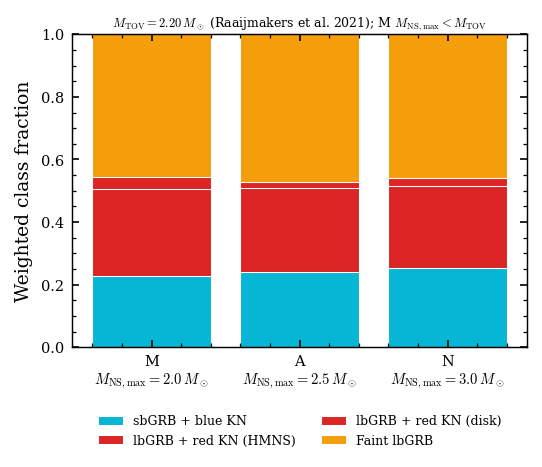

In [21]:
# Models ordered by increasing M_NS,max.  LETTERS_NS_MAX holds the paper I
# suffixes (data keys for MODELS); axis labels use the paper II letters
# (J->M, A->A, K->N).
LETTERS_NS_MAX = ['J', 'A', 'K']
NS_MAX_LABELS  = [_p2('J')+'\n'+r'$M_\mathrm{NS,max}=2.0\,M_\odot$',
                  _p2('A')+'\n'+r'$M_\mathrm{NS,max}=2.5\,M_\odot$',
                  _p2('K')+'\n'+r'$M_\mathrm{NS,max}=3.0\,M_\odot$']

frac_ns_max, _ = _class_fraction_matrix(LETTERS_NS_MAX, CLASS_KEYS_2024)
print('M_NS,max class fractions (rows = '
      + ', '.join(_p2(s) for s in LETTERS_NS_MAX) + '; cols = '
      + ', '.join(CLASS_KEYS_2024) + '):')
print(np.array2string(frac_ns_max, formatter={'float_kind': '{:.3f}'.format}))

fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
x = np.arange(len(LETTERS_NS_MAX))
bottom = np.zeros(len(LETTERS_NS_MAX))
for j, (label, colour) in enumerate(zip(CLASS_KEYS_2024, CLASS_COLOURS_2024)):
    ax.bar(x, frac_ns_max[:, j], bottom=bottom, color=colour, label=label,
           edgecolor='white', linewidth=0.5)
    top = bottom + frac_ns_max[:, j]
    bottom = top
ax.set_xticks(x)
ax.set_xticklabels(NS_MAX_LABELS, fontsize=7)
ax.set_ylabel('Weighted class fraction')
ax.set_ylim(0, 1)
# M_TOV reference line on the secondary axis.  Shown via annotation in the
# subplot title so the J vs M_TOV gap is reader-visible at a glance.
ax.set_title(rf'$M_\mathrm{{TOV}} = {M_TOV:.2f}\,M_\odot$ '
             r'(Raaijmakers et al. 2021); '
             rf'{_p2("J")} $M_\mathrm{{NS,max}} < M_\mathrm{{TOV}}$',
             fontsize=6, pad=4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          fontsize=6, frameon=False)
fig.savefig('plots/class_fractions_ns_max.pdf')
fig.savefig('plots/class_fractions_ns_max.png', dpi=300)
plt.show()

### 9.2 BNS delay-time CDF by model

Weighted CDF of $t_\mathrm{delay} = t_\mathrm{form} + t_c$ (Myr) per model. $\alpha_\mathrm{CE}$ drives post-CE separations and the delay-time distribution (van Son et al. 2022, ApJ 931, 17, Fig. 14): H shifts to shorter delays, I to longer. $M_\mathrm{NS,max}$ (M, N) leaves the CDF essentially unchanged (a remnant-mass cap, not a separation knob). The shift propagates to the Section 8 offsets and the Beniamini and Nakar (2019) sGRB delay prior.

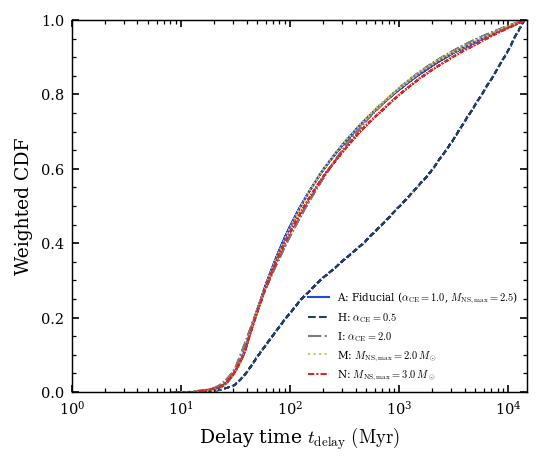

In [22]:
def _weighted_cdf(values, weights):
    """STROOPWAFEL-weighted CDF: returns (sorted_x, cum_fraction).

    Vectorized via np.argsort + np.cumsum (no per-system Python loop).
    Suitable for ax.step(..., where='post').
    """
    order = np.argsort(values)
    x_sorted = values[order]
    w_sorted = weights[order]
    cdf = np.cumsum(w_sorted) / w_sorted.sum()
    return x_sorted, cdf


fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
for letter in MODEL_LETTERS:
    bns = MODELS[letter]['bns']
    x_sorted, cdf = _weighted_cdf(bns['delay_time'], bns['weights'])
    # Subsample plot points to keep the PDF lightweight: 1000 evenly-spaced
    # quantiles preserve the visual CDF shape without rasterising 10^6 steps.
    if len(x_sorted) > 1000:
        idx = np.linspace(0, len(x_sorted) - 1, 1000).astype(int)
        x_sorted, cdf = x_sorted[idx], cdf[idx]
    ax.step(x_sorted, cdf, where='post',
            color=MODEL_COLOURS[letter],
            ls=MODEL_LINESTYLES[letter],
            lw=1.0, label=f'{_p2(letter)}: {MODEL_DESCR[letter]}')
ax.set_xscale('log')
ax.set_xlabel(r'Delay time $t_\mathrm{delay}\ (\mathrm{Myr})$')
ax.set_ylabel('Weighted CDF')
ax.set_xlim(1, 1.5e4)
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=5, frameon=False)
fig.savefig('plots/delay_time_cdf_by_model.pdf')
fig.savefig('plots/delay_time_cdf_by_model.png', dpi=300)
plt.show()

## 10. BNS Jet Breakout Efficiency and the Observable Rate Ladder

A disk-mass classification counts every system above threshold as a GRB, which is why the Section 6 per-class rates are upper bounds (100 percent jet launching). The jet must still bore through the merger ejecta. Following Pais et al. (2024, [arXiv:2407.19002](https://arxiv.org/abs/2407.19002)), a disk-launched jet breaks out only if its energy clears the obstructing ejecta column inside the engine working time, subject to a collimation gate (their Eqs. 3 and 4). The breakout fraction $f_\mathrm{break}$ is the STROOPWAFEL-weighted share of each Gottlieb (2024) class that passes.

Two refinements enter `breakout_fraction_bns_eos`:

- **EOS marginalisation.** `bns_disk_mass` is knife-edge sensitive near $R_{1.4} \sim 12$ km (about 100x swings per 1 km), so a single radius is not meaningful. The fraction is averaged over the four `EOS_MODELS` (APR4, SFHo, LS220, DD2), each supplying self-consistent radii via `ns_radius_from_eos`; the band brackets the EOS spread and the Monte Carlo over the jet and ejecta parameters (16/50/84 percentiles).
- **Remnant conditioning.** The prompt-collapse disk class launches at $t_d \sim 0.01$ to $0.1$ s, before the secular wind, so its obstruction is the dynamical ejecta alone. The two HMNS classes launch only after collapse, by which point a wind of $f_\mathrm{wind} M_\mathrm{disk}$ (`GOTTLIEB25_WIND_FRAC = 0.3`) pollutes the funnel; that wind adds to their obstruction and the longer delay lowers their breakout. The `cls24` masks carry the canonical `classify_bns_2024` labels the conditioning keys on.

The observable rate follows $\mathcal{R}_\mathrm{intrinsic} \to$ `apply_bns_jet_breakout` $\to$ `beamed_rate`: breakout multiplies in the jet-clearing fraction (so the corrected rate is no longer an upper bound), then beaming applies the per-class jet solid angle. The result is compared against the local sGRB rate of Colombo et al. (2022).

class                      f_break (16/50/84)   R_int   R_brk  R_beam
sbGRB + blue KN        0.000 [0.000, 1.000]     21.78    0.00    0.00
lbGRB + red KN (HMNS)  0.322 [0.000, 1.000]     19.75    6.36    0.04
lbGRB + red KN (disk)  0.952 [0.896, 1.000]      1.36    1.30    0.01
Faint lbGRB            0.957 [0.897, 1.000]     12.09   11.58    0.07


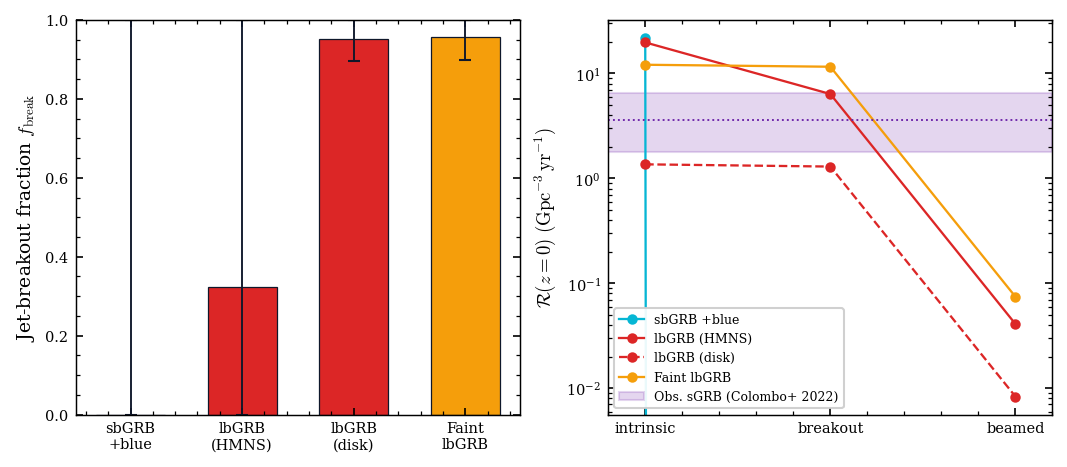

In [23]:
# Canonical Gottlieb (2024) labels; cls24 (Section 0) already uses them, so the
# HMNS remnant conditioning inside breakout_fraction_bns_eos lines up.
_canon = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
          'lbGRB + red KN (disk)', 'Faint lbGRB']

# EOS-marginalised, remnant-conditioned breakout fraction with a band.
f_break = breakout_fraction_bns_eos(
    cls24, m1_bns, m2_bns, w_bns,
    n_draws=512, rng=np.random.default_rng(2025))

# Map canonical class -> Section 6 rate-dict key (short labels) and -> jet angle.
# sbGRB carries the wider short-GRB jet; the lbGRB classes share the narrow MAD
# core (CLASS_THETA_J fiducials).
_rate_key = {'sbGRB + blue KN': 'sbGRB + blue KN',
             'lbGRB + red KN (HMNS)': 'lbGRB (HMNS)',
             'lbGRB + red KN (disk)': 'lbGRB (disk)',
             'Faint lbGRB': 'Faint lbGRB'}
_theta_key = {'sbGRB + blue KN': 'sbGRB',
              'lbGRB + red KN (HMNS)': 'lbGRB',
              'lbGRB + red KN (disk)': 'lbGRB',
              'Faint lbGRB': 'lbGRB'}

ladder = {}
print(f"{'class':22s} {'f_break (16/50/84)':>22s} "
      f"{'R_int':>7s} {'R_brk':>7s} {'R_beam':>7s}")
for lbl in _canon:
    fb = f_break[lbl]
    R_int = float(merger_rates_BNS[_rate_key[lbl]][iz0])
    R_break = float(apply_bns_jet_breakout(R_int, fb['med']))
    theta = CLASS_THETA_J[_theta_key[lbl]]['fid']
    R_beam = float(beamed_rate(R_break, theta))
    ladder[lbl] = {'R_int': R_int, 'R_break': R_break, 'R_beam': R_beam}
    # Ladder is monotonically non-increasing (f_break <= 1, beaming < 1).
    if not np.isnan(fb['med']):
        assert 0.0 <= R_beam <= R_break + 1e-9 and R_break <= R_int + 1e-9, lbl
    print(f"{lbl:22s} {fb['med']:.3f} [{fb['lo']:.3f}, {fb['hi']:.3f}]   "
          f"{R_int:7.2f} {R_break:7.2f} {R_beam:7.2f}")

_short = {'sbGRB + blue KN': 'sbGRB\n+blue',
          'lbGRB + red KN (HMNS)': 'lbGRB\n(HMNS)',
          'lbGRB + red KN (disk)': 'lbGRB\n(disk)',
          'Faint lbGRB': 'Faint\nlbGRB'}
_colors = {'sbGRB + blue KN': C_SB_BLUE,
           'lbGRB + red KN (HMNS)': C_LB_HMNS,
           'lbGRB + red KN (disk)': C_LB_DISK,
           'Faint lbGRB': C_FAINT}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

# Left panel: per-class jet-breakout fraction with EOS + MC band.
x = np.arange(len(_canon))
meds = np.array([f_break[l]['med'] for l in _canon])
los = np.array([f_break[l]['lo'] for l in _canon])
his = np.array([f_break[l]['hi'] for l in _canon])
axL.bar(x, meds, width=0.62,
        color=[_colors[l] for l in _canon], edgecolor=C_TEXT, linewidth=0.6)
axL.errorbar(x, meds, yerr=np.vstack([meds - los, his - meds]),
             fmt='none', ecolor=C_TEXT, elinewidth=0.9, capsize=3)
axL.set_xticks(x)
axL.set_xticklabels([_short[l] for l in _canon])
axL.set_ylim(0, 1.0)
axL.set_ylabel(r'Jet-breakout fraction $f_\mathrm{break}$')

# Right panel: R(z=0) ladder intrinsic -> breakout -> beamed, per class.
_stages = ['R_int', 'R_break', 'R_beam']
sx = np.arange(len(_stages))
for lbl in _canon:
    axR.plot(sx, [ladder[lbl][s] for s in _stages],
             marker='o', ms=4, color=_colors[lbl],
             ls='--' if lbl == 'lbGRB + red KN (disk)' else '-',
             lw=1.1, label=_short[lbl].replace('\n', ' '))
_obs = OBSERVED_SGRB_RATES['Colombo+ 2022']
axR.axhspan(_obs['R_obs_lo'], _obs['R_obs_hi'], color=C_OBS, alpha=0.18,
            label='Obs. sGRB (Colombo+ 2022)')
axR.axhline(_obs['R_obs'], color=C_OBS, lw=0.9, ls=':')
axR.set_yscale('log')
axR.set_xlim(-0.2, 2.2)
axR.set_xticks(sx)
axR.set_xticklabels(['intrinsic', 'breakout', 'beamed'])
axR.set_ylabel(r'$\mathcal{R}(z=0)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
axR.legend(fontsize=6, loc='lower left')

fig.savefig('plots/fig10_bns_jet_breakout.png', dpi=300)
fig.savefig('plots/fig10_bns_jet_breakout.pdf')
plt.show()

**Figure 10.** BNS jet-breakout efficiency and the observable rate ladder for COMPAS Model A (Zenodo 5189849). *Left:* EOS-marginalised, remnant-conditioned jet-breakout fraction $f_\mathrm{break}$ per Gottlieb (2024) class (Pais et al. 2024, arXiv:2407.19002, Eqs. 3 and 4); the band brackets the four-EOS spread (APR4, SFHo, LS220, DD2) and the Monte Carlo over the jet and ejecta parameters (16/50/84 percentiles). *Right:* local intrinsic rate $\mathcal{R}(z=0)$ stepped through breakout ($\mathcal{R} \to f_\mathrm{break}\,\mathcal{R}$) and beaming ($\times\,(1-\cos\theta_j)$, with $\theta_j = 13^\circ$ for sbGRB and $6.5^\circ$ for the lbGRB classes) against the local sGRB rate of Colombo et al. (2022), $3.6^{+2.9}_{-1.8}\ \mathrm{Gpc^{-3}\,yr^{-1}}$ (shaded). Sample: BNS raw $N = 233{,}137$, Kish $n_\mathrm{eff} = 65{,}134$; cosmology Planck 2015. The intrinsic rate is the Section 6 upper bound; the breakout-corrected rate is not, since it folds in the jet-clearing fraction.

## 11. Full 20-Model Broekgaarden+ 2021 Grid Scan

Section 9 establishes robustness across the manuscript-core five variations (A, F, G, J, K). This section extends the test to the complete Broekgaarden et al. (2021, arXiv:2103.02608) 20-model grid, varying one binary-physics assumption at a time around Model A: common-envelope efficiency, mass-transfer efficiency, case BB stability, common-envelope survival, supernova remnant engine, maximum NS mass, pair-instability supernovae, natal kicks, and Wolf-Rayet winds.

The scan loads each model once, applies the Alsing, Silva and Berti (2018) NS-mass remap, classifies under the Gottlieb (2024) hybrid, calibrates `MEAN_MASS_EVOLVED` per population, and computes the calibrated local intrinsic rate. Per-model summaries are cached to `plots/grid_scan_results.npz` so the figure cells regenerate without rerunning the multi-hour scan. This is the one sanctioned Python loop over models; every per-system reduction is a weighted numpy broadcast.

### 11.0 Setup and metadata validation

Validates all 40 HDF5 files before the scan: embedded `model` / `ns_max` / `kind` attributes against the `BROEKGAARDEN21_MODELS` registry, a positive `weights_intrinsic/w_000` calibration anchor, and birth metallicities inside the shared `METALLICITY_GRID` bounds. The empirical $Z$ range shrinks in some variations because the most extreme bins hold no merging systems, so this is a subset test against the prior bounds, not an equality test (`verify_shared_metallicity_prior` would raise on that benign shrinkage).

In [24]:
import os

import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.cosmology import Planck15
from compas_python_utils.cosmic_integration import FastCosmicIntegration as fci

from grb_io import (BROEKGAARDEN21_MODELS, ALL_MODEL_SUFFIXES,
                    BROEKGAARDEN22_PAPER_II_LETTERS,
                    METALLICITY_GRID, read_expected_local_rate,
                    read_metallicity_range,
                    load_bns, load_bhns,
                    load_bns_with_channels, load_bhns_with_channels)
from grb_physics import remap_ns_masses_double_gaussian, remap_ns_marginal, EOS_MODELS
from grb_classify import (classify_bns_2024, classify_bhns,
                          classify_formation_channels, channel_class_crosstab)
from grb_rates import (compute_merger_rate, calibrate_mean_mass_evolved,
                       MSSFR_PARAMS_LEVINA26_TNG100, SFR_PARAMS_LEVINA26_TNG100,
                       LVK_GWTC5_LOCAL_RATES, bootstrap_class_fractions)
from grb_plot_style import (apply_apj_rcparams, model_grid_colors,
                            MODEL_GRID_FAMILY_ORDER, C_SB_BLUE, C_LB_HMNS,
                            C_LB_DISK, C_FAINT, C_NO_GRB)

apply_apj_rcparams()

# Fiducial BH spin (Foucart 2018 calibrated chi range; classify_bhns default).
A_BH_FID = 0.5

DATA_DIR = 'Data'
PLOTS_DIR = 'Plots'
RESULTS_PATH = os.path.join(PLOTS_DIR, 'grid_scan_results.npz')

# One colour per model, family-major over cividis (Crameri et al. 2020).
GRID_COLORS = model_grid_colors()


def _bns_path(suffix):
    return os.path.join(DATA_DIR, f'COMPASCompactOutput_BNS_{suffix}.h5')


def _bhns_path(suffix):
    return os.path.join(DATA_DIR, f'COMPASCompactOutput_BHNS_{suffix}.h5')


# Validate all 40 files: HDF5 root attributes vs registry, anchor present and
# positive, empirical metallicity range inside the COMPAS prior grid.
print(f"{'paper-II':8s} {'paper-I':8s} {'family':13s} {'ns_max':>6s} "
      f"{'Rloc_BNS':>9s} {'Rloc_BHNS':>9s}  ok")
for _s in ALL_MODEL_SUFFIXES:
    _info = BROEKGAARDEN21_MODELS[_s]
    _rloc = {}
    for _kind, _path in (('BNS', _bns_path(_s)), ('BHNS', _bhns_path(_s))):
        with h5.File(_path, 'r') as _f:
            _attrs = dict(_f.attrs)
        assert str(_attrs.get('model')) == _s, (
            f"{_path}: embedded model {_attrs.get('model')!r} != {_s!r}")
        assert float(_attrs['ns_max']) == _info['ns_max'], (
            f"{_path}: ns_max {_attrs.get('ns_max')} != {_info['ns_max']}")
        assert str(_attrs.get('kind')) == _kind, (
            f"{_path}: kind {_attrs.get('kind')!r} != {_kind!r}")
        _r = read_expected_local_rate(_path)
        assert _r > 0, f"{_path}: non-positive local-rate anchor {_r}"
        _zlo, _zhi = read_metallicity_range(_path)
        assert _zlo >= METALLICITY_GRID[0] - 1e-12 and _zhi <= METALLICITY_GRID[-1] + 1e-12, (
            f"{_path}: empirical Z range [{_zlo}, {_zhi}] escapes the prior grid")
        _rloc[_kind] = _r
    print(f"{BROEKGAARDEN22_PAPER_II_LETTERS[_s]:8s} {_s:8s} "
          f"{_info['family']:13s} {_info['ns_max']:>6.1f} "
          f"{_rloc['BNS']:>9.1f} {_rloc['BHNS']:>9.1f}  yes")
print(f"\nAll {len(ALL_MODEL_SUFFIXES)} model pairs validated against "
      f"BROEKGAARDEN21_MODELS.")

# Paper-I <-> paper-II model-letter crosswalk (Broekgaarden+ 2021 -> 2022).
# The data layer (filenames, expected_model, the grid cache) keys on the
# paper-I suffix; every figure and table in the notebook displays the paper-II
# letter.  This is the single documented mapping the reader-facing labels use.
_crosswalk = pd.DataFrame(
    [{'paper_II': BROEKGAARDEN22_PAPER_II_LETTERS[_s],
      'paper_I': _s,
      'family': BROEKGAARDEN21_MODELS[_s]['family'],
      'ns_max': BROEKGAARDEN21_MODELS[_s]['ns_max'],
      'alpha_ce': BROEKGAARDEN21_MODELS[_s]['alpha_ce'],
      'description': BROEKGAARDEN21_MODELS[_s]['description']}
     for _s in ALL_MODEL_SUFFIXES]
).sort_values('paper_II').reset_index(drop=True)
print('\nPaper-I <-> paper-II model crosswalk (Broekgaarden+ 2021 / 2022):')
print(_crosswalk.to_string(index=False))

paper-II paper-I  family        ns_max  Rloc_BNS Rloc_BHNS  ok
A        A        fiducial         2.5      33.4      43.0  yes
B        B        mt_efficiency    2.5      17.9      17.8  yes
C        C        mt_efficiency    2.5      19.0      10.1  yes
D        D        mt_efficiency    2.5      55.6       4.7  yes
E        E        case_bb          2.5       0.4       8.2  yes
F        EH       case_bb          2.5      25.3      27.6  yes
G        alpha0p1 alpha_ce         2.5      31.4       3.3  yes
H        F        alpha_ce         2.5      18.8       9.2  yes
I        G        alpha_ce         2.5      51.5      51.7  yes
J        alpha10  alpha_ce         2.5      58.2      17.9  yes
K        H        ce_survival      2.5      45.1      53.3  yes
L        I        sn_engine        2.5      30.2     131.2  yes


M        J        ns_mass_cap      2.0      33.2      39.2  yes
N        K        ns_mass_cap      3.0      34.4      46.5  yes
O        L        pisn             2.5      33.8      43.8  yes
P        M        sn_kick          2.5      60.6     137.2  yes
Q        N        sn_kick          2.5     126.8     282.5  yes
R        O        bh_kick          2.5      34.0     225.5  yes


S        fWR0p1   wr_winds         2.5      31.0      64.0  yes
T        fWR5     wr_winds         2.5      23.4       5.7  yes

All 20 model pairs validated against BROEKGAARDEN21_MODELS.

Paper-I <-> paper-II model crosswalk (Broekgaarden+ 2021 / 2022):
paper_II  paper_I        family  ns_max  alpha_ce                                           description
       A        A      fiducial     2.5       1.0 Fiducial (alpha_CE=1.0, M_NS,max=2.5, delayed engine)
       B        B mt_efficiency     2.5       1.0                    Mass-transfer efficiency beta=0.25
       C        C mt_efficiency     2.5       1.0                     Mass-transfer efficiency beta=0.5
       D        D mt_efficiency     2.5       1.0                    Mass-transfer efficiency beta=0.75
       E        E       case_bb     2.5       1.0                        Unstable case BB mass transfer
       F       EH       case_bb     2.5       1.0   Unstable case BB plus optimistic CE (paper-II only)
       G alpha0p

### 11.0b Streaming grid scan

Loops the 20 variations (manuscript core A, F, G, J, K first so the Alsing remap RNG seeds reproduce the Section 9 draws bit for bit). For each model: load BNS and BHNS with formation channels, remap NS masses, classify, compute weighted class fractions, formation-channel fractions, the channel x class contingency ($P(\mathrm{class}\,|\,\mathrm{channel})$), per-population `MEAN_MASS_EVOLVED`, the calibrated local intrinsic rate at $z=0$ (unsmoothed, per the rate-quote gotcha), and fixed-bin weighted mass histograms. One model is held in memory at a time. Results are written to `plots/grid_scan_results.npz` and a human-readable `plots/grid_scan_summary.csv`.

BHNS rates here are intrinsic (no misalignment, no beaming), to compare against the LVK GWTC-5.0 NSBH band on equal footing in 11.1.

In [25]:
BNS_CLASS_KEYS = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                  'lbGRB + red KN (disk)', 'Faint lbGRB']
BHNS_CLASS_KEYS = ['lbGRB + red KN (BHNS disk)', 'Faint lbGRB (BHNS)', 'No GRB']
CH_KEYS = ['I  Stable MT + CE', 'II  Stable MT only', 'III Single-core CE',
           'IV  Double-core CE', 'V   Other']

# Cosmology grid + Levina+ 2026 TNG100-1 MSSFR / SFR (matches Section 4).
redshifts, _, times, time_first_SF, _, _ = fci.calculate_redshift_related_params(
    max_redshift=10.0, redshift_step=0.01, cosmology=Planck15)
sfr = fci.find_sfr(redshifts, **SFR_PARAMS_LEVINA26_TNG100)
dPdlogZ, metallicities, p_draw = fci.find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=float(np.log(METALLICITY_GRID[0])),
    max_logZ_COMPAS=float(np.log(METALLICITY_GRID[-1])),
    **MSSFR_PARAMS_LEVINA26_TNG100)
p_draw = float(p_draw)
iz0 = int(np.argmin(np.abs(redshifts)))

# Fixed histogram support shared across models so 11.4 can overlay engines.
MBH_BINS = np.linspace(2.0, 25.0, 46)
MTOT_BINS = np.linspace(2.0, 6.0, 46)

_scan = {k: {} for k in ('R0_bns', 'R0_bhns', 'frac_bns', 'frac_bhns',
                         'fracerr_bns', 'fracerr_bhns',
                         'bootlo_bns', 'boothi_bns', 'bootlo_bhns', 'boothi_bhns',
                         'chfrac_bns', 'chfrac_bhns', 'crosstab_bns',
                         'eos_frac_bns', 'eos_frac_bns_kcons',
                         'mbh_hist', 'mtot_hist')}

# Dense-matter EOS sweep (Section 11.6 / Fig. eosmatrix).  Columns are ordered
# soft-to-stiff by R_1.4; each EOS supplies its own M_TOV (and M_crit) from
# EOS_MODELS.  For every (model, EOS) we recompute the four-class BNS fractions
# two ways: with the fiducial Gottlieb (2023) k = 1.27 held fixed across all
# EOS (only M_TOV varies, the "linked M_thresh = k M_TOV" of the main text),
# and with the EOS-consistent k = M_crit / M_TOV implied by the Bauswein (2013)
# prompt-collapse masses.  The sbGRB boundary is hmns_factor * M_TOV and so is
# independent of k; the k choice only moves the HMNS / (disk+faint) split.
_EOS_KEYS = ['APR4', 'SFHo', 'LS220', 'DD2']

# Bootstrap replicates for the class-fraction credible intervals.  500 is
# enough for stable 16/84 percentiles and keeps the added cost on the BHNS
# sample (N ~ 1.5e6) to a few minutes across the 40-file scan.
_N_BOOT_GRID = 500

_no_channels = []  # models whose formationChannels group does not align

# Cache guard: the 40-file scan runs cosmic integration four times per model
# and takes many minutes.  Skip it when a complete cache (including the
# weighted-Poisson fracerr arrays and the bootstrap class-fraction intervals)
# and the EOS x model class-fraction sweep) is already on disk; delete
# plots/grid_scan_results.npz to force a fresh scan.
_need_scan = True
if os.path.exists(RESULTS_PATH):
    try:
        _chk = np.load(RESULTS_PATH, allow_pickle=False)
        _need_scan = not (
            'fracerr_bns' in _chk.files
            and 'bootlo_bns' in _chk.files
            and 'eos_frac_bns' in _chk.files
            and [str(s) for s in _chk['suffixes']] == list(ALL_MODEL_SUFFIXES))
        _chk.close()
    except Exception:
        _need_scan = True
if not _need_scan:
    print(f"Cached grid scan with weighted-Poisson arrays found at "
          f"{RESULTS_PATH}; skipping the 40-file rescan.")

_scan_suffixes = list(ALL_MODEL_SUFFIXES) if _need_scan else []
for _i, _s in enumerate(_scan_suffixes):
    # Most files carry a formationChannels group that aligns row-for-row with
    # doubleCompactObjects, but a few Broekgaarden+ 2021 variations (e.g. L,
    # noPISN) ship a channel group with a slightly different row count, so the
    # positional join in load_*_with_channels raises IndexError.  Channels feed
    # only the secondary outputs (channel fractions, the 11.5 crosstab); fall
    # back to the base loader and flag the model so those outputs are NaN.
    try:
        _bns = load_bns_with_channels(path=_bns_path(_s), expected_model=_s)
        _has_ch_bns = True
    except IndexError:
        _bns = load_bns(path=_bns_path(_s), expected_model=_s)
        _has_ch_bns = False
        _no_channels.append(f'{_s}/BNS')
    try:
        _bhns = load_bhns_with_channels(path=_bhns_path(_s), expected_model=_s)
        _has_ch_bhns = True
    except IndexError:
        _bhns = load_bhns(path=_bhns_path(_s), expected_model=_s)
        _has_ch_bhns = False
        _no_channels.append(f'{_s}/BHNS')
    _bns['m1'], _bns['m2'] = remap_ns_masses_double_gaussian(
        _bns['m1'], _bns['m2'], weights=_bns['weights'],
        rng=np.random.default_rng(42 + _i))
    _bhns['M_NS'] = remap_ns_marginal(
        _bhns['M_NS'], weights=_bhns['weights'],
        rng=np.random.default_rng(43 + _i))
    _wb, _wh = _bns['weights'], _bhns['weights']

    # Weighted GRB-class fractions (Gottlieb 2024 hybrid).
    _cb = classify_bns_2024(_bns['m1'], _bns['m2'])
    _masks_b = np.stack([_cb[k] for k in BNS_CLASS_KEYS])
    _scan['frac_bns'][_s] = (_masks_b * _wb).sum(-1) / _wb.sum()
    # Weighted-Poisson 1-sigma on each class fraction: sqrt(sum w^2)/sum w.
    _scan['fracerr_bns'][_s] = np.sqrt((_masks_b * _wb * _wb).sum(-1)) / _wb.sum()
    # Resampling-bootstrap 16/84 interval on each class fraction (the version
    # quoted in the manuscript; the analytic fracerr above is kept for the
    # regression tests).  Fixed per-model seed for reproducibility.
    _boot_b = bootstrap_class_fractions(
        _masks_b, _wb, n_boot=_N_BOOT_GRID, rng=np.random.default_rng(1000 + _i),
        percentiles=(16.0, 84.0))
    _scan['bootlo_bns'][_s] = _boot_b[:, 0]
    _scan['boothi_bns'][_s] = _boot_b[:, 1]
    _ch = classify_bhns(_bhns['M_BH'], _bhns['M_NS'], a_BH=A_BH_FID)
    _masks_h = np.stack([_ch[k] for k in BHNS_CLASS_KEYS])
    _scan['frac_bhns'][_s] = (_masks_h * _wh).sum(-1) / _wh.sum()
    _scan['fracerr_bhns'][_s] = np.sqrt((_masks_h * _wh * _wh).sum(-1)) / _wh.sum()
    _boot_h = bootstrap_class_fractions(
        _masks_h, _wh, n_boot=_N_BOOT_GRID, rng=np.random.default_rng(2000 + _i),
        percentiles=(16.0, 84.0))
    _scan['bootlo_bhns'][_s] = _boot_h[:, 0]
    _scan['boothi_bhns'][_s] = _boot_h[:, 1]

    # EOS x model sweep: weighted four-class BNS fractions per EOS, computed
    # two ways on the same remapped masses.  Fixed k = 1.27 (only M_TOV moves)
    # is the main-text treatment; EOS-consistent k = M_crit / M_TOV is the
    # rigor check.  m_thresh=None lets k_thresh set the prompt-collapse line.
    _ef = np.zeros((len(_EOS_KEYS), len(BNS_CLASS_KEYS)))
    _efk = np.zeros_like(_ef)
    for _e, _eos in enumerate(_EOS_KEYS):
        _mtov_e = EOS_MODELS[_eos]['M_TOV']
        _kcons = EOS_MODELS[_eos]['M_crit'] / _mtov_e
        _c_fix = classify_bns_2024(_bns['m1'], _bns['m2'],
                                   m_tov=_mtov_e, m_thresh=None, k_thresh=1.27)
        _c_con = classify_bns_2024(_bns['m1'], _bns['m2'],
                                   m_tov=_mtov_e, m_thresh=None, k_thresh=_kcons)
        _ef[_e] = [_wb[_c_fix[k]].sum() / _wb.sum() for k in BNS_CLASS_KEYS]
        _efk[_e] = [_wb[_c_con[k]].sum() / _wb.sum() for k in BNS_CLASS_KEYS]
    _scan['eos_frac_bns'][_s] = _ef
    _scan['eos_frac_bns_kcons'][_s] = _efk

    # Broekgaarden I-V formation-channel fractions and channel x class table.
    # NaN where the channel group does not align (flagged in _no_channels).
    if _has_ch_bns:
        _chan_b = classify_formation_channels(
            dblCE=_bns['dblCE'], fc_CEE=_bns['fc_CEE'],
            fc_mt_p1=_bns['fc_mt_p1'], fc_mt_s1=_bns['fc_mt_s1'],
            fc_mt_p1_K1=_bns['fc_mt_p1_K1'], fc_mt_s1_K2=_bns['fc_mt_s1_K2'])
        _scan['chfrac_bns'][_s] = np.array(
            [_wb[_chan_b[k]].sum() / _wb.sum() for k in CH_KEYS])
        _scan['crosstab_bns'][_s] = channel_class_crosstab(
            _chan_b, _cb, _wb, normalise='channel').to_numpy()
    else:
        _chan_b = None
        _scan['chfrac_bns'][_s] = np.full(len(CH_KEYS), np.nan)
        _scan['crosstab_bns'][_s] = np.full((len(CH_KEYS), len(BNS_CLASS_KEYS)), np.nan)
    if _has_ch_bhns:
        _chan_h = classify_formation_channels(
            dblCE=_bhns['dblCE'], fc_CEE=_bhns['fc_CEE'],
            fc_mt_p1=_bhns['fc_mt_p1'], fc_mt_s1=_bhns['fc_mt_s1'],
            fc_mt_p1_K1=_bhns['fc_mt_p1_K1'], fc_mt_s1_K2=_bhns['fc_mt_s1_K2'])
        _scan['chfrac_bhns'][_s] = np.array(
            [_wh[_chan_h[k]].sum() / _wh.sum() for k in CH_KEYS])
    else:
        _chan_h = None
        _scan['chfrac_bhns'][_s] = np.full(len(CH_KEYS), np.nan)

    # Per-population MEAN_MASS_EVOLVED, then calibrated unsmoothed R(z=0).
    _mme_b = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF, _bns['metallicity'],
        _bns['delay_time'], _wb, read_expected_local_rate(_bns_path(_s)),
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _mme_h = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF, _bhns['metallicity'],
        _bhns['delay_time'], _wh, read_expected_local_rate(_bhns_path(_s)),
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _Rb = compute_merger_rate(
        redshifts, times, time_first_SF, sfr / _mme_b, p_draw,
        dPdlogZ, metallicities, _bns['metallicity'], _bns['delay_time'],
        _wb, smooth_sigma=0)
    _Rh = compute_merger_rate(
        redshifts, times, time_first_SF, sfr / _mme_h, p_draw,
        dPdlogZ, metallicities, _bhns['metallicity'], _bhns['delay_time'],
        _wh, smooth_sigma=0)
    _scan['R0_bns'][_s] = float(_Rb[iz0])
    _scan['R0_bhns'][_s] = float(_Rh[iz0])

    # Weighted mass histograms: BHNS M_BH and BNS total mass (for 11.4).
    _scan['mbh_hist'][_s] = np.histogram(
        _bhns['M_BH'], bins=MBH_BINS, weights=_wh)[0] / _wh.sum()
    _scan['mtot_hist'][_s] = np.histogram(
        _bns['m1'] + _bns['m2'], bins=MTOT_BINS, weights=_wb)[0] / _wb.sum()

    print(f"[{_i + 1:2d}/{len(ALL_MODEL_SUFFIXES)}] "
          f"{BROEKGAARDEN22_PAPER_II_LETTERS[_s]:>3s} (paper-I {_s:<8s}) "
          f"R0_BNS={_scan['R0_bns'][_s]:8.2f}  "
          f"R0_BHNS={_scan['R0_bhns'][_s]:8.2f}  "
          f"N_BNS={_bns['n_merging']:>8,d}  N_BHNS={_bhns['n_merging']:>8,d}",
          flush=True)
    del _bns, _bhns, _cb, _ch, _masks_b, _masks_h, _chan_b, _chan_h

# Stack per-model results in ALL_MODEL_SUFFIXES order and cache.
if _need_scan:
    _order = list(ALL_MODEL_SUFFIXES)
    np.savez(
        RESULTS_PATH,
        suffixes=np.array(_order),
        families=np.array([BROEKGAARDEN21_MODELS[s]['family'] for s in _order]),
        R0_bns=np.array([_scan['R0_bns'][s] for s in _order]),
        R0_bhns=np.array([_scan['R0_bhns'][s] for s in _order]),
        frac_bns=np.stack([_scan['frac_bns'][s] for s in _order]),
        frac_bhns=np.stack([_scan['frac_bhns'][s] for s in _order]),
        fracerr_bns=np.stack([_scan['fracerr_bns'][s] for s in _order]),
        fracerr_bhns=np.stack([_scan['fracerr_bhns'][s] for s in _order]),
        bootlo_bns=np.stack([_scan['bootlo_bns'][s] for s in _order]),
        boothi_bns=np.stack([_scan['boothi_bns'][s] for s in _order]),
        bootlo_bhns=np.stack([_scan['bootlo_bhns'][s] for s in _order]),
        boothi_bhns=np.stack([_scan['boothi_bhns'][s] for s in _order]),
        chfrac_bns=np.stack([_scan['chfrac_bns'][s] for s in _order]),
        chfrac_bhns=np.stack([_scan['chfrac_bhns'][s] for s in _order]),
        crosstab_bns=np.stack([_scan['crosstab_bns'][s] for s in _order]),
        eos_frac_bns=np.stack([_scan['eos_frac_bns'][s] for s in _order]),
        eos_frac_bns_kcons=np.stack([_scan['eos_frac_bns_kcons'][s] for s in _order]),
        eos_names=np.array(_EOS_KEYS),
        mbh_hist=np.stack([_scan['mbh_hist'][s] for s in _order]),
        mtot_hist=np.stack([_scan['mtot_hist'][s] for s in _order]),
        mbh_bins=MBH_BINS, mtot_bins=MTOT_BINS,
        bns_class_keys=np.array(BNS_CLASS_KEYS),
        bhns_class_keys=np.array(BHNS_CLASS_KEYS),
        ch_keys=np.array(CH_KEYS))
    print(f"\nWrote {RESULTS_PATH}")
    if _no_channels:
        print(f"Formation-channel group did not align for: "
              f"{', '.join(_no_channels)}; their channel fractions and "
              f"crosstab rows are NaN.")

# Summary table, read back from the cached or freshly written npz.
_res = np.load(RESULTS_PATH, allow_pickle=False)
_order = [str(s) for s in _res['suffixes']]
_summary = pd.DataFrame({
    'paper_ii': [BROEKGAARDEN22_PAPER_II_LETTERS[s] for s in _order],
    'suffix': _order,
    'family': [str(f) for f in _res['families']],
    'ns_max': [BROEKGAARDEN21_MODELS[s]['ns_max'] for s in _order],
    'R0_BNS': _res['R0_bns'],
    'R0_BHNS': _res['R0_bhns'],
})

# Bootstrap class-fraction credible intervals (16/84).  Model A is the
# manuscript headline (Table 2); the per-model leading-class interval below
# bounds the sampling uncertainty quoted in the Section 11 captions.
_bk = [str(k) for k in _res['bns_class_keys']]
_hk = [str(k) for k in _res['bhns_class_keys']]
_iA = _order.index('A')
print("Model A bootstrap 16/84 class-fraction intervals "
      f"(n_boot={_N_BOOT_GRID}):")
for _j, _k in enumerate(_bk):
    print(f"  BNS  {_k:28s} {_res['frac_bns'][_iA, _j] * 100:5.2f}% "
          f"[{_res['bootlo_bns'][_iA, _j] * 100:5.2f}, "
          f"{_res['boothi_bns'][_iA, _j] * 100:5.2f}]")
for _j, _k in enumerate(_hk):
    print(f"  BHNS {_k:28s} {_res['frac_bhns'][_iA, _j] * 100:5.2f}% "
          f"[{_res['bootlo_bhns'][_iA, _j] * 100:5.2f}, "
          f"{_res['boothi_bhns'][_iA, _j] * 100:5.2f}]")
# Largest half-width of any per-model BNS / BHNS class interval, in percentage
# points: the bound the captions cite for "sampling error is sub-percent".
_hw_bns = 100.0 * 0.5 * (_res['boothi_bns'] - _res['bootlo_bns'])
_hw_bhns = 100.0 * 0.5 * (_res['boothi_bhns'] - _res['bootlo_bhns'])
print(f"Max bootstrap half-width across the grid: "
      f"BNS {np.nanmax(_hw_bns):.2f} pp, BHNS {np.nanmax(_hw_bhns):.2f} pp.")

_res.close()
_summary.to_csv(os.path.join(PLOTS_DIR, 'grid_scan_summary.csv'), index=False)
_summary

/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 959368 systems with Q > 7 (max Q=29.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


[ 1/20]   A (paper-I A       ) R0_BNS=   54.98  R0_BHNS=   84.46  N_BNS= 233,137  N_BHNS=1,525,553


/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 432670 systems with Q > 7 (max Q=29.5); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


[ 2/20]   B (paper-I B       ) R0_BNS=   22.74  R0_BHNS=   39.12  N_BNS=  41,984  N_BHNS= 738,537


/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 36271 systems with Q > 7 (max Q=29.9); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


...

[19/20]   S (paper-I fWR0p1  ) R0_BNS=   53.32  R0_BHNS=  100.96  N_BNS= 191,544  N_BHNS=1,379,487


/Users/josephrodriguez/research visualization/src/grb_physics.py:749: UserWarning: Foucart (2018) formula applied to 470798 systems with Q > 7 (max Q=25.3); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


[20/20]   T (paper-I fWR5    ) R0_BNS=   38.42  R0_BHNS=   18.10  N_BNS= 276,279  N_BHNS= 938,755



Wrote Plots/grid_scan_results.npz
Formation-channel group did not align for: L/BNS; their channel fractions and crosstab rows are NaN.
Model A bootstrap 16/84 class-fraction intervals (n_boot=500):
  BNS  sbGRB + blue KN              23.97% [23.75, 24.17]
  BNS  lbGRB + red KN (HMNS)        26.82% [26.64, 26.99]
  BNS  lbGRB + red KN (disk)         2.16% [ 2.07,  2.25]
  BNS  Faint lbGRB                  47.05% [46.85, 47.25]
  BHNS lbGRB + red KN (BHNS disk)    3.82% [ 3.76,  3.88]
  BHNS Faint lbGRB (BHNS)           20.60% [20.51, 20.67]
  BHNS No GRB                       75.58% [75.49, 75.68]
Max bootstrap half-width across the grid: BNS 3.34 pp, BHNS 0.58 pp.


,paper_ii,suffix,family,ns_max,R0_BNS,R0_BHNS
0,A,A,fiducial,2.5,54.984222,84.461124
1,B,B,mt_efficiency,2.5,22.738677,39.124735
2,C,C,mt_efficiency,2.5,23.974105,19.223502
3,D,D,mt_efficiency,2.5,71.142462,11.002893
4,E,E,case_bb,2.5,0.633280,19.655088
5,F,EH,case_bb,2.5,69.804444,124.386301
6,G,alpha0p1,alpha_ce,2.5,45.176454,4.650392
7,H,F,alpha_ce,2.5,29.255855,38.009618
8,I,G,alpha_ce,2.5,105.997672,78.119441
9,J,alpha10,alpha_ce,2.5,94.923419,31.130889


### 11.1 GRB-class fractions and local rate across the full grid

Two population blocks (BNS four-class, left; BHNS three-class, right) in the Broekgaarden et al. (2026, [arXiv:2606.05322](https://arxiv.org/abs/2606.05322)) Fig. 4/5 style: stacked weighted Gottlieb (2024) hybrid class fractions in the wide panel, with the calibrated local intrinsic rate $\mathcal{R}(z=0)$ on a shared model axis in the narrow panel. Models are sorted into a wedge by the leading class fraction (largest on top), so the composition trend reads top to bottom. Model rows are labelled by their Broekgaarden et al. (2022) paper-II letter (the full paper-I to paper-II crosswalk is printed in Section 11.0). White separators divide the two same-coloured lbGRB + red KN channels; the disk channel carries a hatch. In the rate panels each dark diamond is one model's $\mathcal{R}(z=0)$ on a log axis, and the grey band is the LVK GWTC-5.0 90 percent CR (LVK 2026, [arXiv:2605.27226](https://arxiv.org/abs/2605.27226)): BNS $[5.1, 154.7]$, NSBH $[6.7, 32.8]$ Gpc$^{-3}$ yr$^{-1}$. The class composition is far more stable across the grid than the absolute rate, since the classification boundaries depend on component masses (set by the remnant engine and NS-mass cap) rather than the formation rate; the lbGRB + red KN engines (HMNS + disk) stay a substantial fraction in every model while the rate spans roughly two decades. The dominant per-model rate systematic is the $\sim \pm 30$ percent MSSFR-resolution band common to all models (Section 4b). Rates are intrinsic upper bounds (100 percent jet launching; Gottlieb 2023). Source: the Section 11.0b streaming scan, STROOPWAFEL-weighted; per-model raw counts in `plots/grid_scan_summary.csv`.

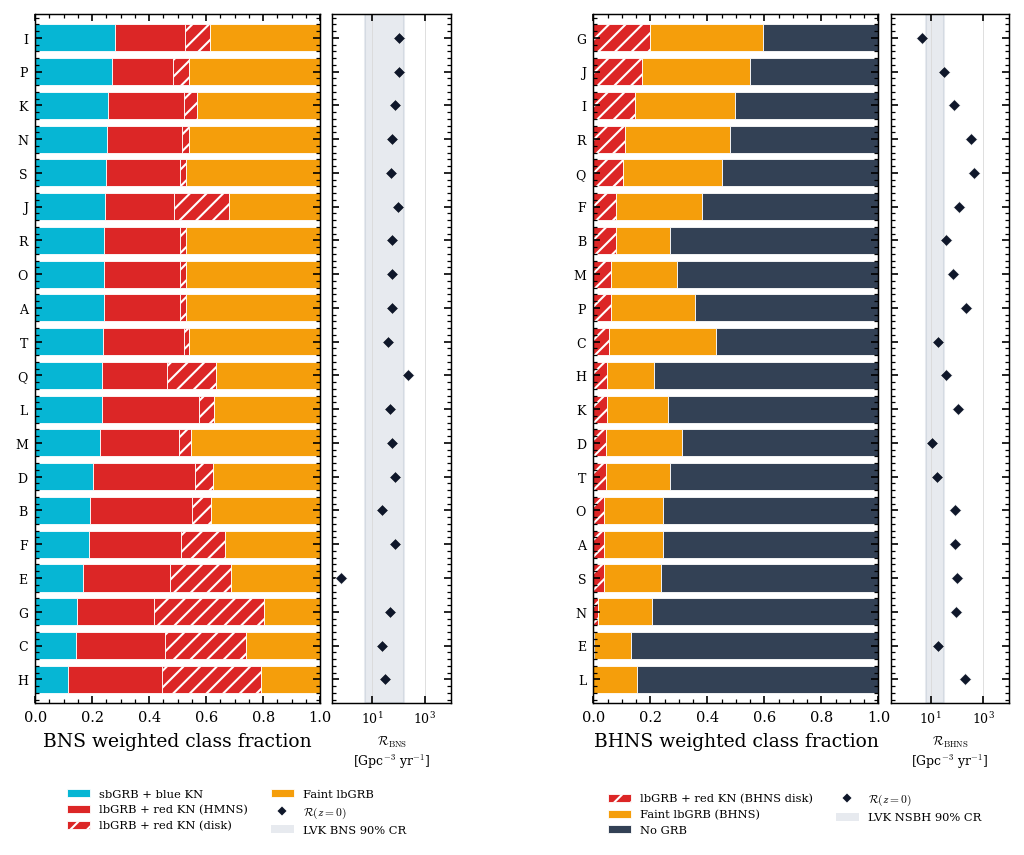

In [26]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

_d = np.load(RESULTS_PATH, allow_pickle=False)
_suffixes = np.array([str(s) for s in _d['suffixes']])
_bns_keys = [str(k) for k in _d['bns_class_keys']]
_bhns_keys = [str(k) for k in _d['bhns_class_keys']]

# Palette: same red for the two lbGRB + red KN channels (project convention);
# a hatch on the disk channel keeps them separable in the stack.
_bns_colours = {'sbGRB + blue KN': C_SB_BLUE,
                'lbGRB + red KN (HMNS)': C_LB_HMNS,
                'lbGRB + red KN (disk)': C_LB_DISK,
                'Faint lbGRB': C_FAINT}
_bhns_colours = {'lbGRB + red KN (BHNS disk)': C_LB_DISK,
                 'Faint lbGRB (BHNS)': C_FAINT,
                 'No GRB': C_NO_GRB}
_hatch = {'lbGRB + red KN (disk)': '///', 'lbGRB + red KN (BHNS disk)': '///'}

# LVK GWTC-5.0 90 percent CRs on the intrinsic z=0 rate (LVK 2026).
LVK_BNS_90CR = (LVK_GWTC5_LOCAL_RATES['BNS']['R_lo'],
                LVK_GWTC5_LOCAL_RATES['BNS']['R_hi'])
LVK_NSBH_90CR = (LVK_GWTC5_LOCAL_RATES['NSBH']['R_lo'],
                 LVK_GWTC5_LOCAL_RATES['NSBH']['R_hi'])

_RATE_MARKER = '#0F172A'  # dark diamond, one per model (Broekgaarden+ 2026 style)


def _grid_panel(subfig, frac, R, keys, colours, band, band_lbl,
                pop, rate_lbl):
    """One Broekgaarden+ 2026 Fig. 4/5 style row block: stacked class
    fractions (wide, left) sharing the model y-axis with the local merger
    rate (narrow, right, log axis with a shaded LVK band).  Models are sorted
    into a smooth wedge by the leading class fraction, largest on top.
    Models are labelled by their Broekgaarden+ 2022 paper-II letter, the
    convention used on the Zenodo data release."""
    order = np.argsort(frac[:, 0])  # ascending leading-class fraction
    labels = [BROEKGAARDEN22_PAPER_II_LETTERS.get(s, s)
              for s in _suffixes[order]]
    frac, R = frac[order], R[order]
    n = len(labels)
    y = np.arange(n)

    ax_f, ax_r = subfig.subplots(
        1, 2, sharey=True, gridspec_kw={'width_ratios': [3.0, 1.25],
                                        'wspace': 0.06})

    left = np.zeros(n)
    bar_handles = []
    for j, k in enumerate(keys):
        h = ax_f.barh(y, frac[:, j], left=left, color=colours[k], label=k,
                      edgecolor='white', linewidth=0.4, hatch=_hatch.get(k))
        bar_handles.append(h)
        left = left + frac[:, j]
    ax_f.set_xlim(0, 1)
    ax_f.set_ylim(-0.7, n - 0.3)
    ax_f.set_yticks(y)
    ax_f.set_yticklabels(labels, fontsize=6)
    ax_f.set_xlabel(f'{pop} weighted class fraction')

    ax_r.axvspan(band[0], band[1], color='#94A3B8', alpha=0.22, zorder=0)
    ax_r.scatter(R, y, marker='D', s=16, color=_RATE_MARKER,
                 edgecolor='white', linewidth=0.3, zorder=3)
    ax_r.set_xscale('log')
    ax_r.set_xlim(0.3, 1e4)
    # Two-line label keeps the units inside the narrow column width.
    ax_r.set_xlabel(rate_lbl, fontsize=6)
    ax_r.tick_params(axis='x', labelsize=6)
    ax_r.grid(axis='x', which='major', color='0.85', linewidth=0.4, zorder=0)
    ax_r.tick_params(axis='y', labelleft=False)

    # One legend strip per population, anchored to the subfigure bottom
    # below both x-axis labels.  A per-axis legend put the class swatches
    # level with the rate-panel units, which then overlapped.
    rate_handles = [
        Line2D([], [], marker='D', linestyle='none', color=_RATE_MARKER,
               markeredgecolor='white', markersize=4,
               label=r'$\mathcal{R}(z{=}0)$'),
        Patch(facecolor='#94A3B8', alpha=0.22, label=band_lbl)]
    subfig.legend(handles=list(bar_handles) + rate_handles,
                  loc='lower center', bbox_to_anchor=(0.5, 0.0),
                  ncol=2, fontsize=5.5, frameon=False)


fig = plt.figure(figsize=(7.3, 5.6))
_sf_bns, _sf_bhns = fig.subfigures(1, 2, wspace=0.04)
for _sf in (_sf_bns, _sf_bhns):
    _sf.subplots_adjust(bottom=0.17, top=0.99)
_grid_panel(_sf_bns, _d['frac_bns'], _d['R0_bns'],
            _bns_keys, _bns_colours, LVK_BNS_90CR, 'LVK BNS 90% CR',
            'BNS',
            '$\\mathcal{R}_{\\rm BNS}$\n[Gpc$^{-3}$ yr$^{-1}$]')
_grid_panel(_sf_bhns, _d['frac_bhns'], _d['R0_bhns'],
            _bhns_keys, _bhns_colours, LVK_NSBH_90CR, 'LVK NSBH 90% CR',
            'BHNS',
            '$\\mathcal{R}_{\\rm BHNS}$\n[Gpc$^{-3}$ yr$^{-1}$]')
fig.savefig('plots/class_fractions_20models.pdf')
fig.savefig('plots/class_fractions_20models.png', dpi=300)
plt.show()

### 11.2 The full $\alpha_\mathrm{CE}$ sequence

Common-envelope efficiency over two decades: $\alpha_\mathrm{CE} \in \{0.1, 0.5, 1.0, 2.0, 10\}$ (paper-II models G, H, A, I, J; paper-I alpha0p1, F, A, G, alpha10). Left: stacked BNS class fractions; right: BNS and BHNS local intrinsic rate vs $\alpha_\mathrm{CE}$ on log axes. More efficient envelope ejection widens post-CE separations and raises the merger rate (Broekgaarden et al. 2021 Sec. 5.2); the five-point sequence shows whether the trend saturates at the extremes. The rate markers carry the same $\sim \pm 30$ percent MSSFR-resolution systematic as Fig. 11.1, which does not change the non-monotonic shape. Source as in 11.1.

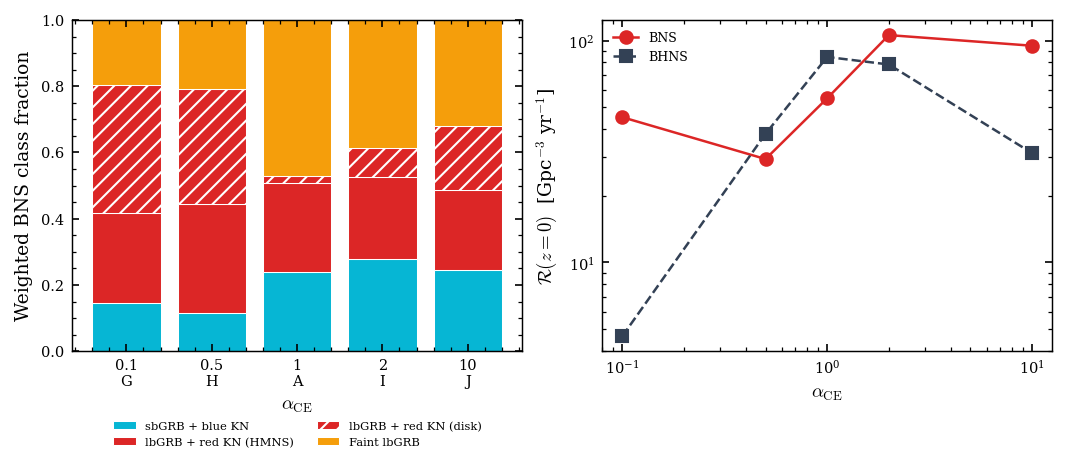

In [27]:
_d = np.load(RESULTS_PATH, allow_pickle=False)
_suffixes = [str(s) for s in _d['suffixes']]
_idx = {s: i for i, s in enumerate(_suffixes)}
_bns_keys = [str(k) for k in _d['bns_class_keys']]

ALPHA_SEQ = ['alpha0p1', 'F', 'A', 'G', 'alpha10']
_alpha = np.array([BROEKGAARDEN21_MODELS[s]['alpha_ce'] for s in ALPHA_SEQ])
_rows = [_idx[s] for s in ALPHA_SEQ]
_frac = _d['frac_bns'][_rows]
_r0_bns = _d['R0_bns'][_rows]
_r0_bhns = _d['R0_bhns'][_rows]

_bns_colours = {'sbGRB + blue KN': C_SB_BLUE,
                'lbGRB + red KN (HMNS)': C_LB_HMNS,
                'lbGRB + red KN (disk)': C_LB_DISK,
                'Faint lbGRB': C_FAINT}
_hatch = {'lbGRB + red KN (disk)': '///'}

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)
x = np.arange(len(ALPHA_SEQ))
bottom = np.zeros(len(ALPHA_SEQ))
for j, k in enumerate(_bns_keys):
    axes[0].bar(x, _frac[:, j], bottom=bottom, color=_bns_colours[k],
                label=k, edgecolor='white', linewidth=0.5,
                hatch=_hatch.get(k))
    top = bottom + _frac[:, j]
    bottom = top
axes[0].set_xticks(x)
# Tick label carries the alpha_CE value and the paper-II model letter.
axes[0].set_xticklabels([f'{a:g}\n{_p2(s)}' for a, s in zip(_alpha, ALPHA_SEQ)])
axes[0].set_xlabel(r'$\alpha_\mathrm{CE}$')
axes[0].set_ylabel('Weighted BNS class fraction')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
               fontsize=5.5, frameon=False)

axes[1].plot(_alpha, _r0_bns, 'o-', color=C_LB_HMNS, lw=1.2, label='BNS')
axes[1].plot(_alpha, _r0_bhns, 's--', color=C_NO_GRB, lw=1.2, label='BHNS')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\alpha_\mathrm{CE}$')
axes[1].set_ylabel(r'$\mathcal{R}(z=0)$  [Gpc$^{-3}$ yr$^{-1}$]')
axes[1].legend(fontsize=6, frameon=False)
fig.savefig('plots/class_fractions_alpha_ce_5pt.pdf')
fig.savefig('plots/class_fractions_alpha_ce_5pt.png', dpi=300)
plt.show()

### 11.3 Mass-transfer efficiency sweep

Stacked BNS class fractions for the fiducial adaptive mass-transfer efficiency (Model A) and the three fixed values $\beta \in \{0.25, 0.5, 0.75\}$ (Models B, C, D; the paper-I and paper-II letters coincide through E; Broekgaarden et al. 2021 Sec. 5.1). The mass-transfer efficiency reshapes the component-mass and mass-ratio distribution, to which the $q > 1.2$ prompt-collapse boundary (Gottlieb 2023) is directly sensitive: the lbGRB + red KN (disk) channel grows from a few percent in the fiducial run to roughly a quarter of the population at $\beta = 0.5$. Source as in 11.1.

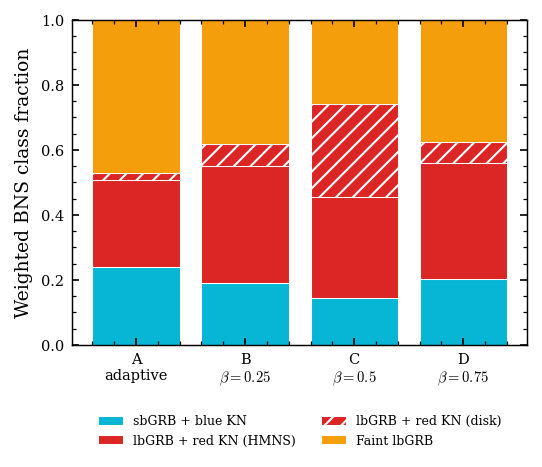

In [28]:
_d = np.load(RESULTS_PATH, allow_pickle=False)
_suffixes = [str(s) for s in _d['suffixes']]
_idx = {s: i for i, s in enumerate(_suffixes)}
_bns_keys = [str(k) for k in _d['bns_class_keys']]

BETA_SEQ = ['A', 'B', 'C', 'D']
_beta_labels = ['A\nadaptive', r'B' + '\n' + r'$\beta=0.25$',
                r'C' + '\n' + r'$\beta=0.5$', r'D' + '\n' + r'$\beta=0.75$']
_rows = [_idx[s] for s in BETA_SEQ]
_frac = _d['frac_bns'][_rows]

_bns_colours = {'sbGRB + blue KN': C_SB_BLUE,
                'lbGRB + red KN (HMNS)': C_LB_HMNS,
                'lbGRB + red KN (disk)': C_LB_DISK,
                'Faint lbGRB': C_FAINT}
_hatch = {'lbGRB + red KN (disk)': '///'}

fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
x = np.arange(len(BETA_SEQ))
bottom = np.zeros(len(BETA_SEQ))
for j, k in enumerate(_bns_keys):
    ax.bar(x, _frac[:, j], bottom=bottom, color=_bns_colours[k], label=k,
           edgecolor='white', linewidth=0.5, hatch=_hatch.get(k))
    top = bottom + _frac[:, j]
    bottom = top
ax.set_xticks(x)
ax.set_xticklabels(_beta_labels, fontsize=7)
ax.set_ylabel('Weighted BNS class fraction')
ax.set_ylim(0, 1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          fontsize=6, frameon=False)
fig.savefig('plots/class_fractions_beta_sweep.pdf')
fig.savefig('plots/class_fractions_beta_sweep.png', dpi=300)
plt.show()

### 11.4 Supernova remnant engine: delayed vs rapid

Fiducial delayed engine (Model A) against the rapid Fryer et al. (2012) remnant prescription (Model L; paper-I I). Left: BNS class fractions side by side. Centre: weighted BNS total-mass distribution. Right: weighted BHNS BH-mass distribution. The rapid engine enforces the 2 to 5 $M_\odot$ lower mass gap, shifting $M_\mathrm{tot}$ relative to the prompt-collapse threshold and removing the low-mass BHs that disrupt the NS, so the BHNS No GRB fraction grows.

Caveat: the Alsing, Silva and Berti (2018) NS-mass remap was motivated by the delayed-engine deficit, but Broekgaarden et al. (2021, footnote 3) note both engines share the $\sim 1.7\,M_\odot$ deficit from the Fryer (2012) baryonic-to-gravitational conversion, so the same remap applies to the rapid run. The centre and right panels are STROOPWAFEL-weighted distributions normalised to unit area. Source as in 11.1.

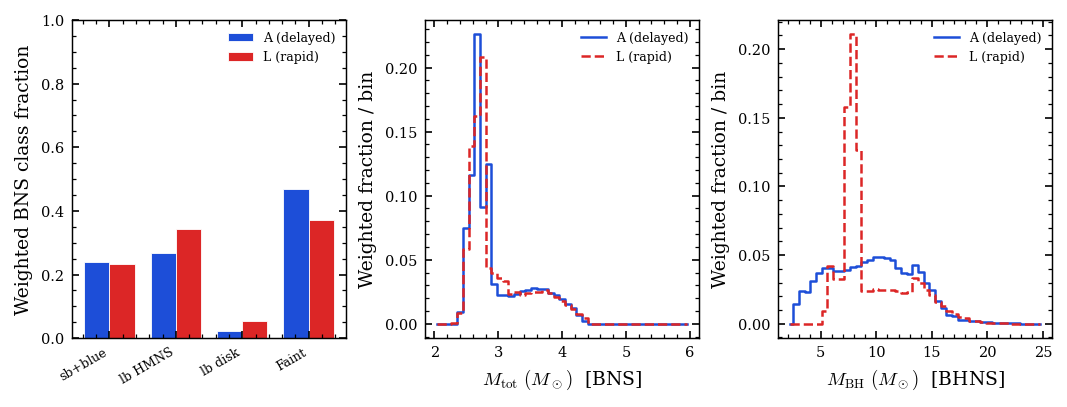

In [29]:
_d = np.load(RESULTS_PATH, allow_pickle=False)
_suffixes = [str(s) for s in _d['suffixes']]
_idx = {s: i for i, s in enumerate(_suffixes)}
_bns_keys = [str(k) for k in _d['bns_class_keys']]

_mbh_bins = _d['mbh_bins']
_mtot_bins = _d['mtot_bins']
_mbh_c = 0.5 * (_mbh_bins[:-1] + _mbh_bins[1:])
_mtot_c = 0.5 * (_mtot_bins[:-1] + _mtot_bins[1:])

from grb_plot_style import C_MODEL_A, C_MODEL_K

# Delayed (paper-I A) and rapid (paper-I I) engines reuse the project Model A /
# Model K hues.  Dict keys are the paper-I data suffixes; legend labels use the
# paper-II letters (via _p2) shown throughout the notebook, so the rapid model
# reads as L.
ENGINE = {'A': (f'{_p2("A")} (delayed)', C_MODEL_A, '-'),
          'I': (f'{_p2("I")} (rapid)', C_MODEL_K, '--')}

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.6), constrained_layout=True)

# Panel 0: BNS class fractions, A vs I side by side.
x = np.arange(len(_bns_keys))
width = 0.38
for off, s in zip((-width / 2, width / 2), ('A', 'I')):
    axes[0].bar(x + off, _d['frac_bns'][_idx[s]], width,
                color=ENGINE[s][1], label=ENGINE[s][0],
                edgecolor='white', linewidth=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['sb+blue', 'lb HMNS', 'lb disk', 'Faint'],
                        fontsize=6, rotation=30, ha='right')
axes[0].set_ylabel('Weighted BNS class fraction')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=6, frameon=False)

# Panel 1: BNS total mass.
for s in ('A', 'I'):
    axes[1].step(_mtot_c, _d['mtot_hist'][_idx[s]], where='mid',
                 color=ENGINE[s][1], ls=ENGINE[s][2], lw=1.2,
                 label=ENGINE[s][0])
axes[1].set_xlabel(r'$M_\mathrm{tot}\ (M_\odot)$  [BNS]')
axes[1].set_ylabel('Weighted fraction / bin')
axes[1].legend(fontsize=6, frameon=False)

# Panel 2: BHNS BH mass.
for s in ('A', 'I'):
    axes[2].step(_mbh_c, _d['mbh_hist'][_idx[s]], where='mid',
                 color=ENGINE[s][1], ls=ENGINE[s][2], lw=1.2,
                 label=ENGINE[s][0])
axes[2].set_xlabel(r'$M_\mathrm{BH}\ (M_\odot)$  [BHNS]')
axes[2].set_ylabel('Weighted fraction / bin')
axes[2].legend(fontsize=6, frameon=False)

fig.savefig('plots/class_fractions_sn_engine.pdf')
fig.savefig('plots/class_fractions_sn_engine.png', dpi=300)
plt.show()

### 11.5 Channel x class contingency: case BB and CE survival

Weighted $P(\mathrm{class}\,|\,\mathrm{channel})$ for the fiducial Model A and three variations that reshape the channel mix: E (unstable case BB), F (unstable case BB plus optimistic CE; paper-I EH), and K (optimistic common-envelope survival; paper-I H). Each row is a Broekgaarden et al. (2021) formation channel (I to V), each column a Gottlieb (2024) BNS class; rows sum to one. Case BB instability suppresses the dominant stable-MT-plus-CE channel; the question is which GRB classes survive that suppression and whether optimistic CE survival restores them through a different channel mix. The weighted-Poisson error on a cell is sub-percent wherever the channel is populated (Kish $n_\mathrm{eff} \gg 100$), so no per-cell error is annotated. Source as in 11.1.

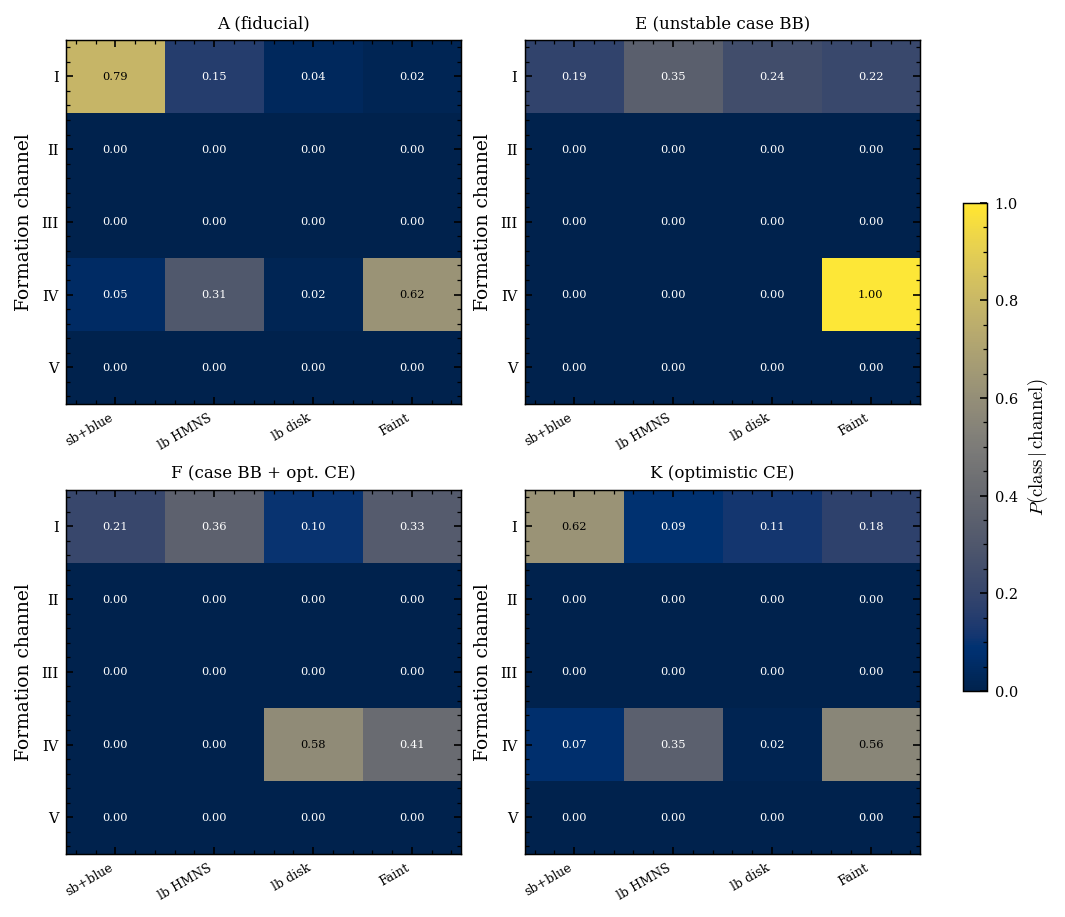

In [30]:
_d = np.load(RESULTS_PATH, allow_pickle=False)
_suffixes = [str(s) for s in _d['suffixes']]
_idx = {s: i for i, s in enumerate(_suffixes)}
_ch_keys = [str(k) for k in _d['ch_keys']]
_bns_keys = [str(k) for k in _d['bns_class_keys']]

CROSS_MODELS = ['A', 'E', 'EH', 'H']  # paper-I data keys
# Panel titles use the paper-II letters (via _p2): A, E, EH->F, H->K.
_titles = {'A': f'{_p2("A")} (fiducial)',
           'E': f'{_p2("E")} (unstable case BB)',
           'EH': f'{_p2("EH")} (case BB + opt. CE)',
           'H': f'{_p2("H")} (optimistic CE)'}
_row_labels = [k.split(None, 1)[0] for k in _ch_keys]  # I, II, III, IV, V
_col_labels = ['sb+blue', 'lb HMNS', 'lb disk', 'Faint']

fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.0), constrained_layout=True)
_im = None
for ax, s in zip(axes.ravel(), CROSS_MODELS):
    mat = _d['crosstab_bns'][_idx[s]]
    _im = ax.imshow(mat, cmap='cividis', vmin=0, vmax=1, aspect='auto')
    ax.set_title(_titles[s], fontsize=8)
    ax.set_xticks(np.arange(len(_col_labels)))
    ax.set_xticklabels(_col_labels, fontsize=6, rotation=30, ha='right')
    ax.set_yticks(np.arange(len(_row_labels)))
    ax.set_yticklabels(_row_labels, fontsize=7)
    ax.set_ylabel('Formation channel')
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, f'{mat[r, c]:.2f}', ha='center', va='center',
                    fontsize=5.5,
                    color='white' if mat[r, c] < 0.5 else 'black')
fig.colorbar(_im, ax=axes, shrink=0.6,
             label=r'$P(\mathrm{class}\,|\,\mathrm{channel})$')
fig.savefig('plots/channel_class_casebb_ce.pdf')
fig.savefig('plots/channel_class_casebb_ce.png', dpi=300)
plt.show()

### 11.6 Dense-matter equation of state: the EOS x model class matrix

For each of the 20 models and the four reference EOS (APR4, SFHo, LS220, DD2; soft to stiff by $R_{1.4}$), the weighted lbGRB + red KN (HMNS) class fraction, recomputed in the Section 11.0b scan from the same remapped masses. Each EOS sets its own $M_\mathrm{TOV}$, and hence its own HMNS split $1.2\,M_\mathrm{TOV}$ and prompt-collapse line. _Left:_ the main-text treatment, the Gottlieb (2023) $k = 1.27$ held fixed across all EOS so only $M_\mathrm{TOV}$ moves (the linked $M_\mathrm{thresh} = k\,M_\mathrm{TOV}$). _Right:_ the rigor check, the EOS-consistent $k = M_\mathrm{crit}/M_\mathrm{TOV}$ implied by the Bauswein (2013) prompt-collapse masses ($\approx 1.31, 1.26, 1.33, 1.38$ for APR4 / SFHo / LS220 / DD2). The sbGRB boundary is $1.2\,M_\mathrm{TOV}$ and is independent of $k$, so the two panels differ only in how the non-sbGRB systems split between the HMNS and the disk/faint classes; the stiff-EOS (DD2) reversal of the sbGRB-minority ordering is therefore $k$-independent. The printout below tabulates the sbGRB and HMNS fractions of the five core models under both $k$ treatments and flags where sbGRB becomes the largest class. Colormap cividis (Crameri et al. 2020). Source: the Section 11.0b cache `plots/grid_scan_results.npz`.

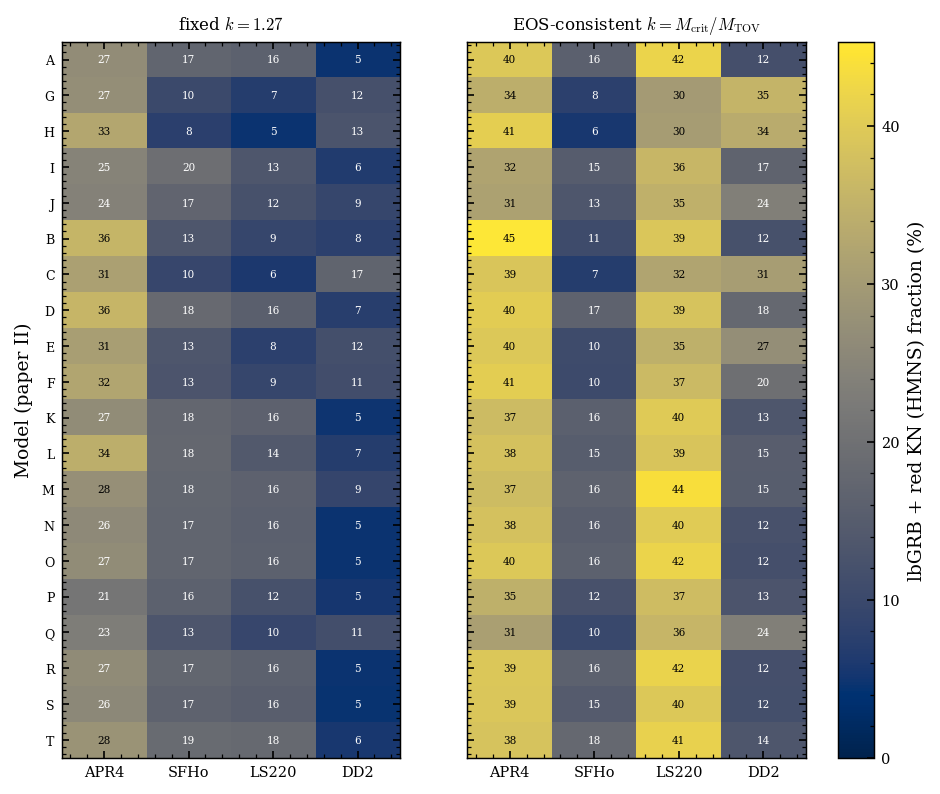

model  EOS    sbGRB_fix  sbGRB_kc  HMNS_fix   HMNS_kc  sb_largest
A      APR4       24.0%     24.0%     26.8%     39.6%       False
A      SFHo        1.9%      1.9%     17.2%     16.1%       False
A      LS220       1.0%      1.0%     16.2%     41.9%       False
A      DD2        65.0%     65.0%      4.7%     11.8%        True
H      APR4       11.7%     11.7%     32.7%     40.9%       False
H      SFHo        0.2%      0.2%      7.7%      5.6%       False
H      LS220       0.1%      0.1%      4.7%     30.4%       False
H      DD2        54.5%     54.5%     12.8%     33.7%        True
I      APR4       27.9%     27.9%     24.7%     32.0%       False
I      SFHo        3.5%      3.5%     19.6%     15.0%       False
I      LS220       2.2%      2.2%     13.5%     36.1%       False
I      DD2        61.2%     61.2%      6.4%     16.7%        True
M      APR4       22.9%     22.9%     27.6%     37.2%       False
M      SFHo        1.9%      1.9%     17.5%     16.5%       False
M      LS2

In [31]:
# Section 11.6: EOS x model HMNS-fraction matrix, fixed k vs EOS-consistent k.
# Reads the Section 11.0b cache; rows family-major (matching the other grid
# figures), columns soft-to-stiff EOS.
_res = np.load(RESULTS_PATH, allow_pickle=False)
_suf = [str(s) for s in _res['suffixes']]
_eos_names = [str(e) for e in _res['eos_names']]
_bk = [str(k) for k in _res['bns_class_keys']]
_i_hmns = _bk.index('lbGRB + red KN (HMNS)')
_i_sb = _bk.index('sbGRB + blue KN')

# Family-major row order (same key as grb_plot_style.model_grid_colors).
_fam_rank = {f: i for i, f in enumerate(MODEL_GRID_FAMILY_ORDER)}
_reg = list(BROEKGAARDEN21_MODELS)
_row_order = sorted(range(len(_suf)),
                    key=lambda j: (_fam_rank[BROEKGAARDEN21_MODELS[_suf[j]]['family']],
                                   _reg.index(_suf[j])))
_row_labels = [BROEKGAARDEN22_PAPER_II_LETTERS[_suf[j]] for j in _row_order]

_hmns_fix = _res['eos_frac_bns'][:, :, _i_hmns][_row_order] * 100.0
_hmns_con = _res['eos_frac_bns_kcons'][:, :, _i_hmns][_row_order] * 100.0
_vmax = float(max(_hmns_fix.max(), _hmns_con.max()))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 6.2), sharey=True)
for _ax, _M, _ttl in (
        (axes[0], _hmns_fix, r'fixed $k = 1.27$'),
        (axes[1], _hmns_con, r'EOS-consistent $k = M_{\rm crit}/M_{\rm TOV}$')):
    _im = _ax.imshow(_M, aspect='auto', cmap='cividis', vmin=0.0, vmax=_vmax)
    _ax.set_xticks(range(len(_eos_names)))
    _ax.set_xticklabels(_eos_names)
    _ax.set_title(_ttl, fontsize=8)
    for _r in range(_M.shape[0]):
        for _c in range(_M.shape[1]):
            _ax.text(_c, _r, f'{_M[_r, _c]:.0f}', ha='center', va='center',
                     fontsize=5,
                     color='white' if _M[_r, _c] < 0.6 * _vmax else 'black')
axes[0].set_yticks(range(len(_row_labels)))
axes[0].set_yticklabels(_row_labels, fontsize=6)
axes[0].set_ylabel('Model (paper II)')
fig.colorbar(_im, ax=axes, fraction=0.046, pad=0.04,
             label='lbGRB + red KN (HMNS) fraction (%)')
fig.savefig('plots/eos_x_model_matrix_20models.pdf')
fig.savefig('plots/eos_x_model_matrix_20models.png', dpi=300)
plt.show()

# Core five (paper-I A, F, G, J, K): sbGRB and HMNS fractions per EOS under
# both k treatments, and whether sbGRB is the largest class (ordering test).
_core = ['A', 'F', 'G', 'J', 'K']
print(f"{'model':6s} {'EOS':6s} {'sbGRB_fix':>9s} {'sbGRB_kc':>9s} "
      f"{'HMNS_fix':>9s} {'HMNS_kc':>9s} {'sb_largest':>11s}")
for _m in _core:
    _j = _suf.index(_m)
    for _e, _eos in enumerate(_eos_names):
        _ff = _res['eos_frac_bns'][_j, _e]
        _fc = _res['eos_frac_bns_kcons'][_j, _e]
        _largest = bool(np.isclose(_ff[_i_sb], _ff.max()))
        print(f"{BROEKGAARDEN22_PAPER_II_LETTERS[_m]:6s} {_eos:6s} "
              f"{_ff[_i_sb] * 100:8.1f}% {_fc[_i_sb] * 100:8.1f}% "
              f"{_ff[_i_hmns] * 100:8.1f}% {_fc[_i_hmns] * 100:8.1f}% "
              f"{str(_largest):>11s}")
_res.close()

### 11.7 Sensitivity of the class ordering to the HMNS split factor

The long-lived / short-lived HMNS split sits at $M_\mathrm{HMNS} = f_\mathrm{HMNS}\,M_\mathrm{TOV}$, a code heuristic (fiducial $f_\mathrm{HMNS} = 1.2$; Margalit and Metzger 2017), and it alone sets the sbGRB / HMNS boundary. Sweeping it over $[1.10, 1.27]$ on the Model A remapped masses moves systems between the sbGRB class and the HMNS class; the four-class scheme stays coherent only up to $f_\mathrm{HMNS} = k = 1.27$, above which the split crosses the prompt-collapse line $M_\mathrm{thresh}$ and the HMNS class empties. The table reports the weighted sbGRB fraction, the lbGRB-producing majority ($1 -$ sbGRB), and the HMNS fraction at each factor, so the question is whether the long-duration majority survives the heuristic across its plausible range.

In [32]:
# Section 11.7: HMNS split-factor sweep on Model A (Section 0 remapped masses).
# hmns_factor sets the sbGRB / HMNS boundary at hmns_factor * M_TOV; fiducial
# 1.2.  Coherent only for hmns_factor <= k = 1.27 (above that hmns_split
# exceeds M_thresh and the HMNS class empties), so the sweep stops at 1.27.
_w_a = bns_ch['weights']
_hf_grid = (1.10, 1.15, 1.20, 1.25, 1.27)
_sb_sweep = []
print(f"{'f_HMNS':>7s} {'sbGRB %':>9s} {'lbGRB-maj %':>12s} {'HMNS %':>9s}")
for _hf in _hf_grid:
    _c = classify_bns_2024(bns_ch['m1'], bns_ch['m2'], hmns_factor=_hf)
    _fsb = _w_a[_c['sbGRB + blue KN']].sum() / _w_a.sum()
    _fh = _w_a[_c['lbGRB + red KN (HMNS)']].sum() / _w_a.sum()
    _sb_sweep.append(_fsb)
    print(f"{_hf:7.2f} {_fsb * 100:8.1f}% {(1.0 - _fsb) * 100:11.1f}% "
          f"{_fh * 100:8.1f}%")
_sb_max = max(_sb_sweep)
print(f"\\nMax sbGRB fraction over f_HMNS in [1.10, 1.27]: {_sb_max * 100:.1f}% "
      f"({'stays a minority' if _sb_max < 0.5 else 'becomes the majority'}); "
      f"the lbGRB-producing classes keep at least {(1.0 - _sb_max) * 100:.1f}% "
      "of the population across the heuristic's coherent range.")

 f_HMNS   sbGRB %  lbGRB-maj %    HMNS %
   1.10      0.4%        99.6%     50.4%
   1.15      7.9%        92.1%     42.9%
   1.20     24.0%        76.0%     26.8%
   1.25     45.2%        54.8%      5.6%
   1.27     50.8%        49.2%      0.0%
\nMax sbGRB fraction over f_HMNS in [1.10, 1.27]: 50.8% (becomes the majority); the lbGRB-producing classes keep at least 49.2% of the population across the heuristic's coherent range.


## 12. GRB Engine Classification Scheme

Decision-tree rendering of the Table 3 criteria: the Gottlieb et al. (2023, 2025) hybrid BNS classes on $(M_{\rm tot}, q)$ and the BHNS disk-mass classes, with the class palette carried by the boxes. Thresholds import from `grb_physics`, so an EOS or threshold change propagates here automatically.

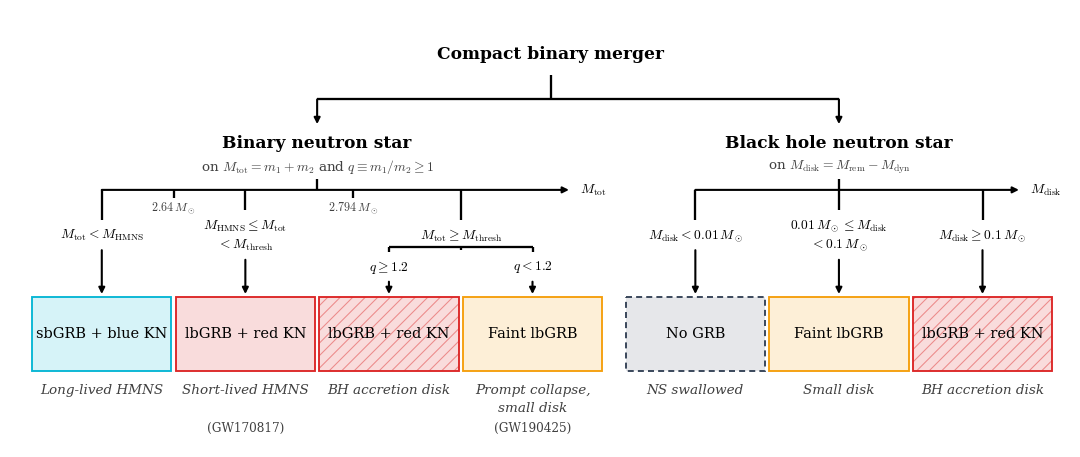

fig15: classification scheme saved; M_HMNS = 2.64 Msun, M_thresh = 2.794 Msun, q_thresh = 1.2, BHNS disk cuts 0.01/0.1 Msun; anchors: GW170817 -> class 2, GW190425 -> class 1


In [33]:
# Table 3 (GRB engine classification criteria) as a decision tree.
# Pure schematic, no COMPAS data enters. Thresholds are imported from
# grb_physics so an EOS or threshold change propagates here automatically.
# The BNS branch reads as bins along M_tot, with the prompt-collapse bin
# forking on q; each bus doubles as the branch's ordering axis with the
# boundary masses marked as ticks. Hatching separates the two lbGRB +
# red KN classes, which share one palette hex. GW170817 and GW190425 are
# placed by classify_grid on their published median masses, so the anchors
# move if the thresholds do.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle

from grb_classify import classify_grid
from grb_io import OBSERVED_GW_EVENTS
from grb_physics import (
    HMNS_FACTOR_DEFAULT,
    M_THRESH,
    M_TOV,
    MDISK_LONG,
    MDISK_SHORT,
    Q_THRESH_BNS,
)
from grb_plot_style import (
    C_FAINT,
    C_LB_DISK,
    C_LB_HMNS,
    C_NO_GRB,
    C_SB_BLUE,
    apply_apj_rcparams,
)

apply_apj_rcparams({"hatch.linewidth": 0.5})

# Model A fiducial M_NS,max (Broekgaarden+ 2021); both events sit far below
# any of the grid caps, so the choice does not move them.
EVENT_NS_MAX = 2.5
event_label = {
    name: int(classify_grid(np.array([ev["M1"]]), np.array([ev["M2"]]),
                            ns_max=EVENT_NS_MAX)[0])
    for name, ev in OBSERVED_GW_EVENTS.items()
}

# Abstract layout units; y axis inverted so y grows downward like the sketch.
W, H = 980.0, 312.0
BOX_W, BOX_H, BOX_TOP = 130.0, 54.0, 206.0
BUS_Y = 128.0
SUBBUS_Y = 170.0
ENGINE_Y = (274.0, 287.0)
EVENT_Y = 302.0
BNS_MID, BHNS_MID = 282.0, 769.0

GRAY = "0.25"
FS_HEAD, FS_CLASS, FS_BODY, FS_TICK = 8.2, 7.0, 6.5, 5.8
LINE_KW = dict(color="black", lw=1.1, solid_capstyle="butt")
ARROW_KW = dict(arrowstyle="-|>", color="black", lw=1.0, mutation_scale=6,
                shrinkA=0, shrinkB=0)


def class_box(ax, x, color, name, engines, label=None, hatch=False,
              dashed=False):
    """One class box with its central engine (and any GW anchors) below."""
    x0 = x - BOX_W / 2
    ax.add_patch(Rectangle((x0, BOX_TOP), BOX_W, BOX_H,
                           facecolor=to_rgba(color, 0.12 if dashed else 0.16),
                           edgecolor=color, lw=0.9,
                           linestyle=(0, (3.2, 2.2)) if dashed else "-",
                           zorder=2))
    if hatch:
        ax.add_patch(Rectangle((x0, BOX_TOP), BOX_W, BOX_H,
                               facecolor="none", lw=0, hatch="////",
                               edgecolor=to_rgba(color, 0.45), zorder=2.1))
    ax.text(x, BOX_TOP + BOX_H / 2, name, ha="center", va="center",
            fontsize=FS_CLASS, zorder=3)
    for y, s in zip(ENGINE_Y, engines):
        ax.text(x, y, s, ha="center", va="center", fontsize=FS_BODY,
                fontstyle="italic", color=GRAY)
    for name_ev, lab in event_label.items():
        if lab == label:
            ax.text(x, EVENT_Y, f"({name_ev})", ha="center", va="center",
                    fontsize=FS_TICK, color=GRAY)


def cond_drop(ax, x, lines, y_top, y_bot, head=True):
    """Vertical connector with its condition text set into the line gap."""
    ys = [161.0] if len(lines) == 1 else [154.0, 168.0]
    if y_top != BUS_Y:  # sub-bus drops sit lower
        ys = [184.0]
    for y, s in zip(ys, lines):
        ax.text(x, y, s, ha="center", va="center", fontsize=FS_BODY)
    ax.plot([x, x], [y_top, min(ys) - 11.0], **LINE_KW)
    if head:
        ax.annotate("", xy=(x, y_bot - 2.0), xytext=(x, max(ys) + 11.0),
                    arrowprops=ARROW_KW)
    else:
        ax.plot([x, x], [max(ys) + 11.0, y_bot], **LINE_KW)


fig = plt.figure(figsize=(7.0, 2.85))
ax = fig.add_axes((0.0, 0.0, 1.0, 1.0))
ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.axis("off")

# root and the two branch elbows
ax.text(500.0, 29.0, "Compact binary merger", ha="center", va="center",
        fontsize=FS_HEAD, fontweight="bold")
ax.plot([500.0, 500.0], [44.0, 62.0], **LINE_KW)
ax.plot([BNS_MID, BHNS_MID], [62.0, 62.0], **LINE_KW)
for x_branch in (BNS_MID, BHNS_MID):
    ax.annotate("", xy=(x_branch, 80.0), xytext=(x_branch, 62.0),
                arrowprops=ARROW_KW)

# branch headers and the split variables
ax.text(BNS_MID, 94.0, "Binary neutron star", ha="center", va="center",
        fontsize=FS_HEAD, fontweight="bold")
ax.text(BNS_MID, 111.0, r"on $M_{\rm tot} = m_1 + m_2$ and"
        r" $q \equiv m_1/m_2 \geq 1$",
        ha="center", va="center", fontsize=FS_BODY, color=GRAY)
ax.text(BHNS_MID, 94.0, "Black hole neutron star", ha="center", va="center",
        fontsize=FS_HEAD, fontweight="bold")
ax.text(BHNS_MID, 111.0, r"on $M_{\rm disk} = M_{\rm rem} - M_{\rm dyn}$",
        ha="center", va="center", fontsize=FS_BODY, color=GRAY)
ax.plot([BNS_MID, BNS_MID], [120.0, BUS_Y], **LINE_KW)
ax.plot([BHNS_MID, BHNS_MID], [120.0, BUS_Y], **LINE_KW)

# buses double as the ordering axes
ax.annotate("", xy=(517.0, BUS_Y), xytext=(81.0, BUS_Y), arrowprops=ARROW_KW)
ax.text(527.0, BUS_Y, r"$M_{\rm tot}$", ha="left", va="center",
        fontsize=FS_BODY)
ax.annotate("", xy=(937.0, BUS_Y), xytext=(635.0, BUS_Y), arrowprops=ARROW_KW)
ax.text(947.0, BUS_Y, r"$M_{\rm disk}$", ha="left", va="center",
        fontsize=FS_BODY)

# BNS boundary masses as axis ticks (the BHNS cuts already appear in their
# conditions, so that side carries no ticks)
for x_tick, value in ((148.0, HMNS_FACTOR_DEFAULT * M_TOV),
                      (315.5, M_THRESH)):
    ax.plot([x_tick, x_tick], [BUS_Y, BUS_Y + 6.0], **LINE_KW)
    ax.text(x_tick, 141.0, rf"${value:g}\,M_\odot$", ha="center",
            va="center", fontsize=FS_TICK, color=GRAY)

# BNS branch: M_tot bins, with the prompt-collapse bin forking on q
class_box(ax, 81.0, C_SB_BLUE, "sbGRB + blue KN", ["Long-lived HMNS"],
          label=3)
cond_drop(ax, 81.0, [r"$M_{\rm tot} < M_{\rm HMNS}$"], BUS_Y, BOX_TOP)
class_box(ax, 215.0, C_LB_HMNS, "lbGRB + red KN", ["Short-lived HMNS"],
          label=2)
cond_drop(ax, 215.0, [r"$M_{\rm HMNS} \leq M_{\rm tot}$",
                      r"$< M_{\rm thresh}$"], BUS_Y, BOX_TOP)
cond_drop(ax, 416.0, [r"$M_{\rm tot} \geq M_{\rm thresh}$"], BUS_Y,
          SUBBUS_Y, head=False)
ax.plot([349.0, 483.0], [SUBBUS_Y, SUBBUS_Y], **LINE_KW)
class_box(ax, 349.0, C_LB_DISK, "lbGRB + red KN", ["BH accretion disk"],
          label=4, hatch=True)
cond_drop(ax, 349.0, [rf"$q \geq {Q_THRESH_BNS:g}$"], SUBBUS_Y, BOX_TOP)
class_box(ax, 483.0, C_FAINT, "Faint lbGRB", ["Prompt collapse,",
                                              "small disk"], label=1)
cond_drop(ax, 483.0, [rf"$q < {Q_THRESH_BNS:g}$"], SUBBUS_Y, BOX_TOP)

# BHNS branch: disk-mass bins
class_box(ax, 635.0, C_NO_GRB, "No GRB", ["NS swallowed"], dashed=True)
cond_drop(ax, 635.0, [rf"$M_{{\rm disk}} < {MDISK_SHORT}\,M_\odot$"],
          BUS_Y, BOX_TOP)
class_box(ax, 769.0, C_FAINT, "Faint lbGRB", ["Small disk"])
cond_drop(ax, 769.0, [rf"${MDISK_SHORT}\,M_\odot \leq M_{{\rm disk}}$",
                      rf"$< {MDISK_LONG}\,M_\odot$"], BUS_Y, BOX_TOP)
class_box(ax, 903.0, C_LB_DISK, "lbGRB + red KN", ["BH accretion disk"],
          hatch=True)
cond_drop(ax, 903.0, [rf"$M_{{\rm disk}} \geq {MDISK_LONG}\,M_\odot$"],
          BUS_Y, BOX_TOP)

for ext in ("pdf", "png"):
    fig.savefig(f"plots/fig15_classification_scheme.{ext}", dpi=300)
plt.show()

print(
    f"fig15: classification scheme saved; M_HMNS = "
    f"{HMNS_FACTOR_DEFAULT * M_TOV:.2f} Msun, M_thresh = {M_THRESH:.3f} Msun, "
    f"q_thresh = {Q_THRESH_BNS}, BHNS disk cuts {MDISK_SHORT}/{MDISK_LONG} "
    f"Msun; anchors: "
    + ", ".join(f"{k} -> class {v}" for k, v in event_label.items())
)

**Figure 15.** GRB engine classification criteria as a decision tree. BNS mergers classify on the total gravitational mass $M_{\rm tot} = m_1 + m_2$, and prompt-collapse systems ($M_{\rm tot} \geq M_{\rm thresh}$) split further on the mass ratio $q \equiv m_1/m_2 \geq 1$ (Gottlieb et al. 2023, 2025 hybrid); BHNS mergers classify on the accretion-disk mass $M_{\rm disk} = M_{\rm rem} - M_{\rm dyn}$ (Foucart 2018; Kruger and Foucart 2020) at the Gottlieb et al. (2023) cuts. Each bus arrow is the branch's ordering variable, with the BNS boundary masses marked on the axis: $M_{\rm HMNS} = 1.2\,M_{\rm TOV} = 2.64\,M_\odot$ and $M_{\rm thresh} = 1.27\,M_{\rm TOV} = 2.794\,M_\odot$, with $M_{\rm TOV} = 2.2\,M_\odot$ (Raaijmakers et al. 2021). Box colors are the project class palette; the two lbGRB + red KN classes share one color, so hatching marks the disk-engine variant, and the central engine is listed beneath each box. The dashed outline marks the one outcome that launches no jet. GW170817 and GW190425 sit beneath the classes implied by their source-frame median component masses (Abbott et al. 2019, PRX 9, 011001; Abbott et al. 2020, ApJL 892, L3; low-spin priors), evaluated with `classify_grid`. All disk-mass classes assume 100 percent jet launching above threshold, so rates derived from them are upper bounds.